# Stage A — Greenwich Zoning Code Reader

## Phase 1 — Collection

This notebook implements the collection phase of the Stage A zoning-code reader

The collection phase will eventually convert the official Greenwich Building Zone Regulations PDF into a traceable, layout-aware, structured representation that supports:

- native text and OCR extraction
- page-level quality routing
- document hierarchy construction
- district-anchor detection
- cross-reference resolution
- townwide-rule collection
- structural table parsing
- base-district and overlay separation
- district evidence-bundle construction


**Raw-source policy:** Files inside `data/raw/greenwich/` are treated as immutable evidence. The notebook may read and hash the source PDF, but it must never overwrite, edit, annotate, or save derived content over it

## Step 1 — Notebook setup and inputs

### Objective

Load and validate the manually downloaded Greenwich Building Zone Regulations PDF; define extraction settings, output folders, initial regex patterns, page-quality weights, and routing thresholds

### Expected outputs

This section should produce:

1. A path summary confirming that the Stage A folder structure is available
2. A source-document record containing the local PDF path, page count, PDF metadata, retrieval date, and SHA-256 hash
3. A configuration summary table containing page-quality thresholds, enabled modules, and library versions
4. A rendered preview of page 1, confirming that the correct source document loaded

### Scope boundary

This section does not yet extract the document text, calculate actual quality scores, run OCR, classify headings, identify districts, parse tables, or create evidence bundles

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import fitz  # PyMuPDF
import pymupdf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber
import re
import pyarrow as pa

In [2]:
def find_stage_a_root(start_path: Path) -> Path:
    """
    Walk upward from the current working directory until the Stage A project
    root is found. The Stage A root must contain data/, notebooks/, and README.md.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        required_paths = [
            candidate / "data",
            candidate / "notebooks",
            candidate / "README.md",
        ]

        if all(path.exists() for path in required_paths):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Stage A project root. "
        "Make sure this notebook is saved inside "
        "Stage_A_Zoning_Code_Reader/notebooks/ and that the Stage A folder "
        "contains data/, notebooks/, and README.md."
    )


STAGE_A_ROOT = find_stage_a_root(Path.cwd())

DATA_DIR = STAGE_A_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "greenwich"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = STAGE_A_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
LOGS_DIR = OUTPUT_DIR / "logs"
REVIEW_DIR = OUTPUT_DIR / "review"

NOTEBOOK_DIR = STAGE_A_ROOT / "notebooks"
SRC_DIR = STAGE_A_ROOT / "src"
TESTS_DIR = STAGE_A_ROOT / "tests"

for directory in [
    RAW_DIR,
    INTERIM_DIR,
    PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    LOGS_DIR,
    REVIEW_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

path_summary_df = pd.DataFrame(
    {
        "name": [
            "stage_a_root",
            "raw_source_directory",
            "interim_directory",
            "processed_directory",
            "figures_directory",
            "tables_directory",
            "logs_directory",
            "review_directory",
        ],
        "path": [
            str(STAGE_A_ROOT),
            str(RAW_DIR),
            str(INTERIM_DIR),
            str(PROCESSED_DIR),
            str(FIGURES_DIR),
            str(TABLES_DIR),
            str(LOGS_DIR),
            str(REVIEW_DIR),
        ],
    }
)

path_summary_df

,name,path
0,stage_a_root,/Users/sierramendoza/Documents/HAP-Repository/...
1,raw_source_directory,/Users/sierramendoza/Documents/HAP-Repository/...
2,interim_directory,/Users/sierramendoza/Documents/HAP-Repository/...
3,processed_directory,/Users/sierramendoza/Documents/HAP-Repository/...
4,figures_directory,/Users/sierramendoza/Documents/HAP-Repository/...
5,tables_directory,/Users/sierramendoza/Documents/HAP-Repository/...
6,logs_directory,/Users/sierramendoza/Documents/HAP-Repository/...
7,review_directory,/Users/sierramendoza/Documents/HAP-Repository/...


### Canonical source-document configuration

The initial test uses one full-version Greenwich zoning-code PDF as the canonical source.

The source file must be located at:

```text
data/raw/greenwich/
```

The filename, document version date, retrieval date, source URL, and SHA-256 hash are recorded so every later extracted token, table cell, district bundle, and model result can be tied to one identifiable source document

The regex patterns below are intentionally preliminary configuration patterns. They are not yet validated against the actual Greenwich document and will be refined after the native extraction and heading-inspection stages

In [3]:
SOURCE_CONFIG = {
    "jurisdiction": "Greenwich, Connecticut",
    "document_name": "Town of Greenwich Building Zone Regulations",
    "pdf_filename": "greenwich_building_zone_regulations_full_2023-08.pdf",
    "source_url": "https://www.greenwichct.gov/442/Building-Zone-Regulations",
    "document_version_date": "August 2023",
    "date_retrieved": datetime.now(timezone.utc).date().isoformat(),
    "canonical_source": True,
}

PDF_PATH = RAW_DIR / SOURCE_CONFIG["pdf_filename"]

QUALITY_CONFIG = {
    "weights": {
        "text_coverage": 0.35,
        "character_quality": 0.25,
        "reading_order": 0.20,
        "table_integrity": 0.20,
    },
    "thresholds": {
        "high_quality_native_threshold": 0.85,
        "manual_review_threshold": 0.50,
    },
}

MODULE_CONFIG = {
    "native_pdf_extraction": True,
    "page_quality_scoring": True,
    "targeted_ocr": False,
    "dual_stream_reconciliation": False,
    "hierarchy_tree_construction": False,
    "district_anchor_detection": False,
    "cross_reference_resolution": False,
    "townwide_rule_library": False,
    "structural_table_parsing": False,
    "overlay_zone_separation": False,
    "conflict_resolution": False,
    "gis_polygon_join": False,
}

REGEX_PATTERNS = {
    "title": r"^(title|chapter)\s+[\wivxlcdm]+",
    "article": r"^article\s+[\wivxlcdm]+",
    "section": r"^(section|sec\.?|§)\s*\d+([.-]\d+)*",
    "subsection": r"^(\([a-z0-9]+\)|\d+\.\d+([.-]\d+)*)",
    "appendix": r"^appendix\s+[\wivxlcdm]+",
    "district_heading": (
        r"\b(RA-\d+|R-\d+|B-[A-Z0-9-]+|CGB|CGBR|"
        r"LB|GB|GBO|HO|CO|M[0-9A-Z-]*)\b"
    ),
    "citation": (
        r"(§\s*\d+([.-]\d+)*(\([a-z0-9]+\))?)|"
        r"(section\s+\d+([.-]\d+)*)|"
        r"(article\s+[IVXLCDM]+(\.[A-Z])?)"
    ),
}

assert abs(sum(QUALITY_CONFIG["weights"].values()) - 1.0) < 1e-9, (
    "Page-quality weights must sum to 1.0."
)

assert (
    QUALITY_CONFIG["thresholds"]["manual_review_threshold"]
    < QUALITY_CONFIG["thresholds"]["high_quality_native_threshold"]
), (
    "The manual-review threshold must be lower than the high-quality "
    "native-extraction threshold."
)

print(f"Expected source PDF: {PDF_PATH}")
print(f"Source PDF exists: {PDF_PATH.exists()}")

Expected source PDF: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/data/raw/greenwich/greenwich_building_zone_regulations_full_2023-08.pdf
Source PDF exists: True


In [4]:
def sha256_file(file_path: Path, chunk_size: int = 1_048_576) -> str:
    """
    Calculate the SHA-256 hash of a file in chunks, avoiding loading the full
    PDF into memory at one time.
    """
    digest = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        while chunk := file_handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


if not PDF_PATH.exists():
    available_pdfs = sorted(
        [file.name for file in RAW_DIR.glob("*.pdf")]
        + [file.name for file in RAW_DIR.glob("*.PDF")]
    )

    raise FileNotFoundError(
        f"Expected PDF was not found:\n{PDF_PATH}\n\n"
        f"PDF files currently in {RAW_DIR}:\n{available_pdfs}\n\n"
        "Download the official full-version Greenwich Building Zone Regulations PDF, "
        "place it in Stage_A_Zoning_Code_Reader/data/raw/greenwich/, and either "
        "use the expected filename or update SOURCE_CONFIG['pdf_filename']."
    )

PDF_SHA256 = sha256_file(PDF_PATH)
PDF_SIZE_MB = PDF_PATH.stat().st_size / (1024 ** 2)

print(f"Validated source file: {PDF_PATH.name}")
print(f"File size: {PDF_SIZE_MB:.2f} MB")
print(f"SHA-256: {PDF_SHA256}")

Validated source file: greenwich_building_zone_regulations_full_2023-08.pdf
File size: 4.11 MB
SHA-256: 18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b302f7a8ce1f13e963dcb


In [5]:
with fitz.open(PDF_PATH) as pdf_document:
    PDF_PAGE_COUNT = pdf_document.page_count
    PDF_METADATA = {
        key: value
        for key, value in pdf_document.metadata.items()
        if value not in (None, "")
    }

with pdfplumber.open(PDF_PATH) as plumber_document:
    PDFPLUMBER_METADATA = plumber_document.metadata or {}

pdf_metadata_rows = [
    {"field": "page_count", "value": PDF_PAGE_COUNT},
    {"field": "file_size_mb", "value": round(PDF_SIZE_MB, 3)},
    {"field": "sha256", "value": PDF_SHA256},
]

for key, value in PDF_METADATA.items():
    pdf_metadata_rows.append({"field": f"pymupdf_{key}", "value": value})

for key, value in PDFPLUMBER_METADATA.items():
    pdf_metadata_rows.append({"field": f"pdfplumber_{key}", "value": value})

pdf_metadata_df = pd.DataFrame(pdf_metadata_rows).drop_duplicates()

pdf_metadata_df

,field,value
0,page_count,313
1,file_size_mb,4.115
2,sha256,18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b30...
3,pymupdf_format,PDF 1.6
4,pymupdf_author,Patrick LaRow
5,pymupdf_subject,BUILDING ZONE REGULATIONS
6,pymupdf_creator,Adobe Acrobat Pro 2017 17.12.30205
7,pymupdf_producer,Adobe Acrobat Pro 2017 17.12.30205
8,pymupdf_creationDate,D:20230802110515-04'00'
9,pymupdf_modDate,D:20230802110515-04'00'


In [6]:
def package_version(package_name: str) -> str:
    try:
        from importlib.metadata import version
        return version(package_name)
    except Exception:
        return "not available"


library_versions = {
    "python": sys.version.split()[0],
    "operating_system": platform.platform(),
    "pandas": package_version("pandas"),
    "pymupdf": package_version("PyMuPDF"),
    "pdfplumber": package_version("pdfplumber"),
    "matplotlib": package_version("matplotlib"),
    "numpy": package_version("numpy"),
}

configuration_rows = [
    {
        "category": "source",
        "setting": "jurisdiction",
        "value": SOURCE_CONFIG["jurisdiction"],
    },
    {
        "category": "source",
        "setting": "document_name",
        "value": SOURCE_CONFIG["document_name"],
    },
    {
        "category": "source",
        "setting": "pdf_path",
        "value": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    },
    {
        "category": "source",
        "setting": "page_count",
        "value": PDF_PAGE_COUNT,
    },
    {
        "category": "source",
        "setting": "document_version_date",
        "value": SOURCE_CONFIG["document_version_date"],
    },
    {
        "category": "source",
        "setting": "date_retrieved",
        "value": SOURCE_CONFIG["date_retrieved"],
    },
    {
        "category": "source",
        "setting": "source_url",
        "value": SOURCE_CONFIG["source_url"],
    },
    {
        "category": "source",
        "setting": "sha256",
        "value": PDF_SHA256,
    },
]

for metric_name, weight in QUALITY_CONFIG["weights"].items():
    configuration_rows.append(
        {
            "category": "quality_weight",
            "setting": metric_name,
            "value": weight,
        }
    )

for threshold_name, threshold in QUALITY_CONFIG["thresholds"].items():
    configuration_rows.append(
        {
            "category": "quality_threshold",
            "setting": threshold_name,
            "value": threshold,
        }
    )

for module_name, enabled in MODULE_CONFIG.items():
    configuration_rows.append(
        {
            "category": "module",
            "setting": module_name,
            "value": enabled,
        }
    )

for library_name, version_string in library_versions.items():
    configuration_rows.append(
        {
            "category": "environment",
            "setting": library_name,
            "value": version_string,
        }
    )

config_summary_df = pd.DataFrame(configuration_rows)

config_summary_df

,category,setting,value
0,source,jurisdiction,"Greenwich, Connecticut"
1,source,document_name,Town of Greenwich Building Zone Regulations
2,source,pdf_path,data/raw/greenwich/greenwich_building_zone_reg...
3,source,page_count,313
4,source,document_version_date,August 2023
5,source,date_retrieved,2026-09-29
6,source,source_url,https://www.greenwichct.gov/442/Building-Zone-...
7,source,sha256,18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b30...
8,quality_weight,text_coverage,0.35
9,quality_weight,character_quality,0.25


In [7]:
run_timestamp_utc = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

source_metadata = {
    **SOURCE_CONFIG,
    "pdf_path_relative_to_stage_a": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    "pdf_page_count": PDF_PAGE_COUNT,
    "pdf_size_mb": round(PDF_SIZE_MB, 3),
    "sha256": PDF_SHA256,
    "pdf_metadata": PDF_METADATA,
    "pipeline_run_timestamp_utc": run_timestamp_utc,
    "quality_config": QUALITY_CONFIG,
    "module_config": MODULE_CONFIG,
    "regex_patterns": REGEX_PATTERNS,
    "library_versions": library_versions,
}

source_metadata_path = RAW_DIR / "source_metadata.json"
config_summary_path = TABLES_DIR / "step_01_configuration_summary.csv"

with source_metadata_path.open("w", encoding="utf-8") as file_handle:
    json.dump(source_metadata, file_handle, indent=2, ensure_ascii=False)

config_summary_df.to_csv(config_summary_path, index=False)

print(f"Saved source metadata: {source_metadata_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved configuration table: {config_summary_path.relative_to(STAGE_A_ROOT)}")

Saved source metadata: data/raw/greenwich/source_metadata.json
Saved configuration table: outputs/tables/step_01_configuration_summary.csv


### Visual source validation

Before performing extraction, render page 1 and inspect it visually

This is a basic but important quality-control step. It confirms that:

- the file opens successfully through a PDF rendering engine
- the loaded file is the intended Greenwich zoning document
- the first page is not blank, corrupted, encrypted, or unrelated
- the page can be rendered for later layout-aware processing

The notebook saves this preview as a reusable run artifact in `outputs/figures/`

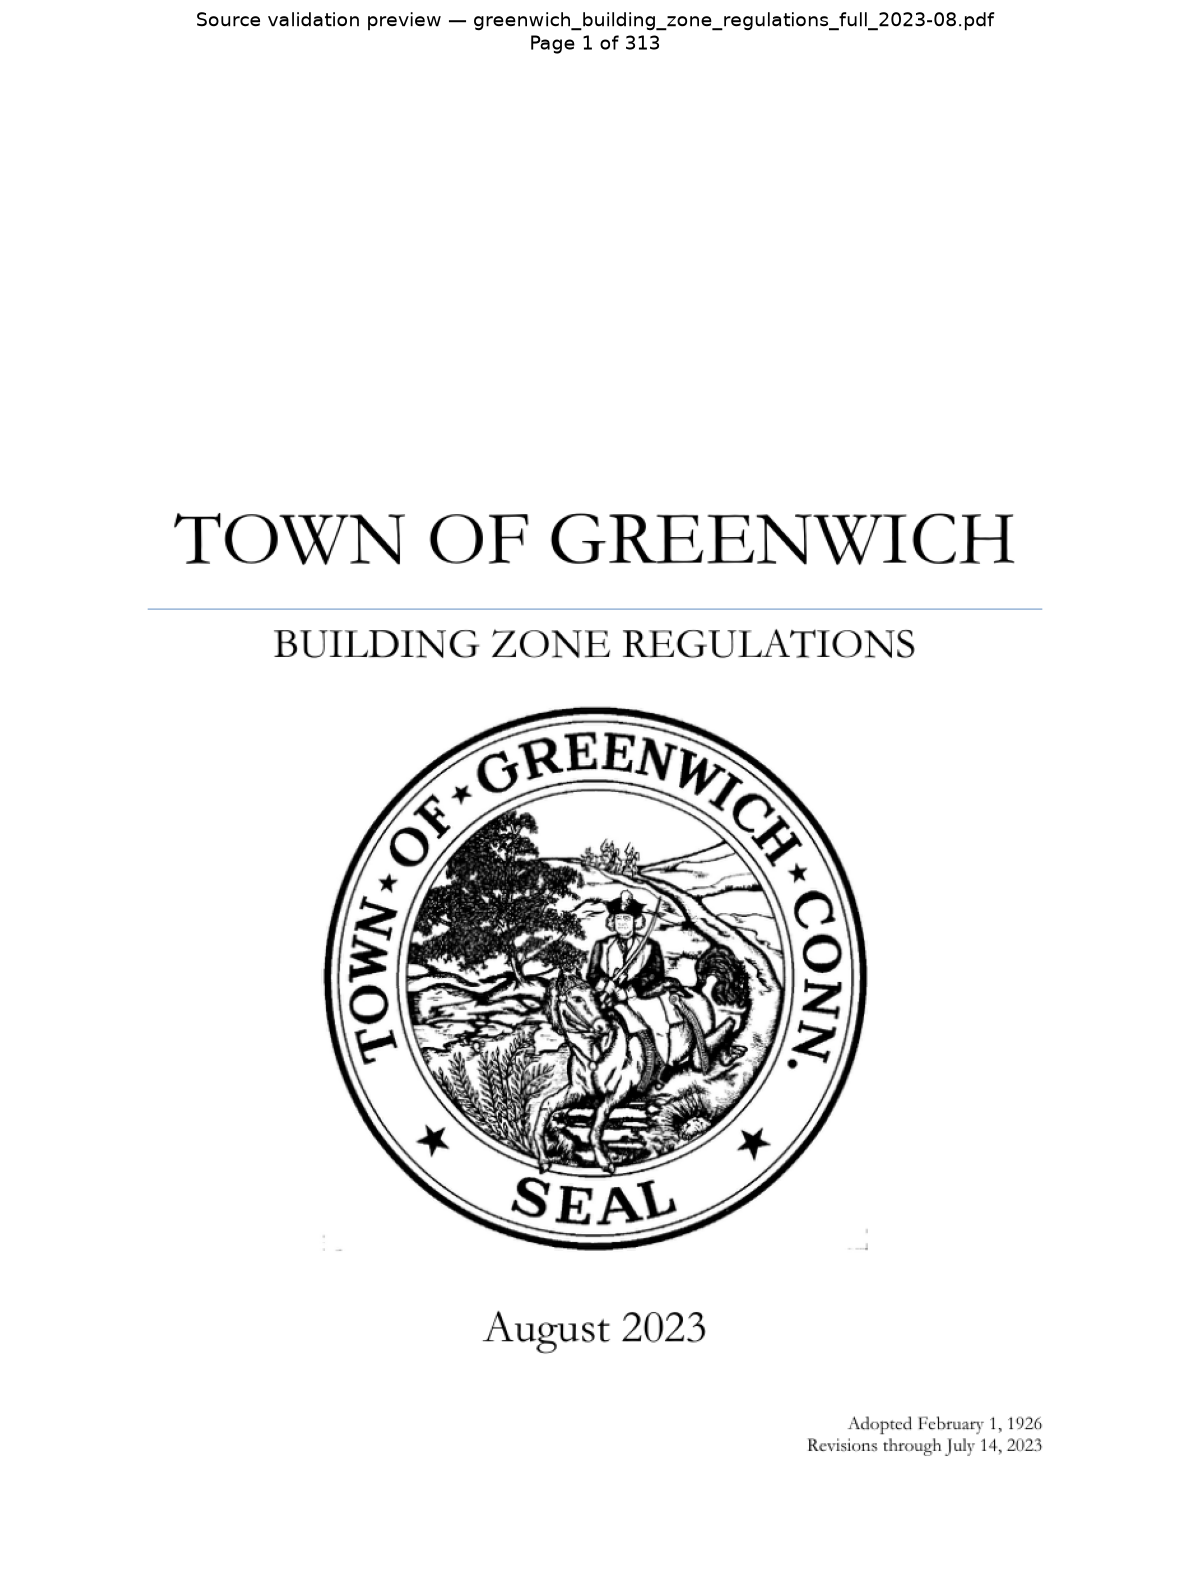

Saved first-page preview: outputs/figures/step_01_source_page_001_preview.png


In [8]:
def render_pdf_page(
    pdf_path: Path,
    page_number: int = 1,
    zoom: float = 1.5,
) -> np.ndarray:
    """
    Render a 1-indexed PDF page as an RGB NumPy image array.
    """
    if page_number < 1:
        raise ValueError("page_number must be at least 1.")

    with fitz.open(pdf_path) as document:
        if page_number > document.page_count:
            raise ValueError(
                f"page_number={page_number} exceeds the document page count "
                f"({document.page_count})."
            )

        page = document.load_page(page_number - 1)
        matrix = fitz.Matrix(zoom, zoom)
        pixmap = page.get_pixmap(matrix=matrix, alpha=False)

    image_shape = (pixmap.height, pixmap.width, 3)
    return np.frombuffer(pixmap.samples, dtype=np.uint8).reshape(image_shape)


first_page_image = render_pdf_page(PDF_PATH, page_number=1, zoom=1.5)

fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(first_page_image)
ax.set_title(
    f"Source validation preview — {PDF_PATH.name}\n"
    f"Page 1 of {PDF_PAGE_COUNT}",
    fontsize=14,
)
ax.axis("off")
plt.tight_layout()

first_page_preview_path = FIGURES_DIR / "step_01_source_page_001_preview.png"
fig.savefig(first_page_preview_path, dpi=200, bbox_inches="tight")

plt.show()

print(
    "Saved first-page preview: "
    f"{first_page_preview_path.relative_to(STAGE_A_ROOT)}"
)

## Step 2 — Source-document fingerprint and visual inspection

### Objective

Create a formal document-level fingerprint for the canonical Greenwich Building Zone Regulations PDF.

The fingerprint records both source provenance and automatically detected PDF characteristics so downstream extraction outputs can be traced to one exact input document

### Fingerprint fields

The record includes:

- stable document identifier
- jurisdiction and document title
- source URL and retrieval date
- local source path
- PDF filename, size, and page count
- SHA-256 file hash
- available PDF metadata
- detected or declared document-version information
- first-page textual evidence
- inspection and review status

### Outputs

This section produces:

1. A one-row document metadata dataframe
2. A PDF metadata-key inventory
3. A first-page text sample for manual verification
4. A high-resolution first-page rendered preview
5. A saved JSON fingerprint and CSV metadata table

### Scope boundary

This is still document-level validation. It does not yet create page-level text tokens, calculate quality scores, run OCR, or infer the legal hierarchy

In [9]:
import os
from typing import Any


def normalize_whitespace(text: str | None) -> str:
    """Collapse repeated whitespace while preserving the text content."""
    if not text:
        return ""

    return re.sub(r"\s+", " ", text).strip()


def safe_pdf_metadata(metadata: dict[str, Any] | None) -> dict[str, str]:
    """Keep non-empty PDF metadata values and convert them to strings."""
    metadata = metadata or {}

    return {
        str(key): normalize_whitespace(str(value))
        for key, value in metadata.items()
        if value not in (None, "", "null")
    }


def extract_first_page_text(pdf_path: Path) -> str:
    """Extract native text from page 1 for human source verification."""
    with fitz.open(pdf_path) as document:
        first_page = document.load_page(0)
        return normalize_whitespace(first_page.get_text("text"))


def detect_document_version(
    first_page_text: str,
    declared_version: str | None,
) -> dict[str, str]:
    """
    Identify likely version/update language from page-1 text.

    This is a heuristic inspection field, not a legal determination. The
    declared source version is preserved separately and should be manually
    verified against the document.
    """
    version_patterns = [
        r"(?:full\s+version|version|revised|revision|updated|effective|amended)"
        r"\s*(?:as\s+of|dated|on)?\s*[:\-]?\s*"
        r"([A-Z][a-z]+\s+\d{1,2},?\s+\d{4}|[A-Z][a-z]+\s+\d{4}|\d{1,2}/\d{1,2}/\d{2,4})",
        r"(?:ordinance|regulations?)\s*(?:no\.?|number)?\s*([A-Z0-9\-]+)",
    ]

    detected_matches = []

    for pattern in version_patterns:
        matches = re.findall(pattern, first_page_text, flags=re.IGNORECASE)
        detected_matches.extend(matches)

    detected_matches = [normalize_whitespace(match) for match in detected_matches]

    return {
        "declared_document_version": declared_version or "",
        "detected_version_candidates": " | ".join(
            dict.fromkeys(detected_matches)
        ),
        "version_detection_status": (
            "candidate_found" if detected_matches else "not_detected_on_page_1"
        ),
    }


def create_document_id(jurisdiction: str, sha256_hash: str) -> str:
    """
    Create a reproducible document ID from normalized jurisdiction text and
    the first 16 hexadecimal characters of the source-file SHA-256 hash.
    """
    jurisdiction_slug = re.sub(r"[^a-z0-9]+", "-", jurisdiction.lower()).strip("-")
    return f"{jurisdiction_slug}-{sha256_hash[:16]}"

In [10]:
first_page_text = extract_first_page_text(PDF_PATH)
first_page_text_preview = first_page_text[:2_500]

pymupdf_metadata_clean = safe_pdf_metadata(PDF_METADATA)
pdfplumber_metadata_clean = safe_pdf_metadata(PDFPLUMBER_METADATA)

version_info = detect_document_version(
    first_page_text=first_page_text,
    declared_version=SOURCE_CONFIG.get("document_version_date"),
)

DOCUMENT_ID = create_document_id(
    jurisdiction=SOURCE_CONFIG["jurisdiction"],
    sha256_hash=PDF_SHA256,
)

first_page_text_df = pd.DataFrame(
    {
        "field": [
            "document_id",
            "first_page_native_text_character_count",
            "first_page_text_preview",
        ],
        "value": [
            DOCUMENT_ID,
            len(first_page_text),
            first_page_text_preview,
        ],
    }
)

first_page_text_df

,field,value
0,document_id,greenwich-connecticut-18417c5e9074d765
1,first_page_native_text_character_count,112
2,first_page_text_preview,TOWN OF GREENWICH BUILDING ZONE REGULATIONS Au...


In [11]:
document_record = {
    "document_id": DOCUMENT_ID,
    "jurisdiction": SOURCE_CONFIG["jurisdiction"],
    "document_name": SOURCE_CONFIG["document_name"],
    "document_filename": PDF_PATH.name,
    "local_path_relative_to_stage_a": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    "source_url": SOURCE_CONFIG["source_url"],
    "date_retrieved": SOURCE_CONFIG["date_retrieved"],
    "declared_document_version": version_info["declared_document_version"],
    "detected_version_candidates": version_info["detected_version_candidates"],
    "version_detection_status": version_info["version_detection_status"],
    "file_size_mb": round(PDF_SIZE_MB, 3),
    "page_count": PDF_PAGE_COUNT,
    "sha256": PDF_SHA256,
    "first_page_native_text_character_count": len(first_page_text),
    "pdf_title": pymupdf_metadata_clean.get("title", ""),
    "pdf_author": pymupdf_metadata_clean.get("author", ""),
    "pdf_subject": pymupdf_metadata_clean.get("subject", ""),
    "pdf_creator": pymupdf_metadata_clean.get("creator", ""),
    "pdf_producer": pymupdf_metadata_clean.get("producer", ""),
    "pdf_creation_date": pymupdf_metadata_clean.get("creationDate", ""),
    "pdf_modification_date": pymupdf_metadata_clean.get("modDate", ""),
    "initial_inspection_status": "pending_manual_first_page_review",
    "pipeline_run_timestamp_utc": run_timestamp_utc,
}

document_metadata_df = pd.DataFrame([document_record])

document_metadata_df.T.rename(columns={0: "value"})

,value
document_id,greenwich-connecticut-18417c5e9074d765
jurisdiction,"Greenwich, Connecticut"
document_name,Town of Greenwich Building Zone Regulations
document_filename,greenwich_building_zone_regulations_full_2023-...
local_path_relative_to_stage_a,data/raw/greenwich/greenwich_building_zone_reg...
source_url,https://www.greenwichct.gov/442/Building-Zone-...
date_retrieved,2026-09-29
declared_document_version,August 2023
detected_version_candidates,August
version_detection_status,candidate_found


In [12]:
metadata_inventory_rows = []

for source_name, metadata_dict in [
    ("pymupdf", pymupdf_metadata_clean),
    ("pdfplumber", pdfplumber_metadata_clean),
]:
    for metadata_key, metadata_value in metadata_dict.items():
        metadata_inventory_rows.append(
            {
                "document_id": DOCUMENT_ID,
                "metadata_reader": source_name,
                "metadata_key": metadata_key,
                "metadata_value": metadata_value,
            }
        )

pdf_metadata_inventory_df = pd.DataFrame(metadata_inventory_rows)

if pdf_metadata_inventory_df.empty:
    pdf_metadata_inventory_df = pd.DataFrame(
        [
            {
                "document_id": DOCUMENT_ID,
                "metadata_reader": "none",
                "metadata_key": "no_embedded_metadata_detected",
                "metadata_value": "",
            }
        ]
    )

pdf_metadata_inventory_df

,document_id,metadata_reader,metadata_key,metadata_value
0,greenwich-connecticut-18417c5e9074d765,pymupdf,format,PDF 1.6
1,greenwich-connecticut-18417c5e9074d765,pymupdf,author,Patrick LaRow
2,greenwich-connecticut-18417c5e9074d765,pymupdf,subject,BUILDING ZONE REGULATIONS
3,greenwich-connecticut-18417c5e9074d765,pymupdf,creator,Adobe Acrobat Pro 2017 17.12.30205
4,greenwich-connecticut-18417c5e9074d765,pymupdf,producer,Adobe Acrobat Pro 2017 17.12.30205
5,greenwich-connecticut-18417c5e9074d765,pymupdf,creationDate,D:20230802110515-04'00'
6,greenwich-connecticut-18417c5e9074d765,pymupdf,modDate,D:20230802110515-04'00'
7,greenwich-connecticut-18417c5e9074d765,pdfplumber,Author,Patrick LaRow
8,greenwich-connecticut-18417c5e9074d765,pdfplumber,CreationDate,D:20230802110515-04'00'
9,greenwich-connecticut-18417c5e9074d765,pdfplumber,Creator,Adobe Acrobat Pro 2017 17.12.30205


### High-resolution first-page inspection

The rendered preview below is the authoritative visual validation artifact for this step.

Inspect the image and confirm:

- the title identifies the Town of Greenwich and Building Zone Regulations
- the document appears to be the intended full-version code
- the page is legible and has not rendered as blank or corrupted
- any visible version, amendment, or effective-date language agrees with the declared source configuration
- no unexpected cover page, password warning, scanning artifact, or unrelated document is present

After inspection, update the `initial_inspection_status` in the next code cell from `pending_manual_first_page_review` to either:

- `passed_manual_first_page_review`
- `flagged_for_source_review`

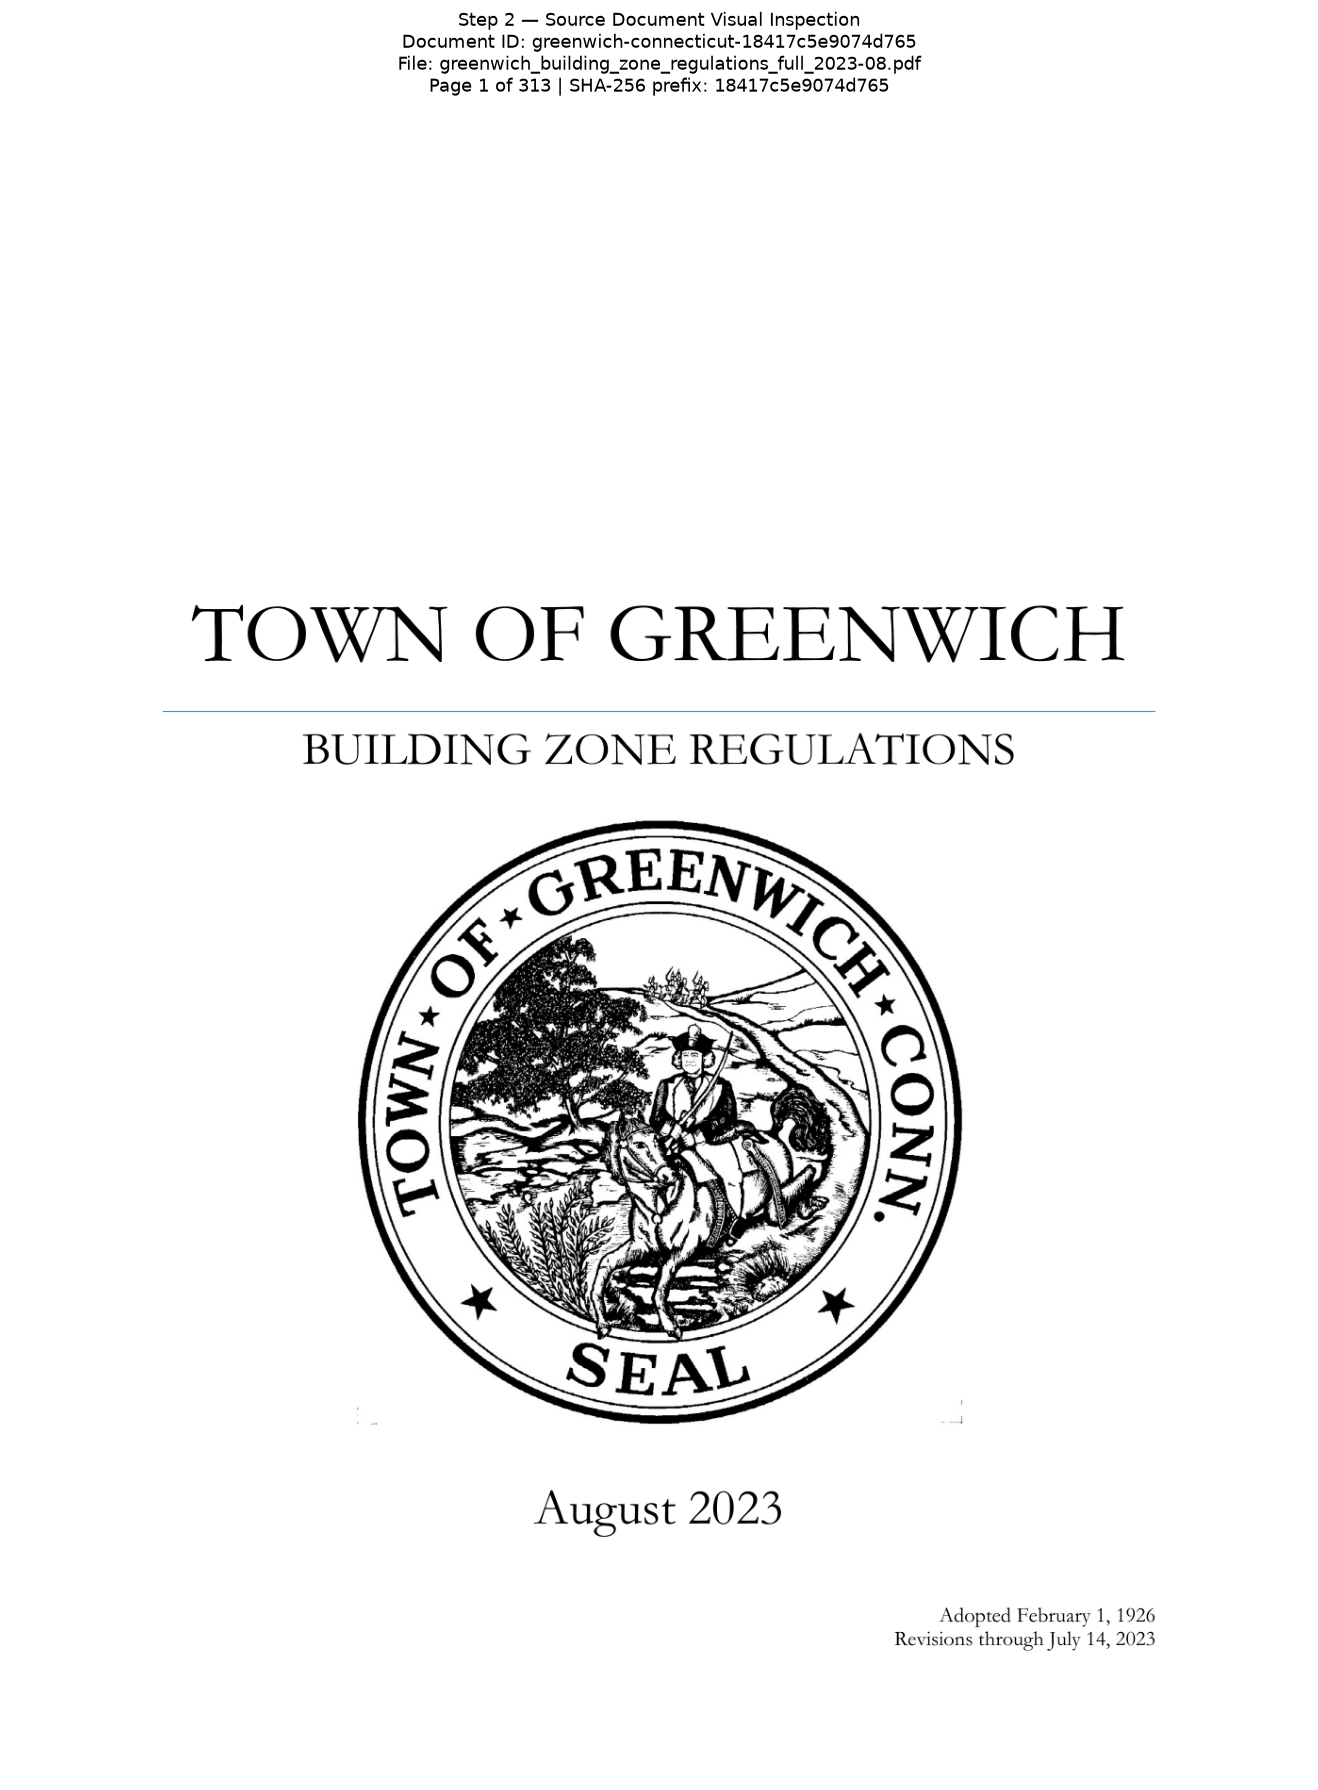

Saved high-resolution source inspection preview: outputs/figures/step_02_document_fingerprint_page_001.png


In [13]:
first_page_image_high_res = render_pdf_page(
    PDF_PATH,
    page_number=1,
    zoom=2.25,
)

fig, ax = plt.subplots(figsize=(14, 18))
ax.imshow(first_page_image_high_res)
ax.set_title(
    "\n".join(
        [
            "Step 2 — Source Document Visual Inspection",
            f"Document ID: {DOCUMENT_ID}",
            f"File: {PDF_PATH.name}",
            f"Page 1 of {PDF_PAGE_COUNT} | SHA-256 prefix: {PDF_SHA256[:16]}",
        ]
    ),
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()

step_2_preview_path = FIGURES_DIR / "step_02_document_fingerprint_page_001.png"
fig.savefig(step_2_preview_path, dpi=250, bbox_inches="tight")

plt.show()

print(
    "Saved high-resolution source inspection preview: "
    f"{step_2_preview_path.relative_to(STAGE_A_ROOT)}"
)

In [14]:
MANUAL_FIRST_PAGE_REVIEW_STATUS = "passed_manual_first_page_review"
MANUAL_FIRST_PAGE_REVIEW_NOTE = (
    "Page 1 visually confirmed as the intended Greenwich Building Zone "
    "Regulations source document."
)

allowed_review_statuses = {
    "passed_manual_first_page_review",
    "flagged_for_source_review",
}

if MANUAL_FIRST_PAGE_REVIEW_STATUS not in allowed_review_statuses:
    raise ValueError(
        "MANUAL_FIRST_PAGE_REVIEW_STATUS must be one of: "
        f"{sorted(allowed_review_statuses)}"
    )

document_metadata_df.loc[
    0, "initial_inspection_status"
] = MANUAL_FIRST_PAGE_REVIEW_STATUS

document_metadata_df["initial_inspection_note"] = MANUAL_FIRST_PAGE_REVIEW_NOTE

document_metadata_df.T.rename(columns={0: "value"})

,value
document_id,greenwich-connecticut-18417c5e9074d765
jurisdiction,"Greenwich, Connecticut"
document_name,Town of Greenwich Building Zone Regulations
document_filename,greenwich_building_zone_regulations_full_2023-...
local_path_relative_to_stage_a,data/raw/greenwich/greenwich_building_zone_reg...
source_url,https://www.greenwichct.gov/442/Building-Zone-...
date_retrieved,2026-09-29
declared_document_version,August 2023
detected_version_candidates,August
version_detection_status,candidate_found


## Step 3 — Native text and layout-metadata extraction

### Objective

Extract the native PDF text layer from every page of the canonical Greenwich zoning-code PDF while preserving page-level spatial and layout provenance.

This step creates two linked datasets:

1. **Word tokens:** individual extracted words with page number, bounding box, block/line/word position, and preliminary reading-order coordinates.
2. **Text spans:** contiguous text segments that share font properties, with font name, font size, flags, color, bounding box, and writing direction.

### Why two levels are retained

Word tokens are useful for later token-level provenance, reading-order reconstruction, and bounding-box validation.

Spans are useful for heading detection because font size, font name, bold/italic indicators, indentation, and line geometry are often stronger heading signals than word text alone.

### Scope boundary

This is native-stream extraction only.

In [15]:
NATIVE_EXTRACTION_CONFIG = {
    "engine": "PyMuPDF",
    "word_extraction_mode": "words",
    "span_extraction_mode": "dict",
    "sort_reading_order": True,
    "include_word_tokens": True,
    "include_text_spans": True,
    "exclude_empty_text": True,
    "minimum_word_length": 1,
    "page_number_base": 1,
    "initial_section_number": None,
    "initial_heading_depth": None,
    "initial_table_id": None,
    "initial_normalized_text_span": None,
    "output_word_tokens_filename": "step_03_native_word_tokens.parquet",
    "output_text_spans_filename": "step_03_native_text_spans.parquet",
    "output_page_summary_filename": "step_03_native_page_summary.csv",
}

NATIVE_EXTRACTION_CONFIG

{'engine': 'PyMuPDF',
 'word_extraction_mode': 'words',
 'span_extraction_mode': 'dict',
 'sort_reading_order': True,
 'include_word_tokens': True,
 'include_text_spans': True,
 'exclude_empty_text': True,
 'minimum_word_length': 1,
 'page_number_base': 1,
 'initial_section_number': None,
 'initial_heading_depth': None,
 'initial_table_id': None,
 'initial_normalized_text_span': None,
 'output_word_tokens_filename': 'step_03_native_word_tokens.parquet',
 'output_text_spans_filename': 'step_03_native_text_spans.parquet',
 'output_page_summary_filename': 'step_03_native_page_summary.csv'}

### Coordinate convention and provisional schema

PyMuPDF returns page coordinates in PDF page units, normally points, using:

$$B_i = (x_0, y_0, x_1, y_1)$$

where:

* $x_0, y_0$ are the upper-left coordinates of the extracted word or span;
* $x_1, y_1$ are the lower-right coordinates;
* each page is numbered using a human-readable 1-based page index.

The word-token table begins the eventual layout-aware token tuple:

$$u_i = \langle T_i, P_i, B_i, S_i, H_i, \Gamma_i, \Delta_i \rangle$$

At this step:

* $T_i$, $P_i$, and $B_i$ are extracted from the native PDF;
* $S_i$, $H_i$, $\Gamma_i$, and $\Delta_i$ remain explicitly unassigned;
* extraction-engine and reading-order fields are added as audit metadata.

In [16]:
def clean_extracted_text(text: str | None) -> str:
    """Normalize surrounding whitespace without changing internal text meaning."""
    if text is None:
        return ""

    return re.sub(r"\s+", " ", text).strip()


def rgb_integer_to_hex(color_value: int | None) -> str | None:
    """
    Convert PyMuPDF's integer RGB color representation to #RRGGBB when present.
    """
    if color_value is None:
        return None

    return f"#{color_value:06x}"


def extract_native_layout_data(
    pdf_path: Path,
    document_id: str,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Extract word-level and span-level native PDF content with layout provenance.

    Returns:
        word_tokens_df: One row per extracted native word.
        text_spans_df: One row per extracted font-consistent text span.
        page_summary_df: One row per PDF page with basic extraction diagnostics.
    """
    word_records = []
    span_records = []
    page_records = []

    with fitz.open(pdf_path) as document:
        for page_index in range(document.page_count):
            page = document.load_page(page_index)
            page_number = page_index + config["page_number_base"]

            page_rect = page.rect
            page_width = float(page_rect.width)
            page_height = float(page_rect.height)

            words = page.get_text(
                config["word_extraction_mode"],
                sort=config["sort_reading_order"],
            )

            native_page_text = clean_extracted_text(
                page.get_text("text", sort=config["sort_reading_order"])
            )

            text_dict = page.get_text(
                config["span_extraction_mode"],
                sort=config["sort_reading_order"],
            )

            retained_words_on_page = 0

            for extracted_word_index, word in enumerate(words):
                x0, y0, x1, y1, text, block_no, line_no, word_no = word
                text = clean_extracted_text(text)

                if config["exclude_empty_text"] and not text:
                    continue

                if len(text) < config["minimum_word_length"]:
                    continue

                retained_words_on_page += 1

                word_records.append(
                    {
                        "document_id": document_id,
                        "token_id": (
                            f"{document_id}-p{page_number:04d}"
                            f"-w{retained_words_on_page:06d}"
                        ),
                        "text": text,
                        "page_number": page_number,
                        "bbox_x0": float(x0),
                        "bbox_y0": float(y0),
                        "bbox_x1": float(x1),
                        "bbox_y1": float(y1),
                        "bbox_width": float(x1 - x0),
                        "bbox_height": float(y1 - y0),
                        "page_width": page_width,
                        "page_height": page_height,
                        "block_number": int(block_no),
                        "line_number": int(line_no),
                        "word_number_in_line": int(word_no),
                        "native_word_sequence_on_page": retained_words_on_page,
                        "native_word_index_raw": extracted_word_index,
                        "reading_order_source": "pymupdf_words_sort_true",
                        "extraction_engine": "pymupdf_native",
                        "extraction_method": "native_text_stream",
                        "section_number": config["initial_section_number"],
                        "heading_depth": config["initial_heading_depth"],
                        "table_id": config["initial_table_id"],
                        "normalized_text_start": config["initial_normalized_text_span"],
                        "normalized_text_end": config["initial_normalized_text_span"],
                        "token_confidence": None,
                        "review_status": "not_yet_scored",
                    }
                )

            retained_spans_on_page = 0

            for block_index, block in enumerate(text_dict.get("blocks", [])):
                if block.get("type") != 0:
                    continue

                for line_index, line in enumerate(block.get("lines", [])):
                    line_bbox = line.get("bbox", [None, None, None, None])
                    line_direction = line.get("dir", [None, None])
                    writing_mode = line.get("wmode", None)

                    for span_index, span in enumerate(line.get("spans", [])):
                        span_text = clean_extracted_text(span.get("text", ""))

                        if config["exclude_empty_text"] and not span_text:
                            continue

                        retained_spans_on_page += 1

                        x0, y0, x1, y1 = span.get(
                            "bbox",
                            [None, None, None, None],
                        )

                        span_records.append(
                            {
                                "document_id": document_id,
                                "span_id": (
                                    f"{document_id}-p{page_number:04d}"
                                    f"-s{retained_spans_on_page:06d}"
                                ),
                                "text": span_text,
                                "page_number": page_number,
                                "bbox_x0": float(x0) if x0 is not None else None,
                                "bbox_y0": float(y0) if y0 is not None else None,
                                "bbox_x1": float(x1) if x1 is not None else None,
                                "bbox_y1": float(y1) if y1 is not None else None,
                                "bbox_width": (
                                    float(x1 - x0)
                                    if x0 is not None and x1 is not None
                                    else None
                                ),
                                "bbox_height": (
                                    float(y1 - y0)
                                    if y0 is not None and y1 is not None
                                    else None
                                ),
                                "page_width": page_width,
                                "page_height": page_height,
                                "block_number": int(block_index),
                                "line_number": int(line_index),
                                "span_number_in_line": int(span_index),
                                "line_bbox_x0": (
                                    float(line_bbox[0])
                                    if line_bbox[0] is not None
                                    else None
                                ),
                                "line_bbox_y0": (
                                    float(line_bbox[1])
                                    if line_bbox[1] is not None
                                    else None
                                ),
                                "line_bbox_x1": (
                                    float(line_bbox[2])
                                    if line_bbox[2] is not None
                                    else None
                                ),
                                "line_bbox_y1": (
                                    float(line_bbox[3])
                                    if line_bbox[3] is not None
                                    else None
                                ),
                                "line_direction_x": (
                                    float(line_direction[0])
                                    if line_direction[0] is not None
                                    else None
                                ),
                                "line_direction_y": (
                                    float(line_direction[1])
                                    if line_direction[1] is not None
                                    else None
                                ),
                                "writing_mode": writing_mode,
                                "font_name": span.get("font"),
                                "font_size": (
                                    float(span.get("size"))
                                    if span.get("size") is not None
                                    else None
                                ),
                                "font_flags": span.get("flags"),
                                "font_color_hex": rgb_integer_to_hex(
                                    span.get("color")
                                ),
                                "font_ascender": span.get("ascender"),
                                "font_descender": span.get("descender"),
                                "span_origin_x": (
                                    float(span["origin"][0])
                                    if span.get("origin") is not None
                                    else None
                                ),
                                "span_origin_y": (
                                    float(span["origin"][1])
                                    if span.get("origin") is not None
                                    else None
                                ),
                                "native_span_sequence_on_page": retained_spans_on_page,
                                "reading_order_source": "pymupdf_dict_sort_true",
                                "extraction_engine": "pymupdf_native",
                                "extraction_method": "native_text_stream",
                                "section_number": config["initial_section_number"],
                                "heading_depth": config["initial_heading_depth"],
                                "table_id": config["initial_table_id"],
                                "normalized_text_start": config["initial_normalized_text_span"],
                                "normalized_text_end": config["initial_normalized_text_span"],
                                "span_confidence": None,
                                "review_status": "not_yet_scored",
                            }
                        )

            page_records.append(
                {
                    "document_id": document_id,
                    "page_number": page_number,
                    "page_width": page_width,
                    "page_height": page_height,
                    "native_word_count": retained_words_on_page,
                    "native_span_count": retained_spans_on_page,
                    "native_text_character_count": len(native_page_text),
                    "native_text_preview": native_page_text[:500],
                    "extraction_engine": "pymupdf_native",
                    "extraction_method": "native_text_stream",
                    "review_status": "not_yet_scored",
                }
            )

    return (
        pd.DataFrame(word_records),
        pd.DataFrame(span_records),
        pd.DataFrame(page_records),
    )

In [17]:
word_tokens_df, text_spans_df, native_page_summary_df = extract_native_layout_data(
    pdf_path=PDF_PATH,
    document_id=DOCUMENT_ID,
    config=NATIVE_EXTRACTION_CONFIG,
)

assert len(native_page_summary_df) == PDF_PAGE_COUNT, (
    "The page summary must contain exactly one row for every PDF page."
)

assert word_tokens_df["page_number"].between(1, PDF_PAGE_COUNT).all(), (
    "Every word token must have a valid 1-based page number."
)

assert text_spans_df["page_number"].between(1, PDF_PAGE_COUNT).all(), (
    "Every text span must have a valid 1-based page number."
)

print(f"Pages processed: {len(native_page_summary_df):,}")
print(f"Native word tokens extracted: {len(word_tokens_df):,}")
print(f"Native text spans extracted: {len(text_spans_df):,}")
print(
    "Pages with zero native words: "
    f"{(native_page_summary_df['native_word_count'] == 0).sum():,}"
)

Pages processed: 313
Native word tokens extracted: 125,276
Native text spans extracted: 17,550
Pages with zero native words: 0


### Token-level extraction preview

The table below is the initial machine-readable representation of native text tokens.

At this stage, the extracted fields correspond to:

- \(T_i\): `text`
- \(P_i\): `page_number`
- \(B_i\): `bbox_x0`, `bbox_y0`, `bbox_x1`, `bbox_y1`

The following fields intentionally remain empty until later collection steps:

- `section_number`
- `heading_depth`
- `table_id`
- `normalized_text_start`
- `normalized_text_end`

The word-level order fields are a preliminary, engine-reported reading sequence. They will be evaluated by the page-quality and reading-order checks in the next step.

In [18]:
word_preview_columns = [
    "token_id",
    "text",
    "page_number",
    "bbox_x0",
    "bbox_y0",
    "bbox_x1",
    "bbox_y1",
    "block_number",
    "line_number",
    "word_number_in_line",
    "native_word_sequence_on_page",
    "section_number",
    "heading_depth",
    "table_id",
    "review_status",
]

word_tokens_df[word_preview_columns].head(30)

,token_id,text,page_number,bbox_x0,bbox_y0,bbox_x1,bbox_y1,block_number,line_number,word_number_in_line,native_word_sequence_on_page,section_number,heading_depth,table_id,review_status
0,greenwich-connecticut-18417c5e9074d765-p0001-w...,TOWN,1,85.800003,224.599442,207.829834,276.267731,1,0,0,1,None,None,None,not_yet_scored
1,greenwich-connecticut-18417c5e9074d765-p0001-w...,OF,1,217.819824,224.599442,271.514069,276.267731,1,0,1,2,None,None,None,not_yet_scored
2,greenwich-connecticut-18417c5e9074d765-p0001-w...,GREENWICH,1,281.528076,224.599442,526.227173,276.267731,1,0,2,3,None,None,None,not_yet_scored
3,greenwich-connecticut-18417c5e9074d765-p0001-w...,BUILDING,1,137.759995,291.427429,245.891022,319.821716,2,0,0,4,None,None,None,not_yet_scored
4,greenwich-connecticut-18417c5e9074d765-p0001-w...,ZONE,1,251.391998,291.427429,314.274445,319.821716,2,0,1,5,None,None,None,not_yet_scored
5,greenwich-connecticut-18417c5e9074d765-p0001-w...,REGULATIONS,1,319.915985,291.427429,473.949982,319.821716,2,0,2,6,None,None,None,not_yet_scored
6,greenwich-connecticut-18417c5e9074d765-p0001-w...,August,1,247.320007,647.496033,313.608032,678.528015,3,1,0,7,None,None,None,not_yet_scored
7,greenwich-connecticut-18417c5e9074d765-p0001-w...,2023,1,319.559998,647.496033,364.656006,678.528015,3,1,1,8,None,None,None,not_yet_scored
8,greenwich-connecticut-18417c5e9074d765-p0001-w...,Adopted,1,438.119141,707.534668,472.019012,720.412964,5,0,0,9,None,None,None,not_yet_scored
9,greenwich-connecticut-18417c5e9074d765-p0001-w...,February,1,474.598663,707.534668,509.351074,720.412964,5,0,1,10,None,None,None,not_yet_scored


In [19]:
span_preview_columns = [
    "span_id",
    "text",
    "page_number",
    "bbox_x0",
    "bbox_y0",
    "bbox_x1",
    "bbox_y1",
    "font_name",
    "font_size",
    "font_flags",
    "font_color_hex",
    "block_number",
    "line_number",
    "span_number_in_line",
    "line_direction_x",
    "line_direction_y",
]

text_spans_df[span_preview_columns].head(30)

,span_id,text,page_number,bbox_x0,bbox_y0,bbox_x1,bbox_y1,font_name,font_size,font_flags,font_color_hex,block_number,line_number,span_number_in_line,line_direction_x,line_direction_y
0,greenwich-connecticut-18417c5e9074d765-p0001-s...,TOWN OF GREENWICH,1,85.800003,224.599442,536.189148,276.267731,Garamond,39.959999,4,#000000,1,0,0,1.0,0.0
1,greenwich-connecticut-18417c5e9074d765-p0001-s...,BUILDING ZONE REGULATIONS,1,137.759995,291.427429,473.949982,319.821716,Garamond,21.959999,4,#000000,2,0,0,1.0,0.0
2,greenwich-connecticut-18417c5e9074d765-p0001-s...,August 2023,1,247.320007,647.496033,370.559998,678.528015,Garamond,24.000000,4,#000000,4,1,0,1.0,0.0
3,greenwich-connecticut-18417c5e9074d765-p0001-s...,"Adopted February 1, 1926",1,438.119141,707.534668,542.494019,720.412964,Garamond,9.960000,4,#000000,6,0,0,1.0,0.0
4,greenwich-connecticut-18417c5e9074d765-p0001-s...,"Revisions through July 14, 2023",1,416.874451,718.819336,542.489014,731.697632,Garamond,9.960000,4,#000000,6,1,0,1.0,0.0
5,greenwich-connecticut-18417c5e9074d765-p0002-s...,BUILDING ZONE REGULATIONS,2,211.320007,70.487976,403.679993,87.095970,TimesNewRomanPS-BoldMT,12.000000,20,#000000,0,0,0,1.0,0.0
6,greenwich-connecticut-18417c5e9074d765-p0002-s...,OF THE,2,283.440002,84.287964,331.440002,100.895958,TimesNewRomanPS-BoldMT,12.000000,20,#000000,1,0,0,1.0,0.0
7,greenwich-connecticut-18417c5e9074d765-p0002-s...,TOWN OF GREENWICH,2,237.000000,98.087952,378.000000,114.695946,TimesNewRomanPS-BoldMT,12.000000,20,#000000,1,1,0,1.0,0.0
8,greenwich-connecticut-18417c5e9074d765-p0002-s...,CONNECTICUT,2,261.000000,111.887939,354.000000,128.495941,TimesNewRomanPS-BoldMT,12.000000,20,#000000,2,0,0,1.0,0.0
9,greenwich-connecticut-18417c5e9074d765-p0002-s...,PLANNING AND ZONING COMMISSION,2,191.399994,167.088013,423.480316,183.696014,TimesNewRomanPS-BoldMT,12.000000,20,#000000,4,0,0,1.0,0.0


### Multi-page native-text samples

A full-document token count can hide localized failures. The samples below inspect early, middle, and late pages to detect obvious issues such as:

- blank native extraction
- unreadable character sequences
- broken word order
- repeated headers/footers dominating the text
- pages that appear to be scans rather than native text
- an incorrect document being processed

These samples are not yet scored. They are a quick visual diagnostic before automated quality routing

In [20]:
sample_page_numbers = sorted(
    set(
        [
            1,
            max(1, PDF_PAGE_COUNT // 2),
            PDF_PAGE_COUNT,
        ]
    )
)

text_sample_rows = []

for page_number in sample_page_numbers:
    page_row = native_page_summary_df.loc[
        native_page_summary_df["page_number"] == page_number
    ].iloc[0]

    text_sample_rows.append(
        {
            "page_number": page_number,
            "native_word_count": page_row["native_word_count"],
            "native_span_count": page_row["native_span_count"],
            "native_text_character_count": page_row[
                "native_text_character_count"
            ],
            "native_text_sample": page_row["native_text_preview"],
        }
    )

native_text_samples_df = pd.DataFrame(text_sample_rows)

for _, sample_row in native_text_samples_df.iterrows():
    print("=" * 100)
    print(
        f"PAGE {int(sample_row['page_number'])} | "
        f"words={int(sample_row['native_word_count'])} | "
        f"spans={int(sample_row['native_span_count'])} | "
        f"characters={int(sample_row['native_text_character_count'])}"
    )
    print("-" * 100)
    print(sample_row["native_text_sample"])
    print()

PAGE 1 | words=17 | spans=5 | characters=112
----------------------------------------------------------------------------------------------------
TOWN OF GREENWICH BUILDING ZONE REGULATIONS August 2023 Adopted February 1, 1926 Revisions through July 14, 2023

PAGE 156 | words=578 | spans=60 | characters=3637
----------------------------------------------------------------------------------------------------
§6-139.1 GREENWICH MUNICIPAL CODE §6-139.1 approximate (rounded up or down) and should be verified with the BFEs published in the FIS for a specific location. The determination of areas of special flood hazard shall be based on the flood elevations shown on the FIRM and published in the FIS in conjunction with an up-to-date and accurate topographical survey of the site prepared by a Connecticut Licensed Land Surveyor. Areas of special flood hazard shall also include areas where the land surface 

PAGE 313 | words=166 | spans=19 | characters=963
--------------------------------------

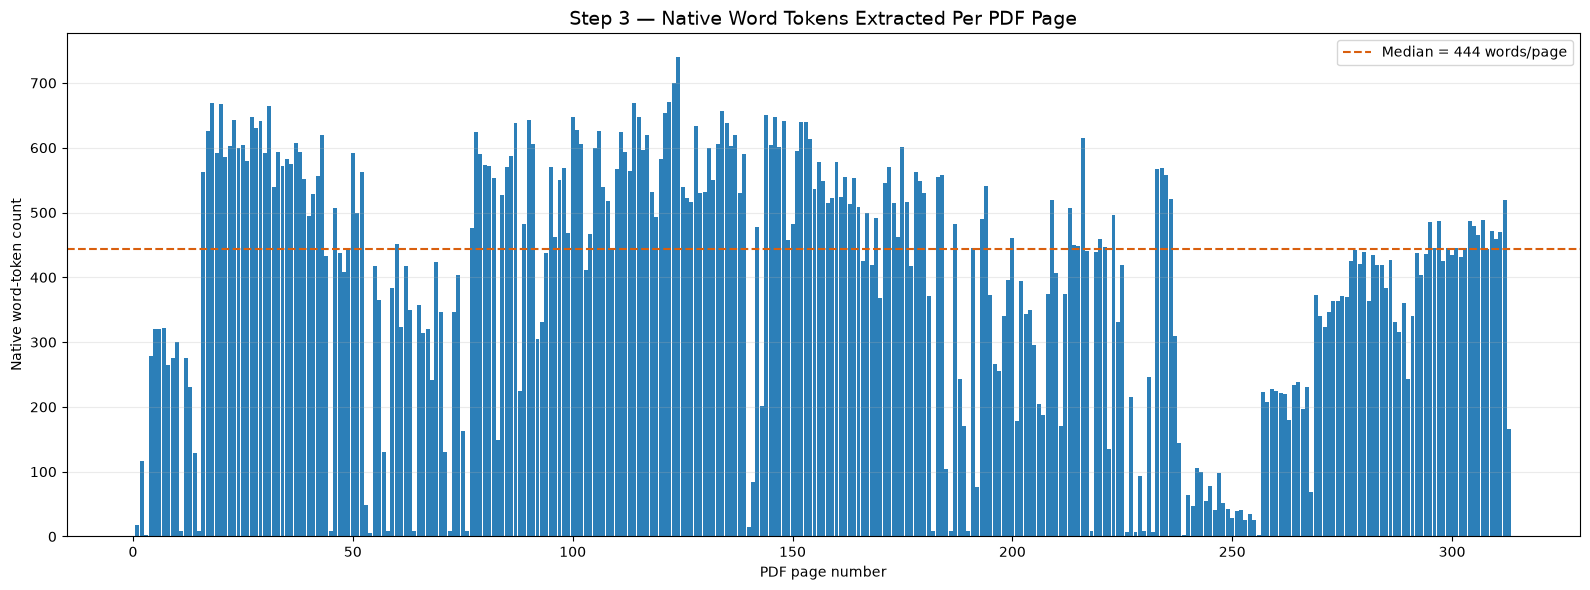

Saved words-per-page chart: outputs/figures/step_03_native_words_per_page.png


In [21]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(
    native_page_summary_df["page_number"],
    native_page_summary_df["native_word_count"],
    color="#2C7FB8",
    width=0.9,
)

ax.axhline(
    native_page_summary_df["native_word_count"].median(),
    color="#D95F0E",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Median = "
        f"{native_page_summary_df['native_word_count'].median():.0f} words/page"
    ),
)

ax.set_title("Step 3 — Native Word Tokens Extracted Per PDF Page", fontsize=14)
ax.set_xlabel("PDF page number")
ax.set_ylabel("Native word-token count")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

words_per_page_figure_path = FIGURES_DIR / "step_03_native_words_per_page.png"
fig.savefig(words_per_page_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(
    "Saved words-per-page chart: "
    f"{words_per_page_figure_path.relative_to(STAGE_A_ROOT)}"
)

### Spatial overlay validation

The following visualizations draw a sampled set of extracted word bounding boxes on top of rendered PDF pages

These overlays verify that:

- extracted words map to the visible text on the page
- PDF coordinate orientation is correct
- boxes are not systematically shifted, inverted, or scaled incorrectly
- reading-order sequence roughly proceeds from top to bottom and left to right
- complex formatting such as tables, headers, sidebars, or multi-column content can be identified for later quality scoring

A small sample is shown rather than every word on the page, because drawing every box would make the page unreadable

In [22]:
from matplotlib.patches import Rectangle


def plot_token_overlay(
    pdf_path: Path,
    tokens_df: pd.DataFrame,
    page_number: int,
    sample_size: int = 80,
    zoom: float = 1.5,
    seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Render a page and overlay sampled native-word bounding boxes.

    Tokens are sampled reproducibly. The first few tokens in preliminary
    reading order are included so labels help visually verify the sequence.
    """
    page_tokens = tokens_df.loc[
        tokens_df["page_number"] == page_number
    ].copy()

    if page_tokens.empty:
        raise ValueError(f"No word tokens were extracted for page {page_number}.")

    page_tokens = page_tokens.sort_values("native_word_sequence_on_page")

    first_tokens = page_tokens.head(min(15, len(page_tokens)))

    remaining_tokens = page_tokens.iloc[len(first_tokens):]

    sample_count = min(
        max(sample_size - len(first_tokens), 0),
        len(remaining_tokens),
    )

    sampled_remaining = (
        remaining_tokens.sample(n=sample_count, random_state=seed)
        if sample_count > 0
        else remaining_tokens.head(0)
    )

    overlay_tokens = (
        pd.concat([first_tokens, sampled_remaining])
        .drop_duplicates(subset="token_id")
        .sort_values("native_word_sequence_on_page")
    )

    page_image = render_pdf_page(
        pdf_path=pdf_path,
        page_number=page_number,
        zoom=zoom,
    )

    page_height_points = float(page_tokens["page_height"].iloc[0])

    fig, ax = plt.subplots(figsize=(13, 17))
    ax.imshow(page_image)

    scale = zoom

    for _, token in overlay_tokens.iterrows():
        x0 = token["bbox_x0"] * scale
        y0 = token["bbox_y0"] * scale
        width = token["bbox_width"] * scale
        height = token["bbox_height"] * scale

        is_early_sequence_token = (
            token["native_word_sequence_on_page"]
            <= len(first_tokens)
        )

        rectangle_color = "#E31A1C" if is_early_sequence_token else "#1F78B4"

        rectangle = Rectangle(
            (x0, y0),
            width,
            height,
            linewidth=0.8,
            edgecolor=rectangle_color,
            facecolor="none",
            alpha=0.8,
        )

        ax.add_patch(rectangle)

        if is_early_sequence_token:
            ax.text(
                x0,
                max(0, y0 - 3),
                str(int(token["native_word_sequence_on_page"])),
                color=rectangle_color,
                fontsize=6,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.75,
                    "pad": 0.5,
                },
            )

    ax.set_title(
        "\n".join(
            [
                "Step 3 — Native Word Bounding-Box Overlay",
                f"Page {page_number} | "
                f"{len(page_tokens):,} extracted words | "
                f"{len(overlay_tokens):,} displayed boxes",
                "Red + labels: earliest reading-order words; "
                "blue: reproducible random sample",
            ]
        ),
        fontsize=12,
    )
    ax.axis("off")

    return fig, ax

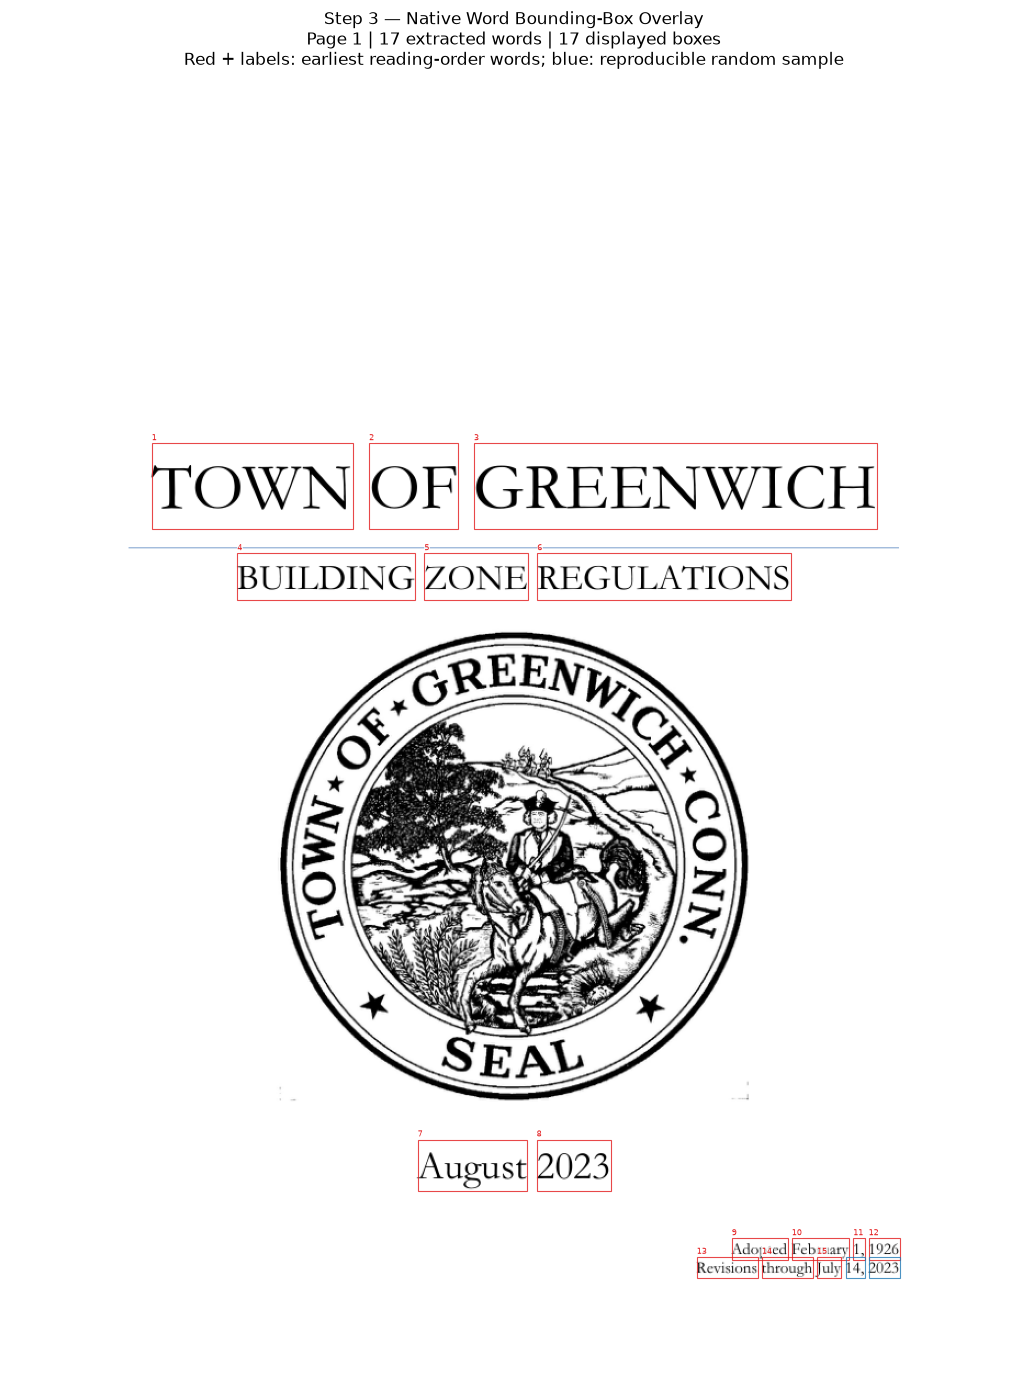

Saved page-1 token overlay: outputs/figures/step_03_native_word_bbox_overlay_page_001.png


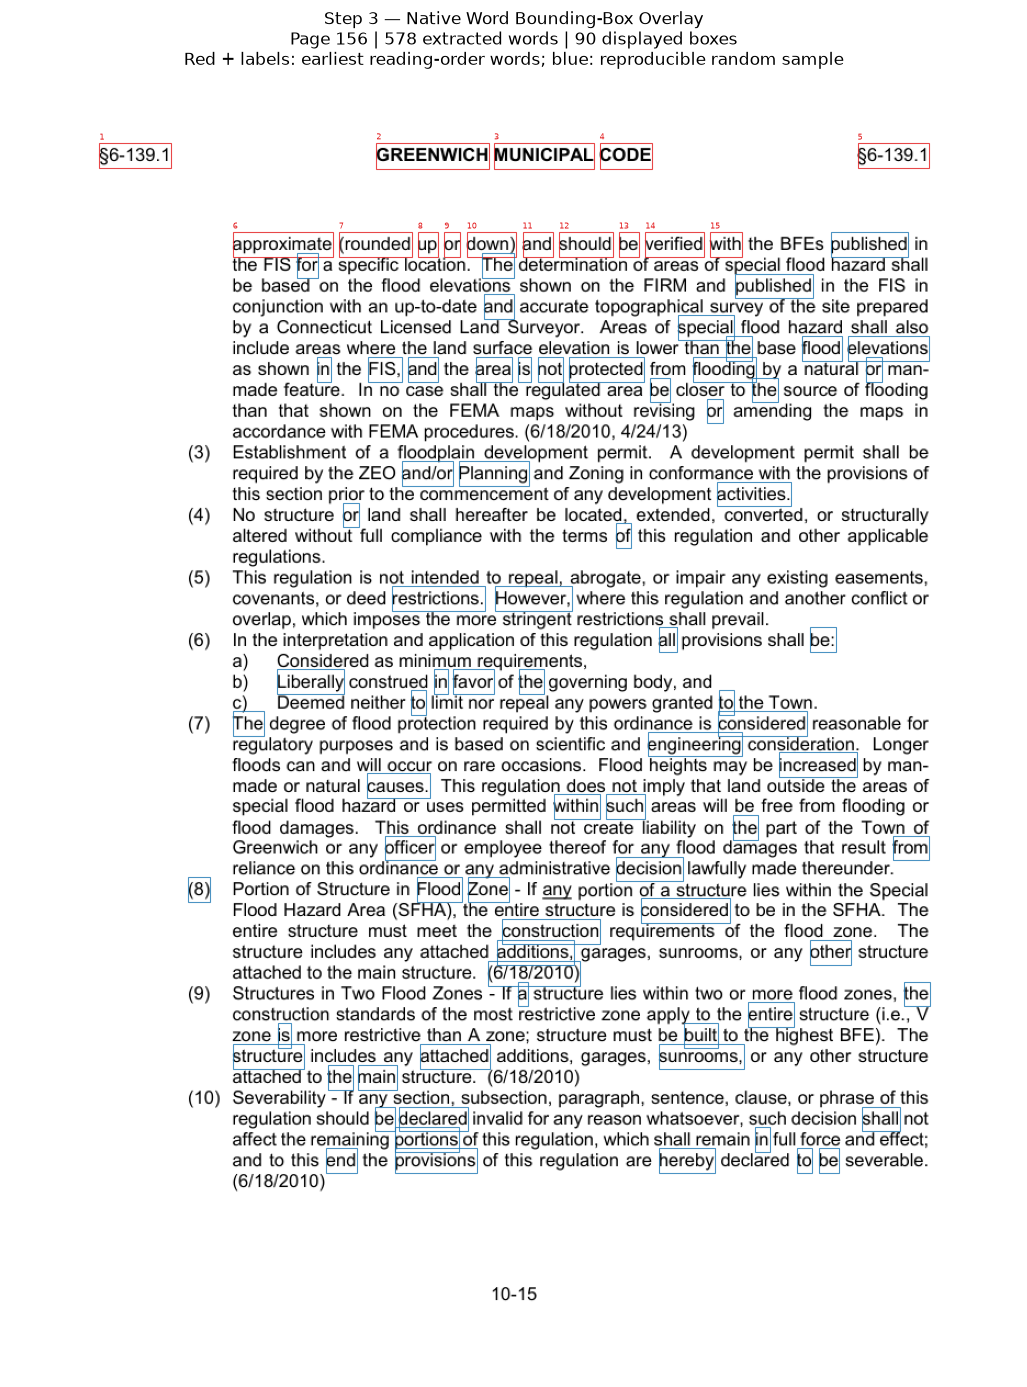

Saved page-156 token overlay: outputs/figures/step_03_native_word_bbox_overlay_page_156.png


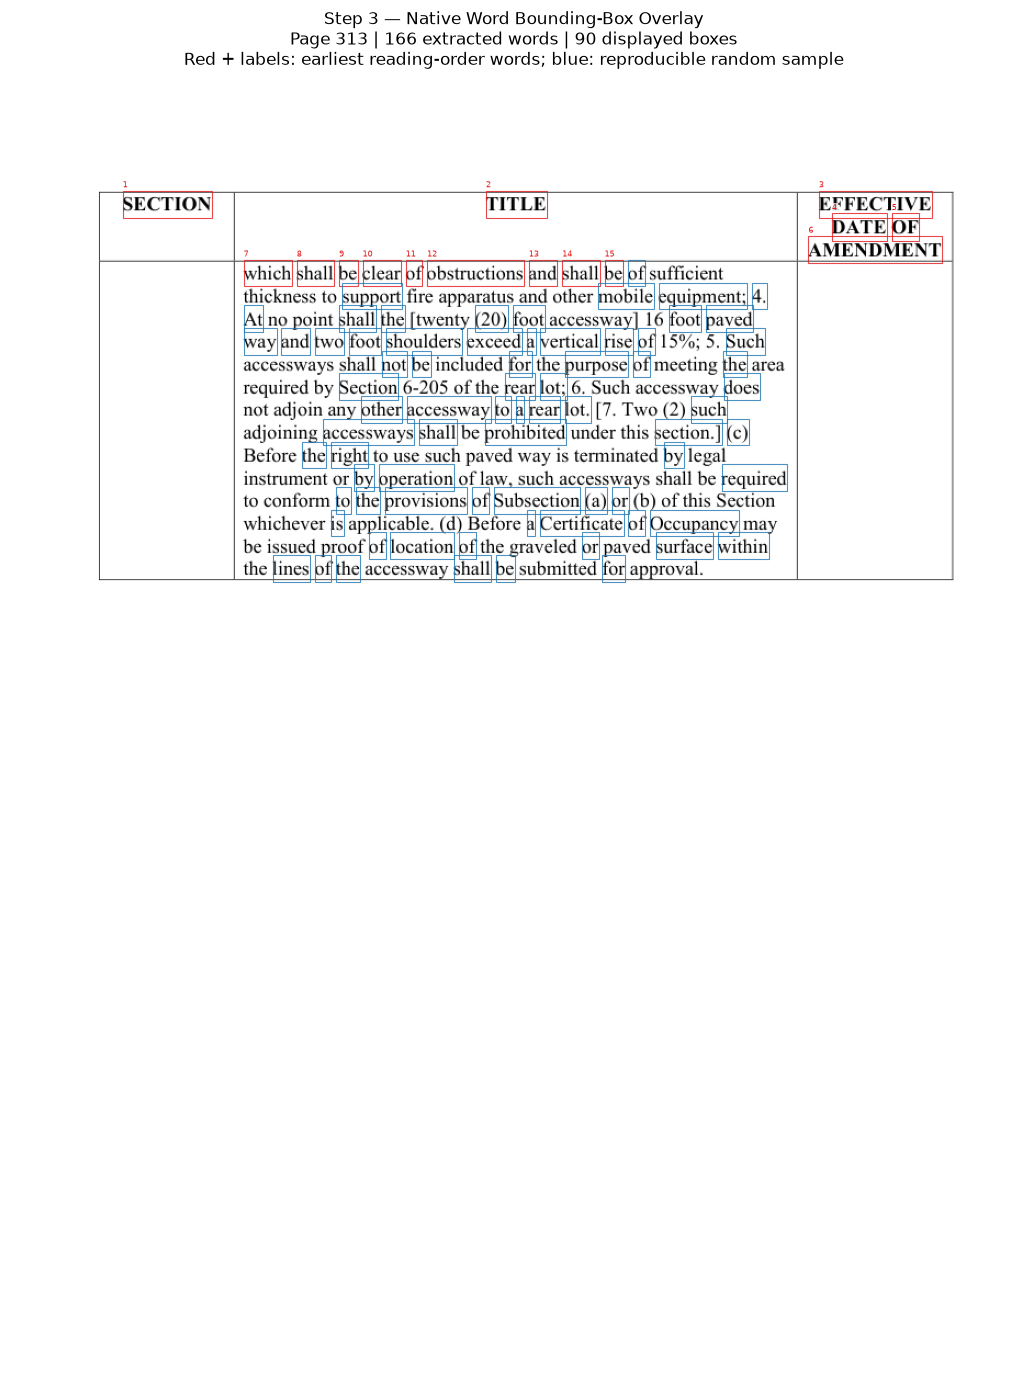

Saved page-313 token overlay: outputs/figures/step_03_native_word_bbox_overlay_page_313.png


In [23]:
overlay_page_numbers = sorted(
    set(
        [
            1,
            max(1, PDF_PAGE_COUNT // 2),
            PDF_PAGE_COUNT,
        ]
    )
)

overlay_paths = []

for page_number in overlay_page_numbers:
    page_word_count = int(
        native_page_summary_df.loc[
            native_page_summary_df["page_number"] == page_number,
            "native_word_count",
        ].iloc[0]
    )

    if page_word_count == 0:
        print(
            f"Skipping page {page_number}: no native word tokens were extracted."
        )
        continue

    fig, ax = plot_token_overlay(
        pdf_path=PDF_PATH,
        tokens_df=word_tokens_df,
        page_number=page_number,
        sample_size=90,
        zoom=1.5,
        seed=42,
    )

    overlay_path = (
        FIGURES_DIR / f"step_03_native_word_bbox_overlay_page_{page_number:03d}.png"
    )

    fig.savefig(overlay_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    overlay_paths.append(overlay_path)

    print(
        f"Saved page-{page_number} token overlay: "
        f"{overlay_path.relative_to(STAGE_A_ROOT)}"
    )

### Extraction diagnostics and source artifacts

The final cells for this step summarize the native extraction and save the raw layout-aware datasets

These files are intermediate evidence, not final cleaned zoning-code records:

- The word-token dataset is the starting point for page-quality scoring and later normalized-text construction
- The span dataset is the starting point for typography-aware heading detection
- The page summary is the input to the next step's page-level quality score
- The text samples and visual overlays are inspection artifacts for validating extraction quality

The raw source PDF remains untouched

In [24]:
native_extraction_diagnostics_df = pd.DataFrame(
    [
        {
            "document_id": DOCUMENT_ID,
            "pdf_page_count": PDF_PAGE_COUNT,
            "pages_processed": len(native_page_summary_df),
            "total_native_word_tokens": len(word_tokens_df),
            "total_native_text_spans": len(text_spans_df),
            "median_words_per_page": round(
                native_page_summary_df["native_word_count"].median(),
                2,
            ),
            "mean_words_per_page": round(
                native_page_summary_df["native_word_count"].mean(),
                2,
            ),
            "minimum_words_on_a_page": int(
                native_page_summary_df["native_word_count"].min()
            ),
            "maximum_words_on_a_page": int(
                native_page_summary_df["native_word_count"].max()
            ),
            "pages_with_zero_native_words": int(
                (native_page_summary_df["native_word_count"] == 0).sum()
            ),
            "pages_with_under_20_native_words": int(
                (native_page_summary_df["native_word_count"] < 20).sum()
            ),
            "unique_font_names": int(text_spans_df["font_name"].nunique()),
            "font_size_min": round(text_spans_df["font_size"].min(), 2),
            "font_size_median": round(text_spans_df["font_size"].median(), 2),
            "font_size_max": round(text_spans_df["font_size"].max(), 2),
            "extraction_engine": "pymupdf_native",
            "next_step": "page_quality_scoring_and_routing",
        }
    ]
)

native_extraction_diagnostics_df.T.rename(columns={0: "value"})

,value
document_id,greenwich-connecticut-18417c5e9074d765
pdf_page_count,313
pages_processed,313
total_native_word_tokens,125276
total_native_text_spans,17550
median_words_per_page,444.0
mean_words_per_page,400.24
minimum_words_on_a_page,2
maximum_words_on_a_page,740
pages_with_zero_native_words,0


In [25]:
word_tokens_path = (
    INTERIM_DIR / NATIVE_EXTRACTION_CONFIG["output_word_tokens_filename"]
)
text_spans_path = (
    INTERIM_DIR / NATIVE_EXTRACTION_CONFIG["output_text_spans_filename"]
)
page_summary_path = (
    TABLES_DIR / NATIVE_EXTRACTION_CONFIG["output_page_summary_filename"]
)
diagnostics_path = TABLES_DIR / "step_03_native_extraction_diagnostics.csv"
text_samples_path = TABLES_DIR / "step_03_native_text_samples.csv"

word_tokens_df.to_parquet(word_tokens_path, index=False)
text_spans_df.to_parquet(text_spans_path, index=False)
native_page_summary_df.to_csv(page_summary_path, index=False)
native_extraction_diagnostics_df.to_csv(diagnostics_path, index=False)
native_text_samples_df.to_csv(text_samples_path, index=False)

step_3_log = {
    "document_id": DOCUMENT_ID,
    "pdf_path_relative_to_stage_a": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    "native_extraction_config": NATIVE_EXTRACTION_CONFIG,
    "word_token_count": len(word_tokens_df),
    "text_span_count": len(text_spans_df),
    "page_count": PDF_PAGE_COUNT,
    "words_per_page_figure": str(
        words_per_page_figure_path.relative_to(STAGE_A_ROOT)
    ),
    "bbox_overlay_figures": [
        str(path.relative_to(STAGE_A_ROOT)) for path in overlay_paths
    ],
}

step_3_log_path = LOGS_DIR / "step_03_native_extraction_log.json"

with step_3_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(step_3_log, file_handle, indent=2, ensure_ascii=False)

print(
    f"Saved native word tokens: {word_tokens_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved native text spans: {text_spans_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved page summary: {page_summary_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved extraction diagnostics: "
    f"{diagnostics_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved text samples: {text_samples_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved extraction log: {step_3_log_path.relative_to(STAGE_A_ROOT)}"
)

Saved native word tokens: data/interim/step_03_native_word_tokens.parquet
Saved native text spans: data/interim/step_03_native_text_spans.parquet
Saved page summary: outputs/tables/step_03_native_page_summary.csv
Saved extraction diagnostics: outputs/tables/step_03_native_extraction_diagnostics.csv
Saved text samples: outputs/tables/step_03_native_text_samples.csv
Saved extraction log: outputs/logs/step_03_native_extraction_log.json


## Step 4 — Page-quality scoring and tri-tier routing

### Objective

Calculate a preliminary native-extraction quality score for every PDF page and route each page to one of three collection paths:

$$\text{route}(p) = \begin{cases} \text{Native Extraction}, & Q_p \geq \tau_H \\ \text{OCR \& Dual-Stream Reconciliation}, & \tau_L \leq Q_p < \tau_H \\ \text{Manual Review Queue}, & Q_p < \tau_L \end{cases}$$

where:

$$Q_p = w_1Q_{p,\text{text coverage}} + w_2Q_{p,\text{character quality}} + w_3Q_{p,\text{reading order}} + w_4Q_{p,\text{table integrity}}$$

### First-test interpretation

The component scores in this step are layout and text-health proxies. They help prioritize further processing; they do not establish that the legal content on a page is substantively correct

A page with a high score is suitable for continued native-stream processing, subject to later hierarchy, table, and legal-scope validation

A page with a low score is not discarded. It is retained with a route, diagnostic reasons, and review status

### Metric definitions for this implementation

#### 1. Text coverage score

This proxy combines:

- native word count relative to the document distribution;
- native extracted-character count relative to the document distribution; and
- word bounding-box area as a proportion of page area.

A page with unusually little extractable text or nearly zero text-box coverage receives a lower score.

#### 2. Character quality score

This measures the share of extracted characters that are:

- letters;
- digits;
- whitespace; or
- expected legal-document punctuation.

It also penalizes replacement characters, control characters, and visibly suspicious symbol patterns.

#### 3. Reading-order score

This measures whether the sequential word order returned by PyMuPDF is broadly consistent with page coordinates

It evaluates:

- vertical inversions between consecutive extracted words
- excessive backward horizontal jumps on the same visual line
- line-level coordinate monotonicity

This remains a heuristic because complex columns, tables, headers, footers, and side notes can legitimately cause coordinate jumps

#### 4. Table-integrity score

This is a conservative structural proxy. It detects pages that have table-like row alignment, then evaluates whether those detected rows preserve multiple aligned text positions

A low table-integrity score should be interpreted as a reason for review or OCR/table-specific handling, not proof that a table is legally incorrect

In [26]:
PAGE_QUALITY_SCORING_CONFIG = {
    "weights": QUALITY_CONFIG["weights"].copy(),
    "thresholds": QUALITY_CONFIG["thresholds"].copy(),
    "text_coverage": {
        "word_count_weight": 0.45,
        "character_count_weight": 0.35,
        "bbox_area_weight": 0.20,
        "low_word_count_absolute_threshold": 20,
        "low_character_count_absolute_threshold": 100,
    },
    "character_quality": {
        "expected_punctuation": set(
            ".,;:!?()[]{}<>§¶&/\\-–—_'\"%$#@+=*|`~"
        ),
        "replacement_characters": {"�"},
        "suspicious_symbol_pattern": r"[^\w\s.,;:!?(){}\[\]<>§¶&/\\\-–—_'\"%$#@+=*|`~]{3,}",
    },
    "reading_order": {
        "same_line_y_tolerance_points": 4.0,
        "large_horizontal_backtrack_points": 36.0,
        "large_vertical_backtrack_points": 12.0,
        "minimum_word_count_for_score": 8,
    },
    "table_integrity": {
        "row_y_tolerance_points": 3.0,
        "minimum_words_in_candidate_row": 3,
        "minimum_candidate_rows_for_table_page": 3,
        "minimum_distinct_x_positions": 3,
        "expected_alignment_ratio": 0.60,
    },
    "routing_labels": {
        "native": "native_extraction",
        "ocr_reconcile": "ocr_and_dual_stream_reconciliation",
        "manual_review": "manual_review_queue",
    },
    "output_filename": "step_04_page_quality_scores.csv",
}

assert abs(
    sum(PAGE_QUALITY_SCORING_CONFIG["weights"].values()) - 1.0
) < 1e-9, "Page-quality weights must sum to 1.0."

PAGE_QUALITY_SCORING_CONFIG

{'weights': {'text_coverage': 0.35,
  'character_quality': 0.25,
  'reading_order': 0.2,
  'table_integrity': 0.2},
 'thresholds': {'high_quality_native_threshold': 0.85,
  'manual_review_threshold': 0.5},
 'text_coverage': {'word_count_weight': 0.45,
  'character_count_weight': 0.35,
  'bbox_area_weight': 0.2,
  'low_word_count_absolute_threshold': 20,
  'low_character_count_absolute_threshold': 100},
 'character_quality': {'expected_punctuation': {'!',
   '"',
   '#',
   '$',
   '%',
   '&',
   "'",
   '(',
   ')',
   '*',
   '+',
   ',',
   '-',
   '.',
   '/',
   ':',
   ';',
   '<',
   '=',
   '>',
   '?',
   '@',
   '[',
   '\\',
   ']',
   '_',
   '`',
   '{',
   '|',
   '}',
   '~',
   '§',
   '¶',
   '–',
   '—'},
  'replacement_characters': {'�'},
  'suspicious_symbol_pattern': '[^\\w\\s.,;:!?(){}\\[\\]<>§¶&/\\\\\\-–—_\'\\"%$#@+=*|`~]{3,}'},
 'reading_order': {'same_line_y_tolerance_points': 4.0,
  'large_horizontal_backtrack_points': 36.0,
  'large_vertical_backtrack_points'

In [27]:
def clipped_min_max(series: pd.Series) -> pd.Series:
    """
    Scale a numeric series to [0, 1] using min-max scaling.

    If all non-null values are identical, return 1.0 for non-null entries:
    there is no relative evidence that any one page is worse than another.
    """
    numeric_series = pd.to_numeric(series, errors="coerce")
    valid_values = numeric_series.dropna()

    if valid_values.empty:
        return pd.Series(0.0, index=series.index)

    minimum = valid_values.min()
    maximum = valid_values.max()

    if maximum == minimum:
        return numeric_series.notna().astype(float)

    scaled = (numeric_series - minimum) / (maximum - minimum)
    return scaled.clip(lower=0.0, upper=1.0).fillna(0.0)


def percentile_score(series: pd.Series) -> pd.Series:
    """
    Convert a metric to its percentile rank within the document.

    Percentile ranking is robust for first-pass diagnostics because municipal
    zoning PDFs may have diverse page types: cover, prose, tables, maps, and
    appendices.
    """
    numeric_series = pd.to_numeric(series, errors="coerce")

    if numeric_series.notna().sum() <= 1:
        return numeric_series.notna().astype(float)

    return numeric_series.rank(
        pct=True,
        method="average",
    ).fillna(0.0)


def join_nonempty_reasons(reasons: list[str]) -> str:
    """Return readable diagnostic reasons, or an explicit no-issue label."""
    filtered_reasons = [reason for reason in reasons if reason]

    if not filtered_reasons:
        return "no_major_native_extraction_issue_detected"

    return " | ".join(filtered_reasons)

In [28]:
def calculate_text_coverage_scores(
    page_summary_df: pd.DataFrame,
    word_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Calculate page-level native text coverage using word counts, character
    counts, and aggregate word-bounding-box area relative to page area.
    """
    page_area_df = (
        word_df.groupby("page_number", as_index=False)
        .agg(
            word_bbox_area=(
                "bbox_width",
                lambda widths: 0.0,
            )
        )
    )

    word_area_df = word_df.copy()
    word_area_df["bbox_area"] = (
        word_area_df["bbox_width"] * word_area_df["bbox_height"]
    )

    word_area_df = (
        word_area_df.groupby("page_number", as_index=False)
        .agg(
            aggregate_word_bbox_area=("bbox_area", "sum"),
            page_width=("page_width", "first"),
            page_height=("page_height", "first"),
        )
    )

    coverage_df = page_summary_df[
        [
            "document_id",
            "page_number",
            "native_word_count",
            "native_text_character_count",
            "page_width",
            "page_height",
        ]
    ].copy()

    coverage_df = coverage_df.merge(
        word_area_df[
            [
                "page_number",
                "aggregate_word_bbox_area",
            ]
        ],
        on="page_number",
        how="left",
    )

    coverage_df["aggregate_word_bbox_area"] = coverage_df[
        "aggregate_word_bbox_area"
    ].fillna(0.0)

    coverage_df["page_area"] = (
        coverage_df["page_width"] * coverage_df["page_height"]
    )

    coverage_df["word_bbox_area_ratio"] = (
        coverage_df["aggregate_word_bbox_area"]
        / coverage_df["page_area"].replace(0, np.nan)
    ).fillna(0.0)

    coverage_df["word_count_percentile"] = percentile_score(
        coverage_df["native_word_count"]
    )

    coverage_df["character_count_percentile"] = percentile_score(
        coverage_df["native_text_character_count"]
    )

    coverage_df["bbox_area_percentile"] = percentile_score(
        coverage_df["word_bbox_area_ratio"]
    )

    weights = config["text_coverage"]

    coverage_df["text_coverage_score"] = (
        weights["word_count_weight"] * coverage_df["word_count_percentile"]
        + weights["character_count_weight"]
        * coverage_df["character_count_percentile"]
        + weights["bbox_area_weight"] * coverage_df["bbox_area_percentile"]
    ).clip(lower=0.0, upper=1.0)

    return coverage_df[
        [
            "document_id",
            "page_number",
            "native_word_count",
            "native_text_character_count",
            "word_bbox_area_ratio",
            "word_count_percentile",
            "character_count_percentile",
            "bbox_area_percentile",
            "text_coverage_score",
        ]
    ]

In [29]:
def calculate_character_quality_scores(
    page_summary_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Score native text cleanliness by rewarding expected legal-document
    characters and penalizing replacement/control/suspicious patterns.
    """
    expected_punctuation = config["character_quality"]["expected_punctuation"]
    replacement_characters = config["character_quality"]["replacement_characters"]
    suspicious_pattern = re.compile(
        config["character_quality"]["suspicious_symbol_pattern"]
    )

    character_quality_records = []

    for _, page_row in page_summary_df.iterrows():
        page_text = page_row["native_text_preview"]

        # Re-extracting full page text is avoided here because the first Step 3
        # implementation stores only a preview in the page summary. Rebuild
        # page text from all native tokens in a later cell.
        character_quality_records.append(
            {
                "document_id": page_row["document_id"],
                "page_number": page_row["page_number"],
                "character_quality_score": np.nan,
                "valid_character_ratio": np.nan,
                "replacement_character_count": np.nan,
                "control_character_count": np.nan,
                "suspicious_pattern_count": np.nan,
            }
        )

    return pd.DataFrame(character_quality_records)


def calculate_character_quality_from_tokens(
    word_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Reconstruct page text from native word tokens and calculate character
    quality. This uses all extracted tokens rather than the 500-character
    preview stored in the page summary.
    """
    expected_punctuation = config["character_quality"]["expected_punctuation"]
    replacement_characters = config["character_quality"]["replacement_characters"]
    suspicious_pattern = re.compile(
        config["character_quality"]["suspicious_symbol_pattern"]
    )

    page_text_df = (
        word_df.sort_values(
            ["page_number", "native_word_sequence_on_page"]
        )
        .groupby("page_number", as_index=False)
        .agg(
            reconstructed_native_text=(
                "text",
                lambda values: " ".join(values.astype(str)),
            ),
        )
    )

    records = []

    for _, row in page_text_df.iterrows():
        text = row["reconstructed_native_text"]
        total_characters = max(len(text), 1)

        valid_characters = sum(
            character.isalnum()
            or character.isspace()
            or character in expected_punctuation
            for character in text
        )

        replacement_count = sum(
            character in replacement_characters
            for character in text
        )

        control_count = sum(
            ord(character) < 32 and not character.isspace()
            for character in text
        )

        suspicious_pattern_count = len(suspicious_pattern.findall(text))

        valid_character_ratio = valid_characters / total_characters

        penalty = min(
            0.75,
            (
                0.35 * replacement_count / total_characters
                + 0.25 * control_count / total_characters
                + 0.40 * suspicious_pattern_count
                / max(total_characters / 100, 1)
            ),
        )

        character_quality_score = max(
            0.0,
            min(1.0, valid_character_ratio - penalty),
        )

        records.append(
            {
                "page_number": int(row["page_number"]),
                "reconstructed_native_text_character_count": len(text),
                "valid_character_ratio": valid_character_ratio,
                "replacement_character_count": replacement_count,
                "control_character_count": control_count,
                "suspicious_pattern_count": suspicious_pattern_count,
                "character_quality_score": character_quality_score,
            }
        )

    return pd.DataFrame(records)

In [30]:
def calculate_reading_order_scores(
    word_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Score whether PyMuPDF's extracted word sequence broadly agrees with
    physical coordinates.

    The score penalizes:
    - large upward jumps in y-coordinate;
    - large leftward jumps on approximately the same visual line; and
    - inconsistent line progression.

    It is intentionally conservative: complex tables or multi-column layouts
    may receive a lower score and be examined later rather than silently trusted.
    """
    tolerance_y = config["reading_order"]["same_line_y_tolerance_points"]
    horizontal_backtrack = config["reading_order"][
        "large_horizontal_backtrack_points"
    ]
    vertical_backtrack = config["reading_order"][
        "large_vertical_backtrack_points"
    ]
    minimum_words = config["reading_order"]["minimum_word_count_for_score"]

    records = []

    for page_number, page_words in word_df.groupby("page_number"):
        page_words = page_words.sort_values(
            "native_word_sequence_on_page"
        ).reset_index(drop=True)

        word_count = len(page_words)

        if word_count < minimum_words:
            records.append(
                {
                    "page_number": int(page_number),
                    "reading_order_score": 0.50,
                    "word_transition_count": max(word_count - 1, 0),
                    "vertical_backtrack_count": 0,
                    "same_line_horizontal_backtrack_count": 0,
                    "reading_order_note": "insufficient_words_for_stable_reading_order_score",
                }
            )
            continue

        y0 = page_words["bbox_y0"].to_numpy()
        x0 = page_words["bbox_x0"].to_numpy()

        delta_y = np.diff(y0)
        delta_x = np.diff(x0)

        same_visual_line = np.abs(delta_y) <= tolerance_y

        vertical_backtracks = delta_y < -vertical_backtrack
        horizontal_backtracks = (
            same_visual_line & (delta_x < -horizontal_backtrack)
        )

        transition_count = len(delta_y)

        vertical_backtrack_rate = (
            vertical_backtracks.sum() / transition_count
            if transition_count
            else 0.0
        )

        horizontal_backtrack_rate = (
            horizontal_backtracks.sum() / transition_count
            if transition_count
            else 0.0
        )

        penalty = min(
            1.0,
            0.65 * vertical_backtrack_rate
            + 0.35 * horizontal_backtrack_rate,
        )

        reading_order_score = 1.0 - penalty

        records.append(
            {
                "page_number": int(page_number),
                "reading_order_score": reading_order_score,
                "word_transition_count": transition_count,
                "vertical_backtrack_count": int(vertical_backtracks.sum()),
                "same_line_horizontal_backtrack_count": int(
                    horizontal_backtracks.sum()
                ),
                "reading_order_note": "coordinate_consistency_proxy",
            }
        )

    return pd.DataFrame(records)

In [31]:
def calculate_table_integrity_scores(
    word_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Estimate structural table integrity from native word geometry.

    The heuristic groups words into approximate visual rows based on y-position.
    It treats pages with repeated multi-word, multi-column aligned rows as
    table-like. For those pages, alignment consistency is scored based on how
    often row x-positions align with the page's dominant x-position clusters.

    Pages without table-like patterns receive 1.0 because table integrity is
    not applicable rather than inherently poor.
    """
    y_tolerance = config["table_integrity"]["row_y_tolerance_points"]
    minimum_words_in_row = config["table_integrity"][
        "minimum_words_in_candidate_row"
    ]
    minimum_candidate_rows = config["table_integrity"][
        "minimum_candidate_rows_for_table_page"
    ]
    minimum_distinct_x = config["table_integrity"][
        "minimum_distinct_x_positions"
    ]
    expected_alignment_ratio = config["table_integrity"][
        "expected_alignment_ratio"
    ]

    records = []

    for page_number, page_words in word_df.groupby("page_number"):
        words = page_words.sort_values(
            ["bbox_y0", "bbox_x0"]
        ).reset_index(drop=True)

        if words.empty:
            records.append(
                {
                    "page_number": int(page_number),
                    "table_like_page": False,
                    "candidate_table_row_count": 0,
                    "dominant_x_cluster_count": 0,
                    "mean_row_alignment_ratio": 0.0,
                    "table_integrity_score": 0.0,
                    "table_integrity_note": "no_native_words_detected",
                }
            )
            continue

        row_assignments = []
        current_row_id = 0
        current_row_y = None

        for _, word in words.iterrows():
            word_y = float(word["bbox_y0"])

            if current_row_y is None:
                current_row_y = word_y
            elif abs(word_y - current_row_y) > y_tolerance:
                current_row_id += 1
                current_row_y = word_y

            row_assignments.append(current_row_id)

        words = words.assign(approx_row_id=row_assignments)

        row_summary = (
            words.groupby("approx_row_id", as_index=False)
            .agg(
                word_count=("text", "size"),
                min_x=("bbox_x0", "min"),
                max_x=("bbox_x0", "max"),
                distinct_x_positions=(
                    "bbox_x0",
                    lambda values: len(
                        np.unique(np.round(values.to_numpy(), 0))
                    ),
                ),
            )
        )

        candidate_rows = row_summary.loc[
            (
                row_summary["word_count"]
                >= minimum_words_in_row
            )
            & (
                row_summary["distinct_x_positions"]
                >= minimum_distinct_x
            )
        ].copy()

        is_table_like = len(candidate_rows) >= minimum_candidate_rows

        if not is_table_like:
            records.append(
                {
                    "page_number": int(page_number),
                    "table_like_page": False,
                    "candidate_table_row_count": int(len(candidate_rows)),
                    "dominant_x_cluster_count": 0,
                    "mean_row_alignment_ratio": 1.0,
                    "table_integrity_score": 1.0,
                    "table_integrity_note": "no_table_like_layout_detected_not_applicable",
                }
            )
            continue

        candidate_word_rows = words.merge(
            candidate_rows[["approx_row_id"]],
            on="approx_row_id",
            how="inner",
        )

        rounded_x_positions = np.round(
            candidate_word_rows["bbox_x0"].to_numpy(),
            0,
        )

        x_position_counts = (
            pd.Series(rounded_x_positions)
            .value_counts()
            .sort_values(ascending=False)
        )

        dominant_x_positions = x_position_counts.loc[
            x_position_counts >= max(2, len(candidate_rows) * 0.35)
        ].index.to_numpy()

        if len(dominant_x_positions) == 0:
            mean_alignment_ratio = 0.0
        else:
            row_alignment_scores = []

            for _, row in candidate_rows.iterrows():
                row_words = candidate_word_rows.loc[
                    candidate_word_rows["approx_row_id"]
                    == row["approx_row_id"]
                ]

                row_x_positions = np.round(
                    row_words["bbox_x0"].to_numpy(),
                    0,
                )

                aligned_words = sum(
                    np.any(
                        np.abs(dominant_x_positions - x_position)
                        <= y_tolerance
                    )
                    for x_position in row_x_positions
                )

                row_alignment_scores.append(
                    aligned_words / max(len(row_x_positions), 1)
                )

            mean_alignment_ratio = float(np.mean(row_alignment_scores))

        table_integrity_score = min(
            1.0,
            mean_alignment_ratio / expected_alignment_ratio,
        )

        records.append(
            {
                "page_number": int(page_number),
                "table_like_page": True,
                "candidate_table_row_count": int(len(candidate_rows)),
                "dominant_x_cluster_count": int(len(dominant_x_positions)),
                "mean_row_alignment_ratio": mean_alignment_ratio,
                "table_integrity_score": table_integrity_score,
                "table_integrity_note": "table_layout_alignment_proxy",
            }
        )

    return pd.DataFrame(records)

In [32]:
text_coverage_scores_df = calculate_text_coverage_scores(
    page_summary_df=native_page_summary_df,
    word_df=word_tokens_df,
    config=PAGE_QUALITY_SCORING_CONFIG,
)

character_quality_scores_df = calculate_character_quality_from_tokens(
    word_df=word_tokens_df,
    config=PAGE_QUALITY_SCORING_CONFIG,
)

reading_order_scores_df = calculate_reading_order_scores(
    word_df=word_tokens_df,
    config=PAGE_QUALITY_SCORING_CONFIG,
)

table_integrity_scores_df = calculate_table_integrity_scores(
    word_df=word_tokens_df,
    config=PAGE_QUALITY_SCORING_CONFIG,
)

component_score_preview_df = (
    text_coverage_scores_df[
        [
            "page_number",
            "text_coverage_score",
        ]
    ]
    .merge(
        character_quality_scores_df[
            [
                "page_number",
                "character_quality_score",
            ]
        ],
        on="page_number",
        how="left",
    )
    .merge(
        reading_order_scores_df[
            [
                "page_number",
                "reading_order_score",
            ]
        ],
        on="page_number",
        how="left",
    )
    .merge(
        table_integrity_scores_df[
            [
                "page_number",
                "table_integrity_score",
                "table_like_page",
            ]
        ],
        on="page_number",
        how="left",
    )
)

component_score_preview_df.head(20)

,page_number,text_coverage_score,character_quality_score,reading_order_score,table_integrity_score,table_like_page
0,1,0.079233,1.000000,1.0,0.187500,True
1,2,0.153994,1.000000,1.0,0.166667,True
2,3,0.022284,1.000000,0.5,1.000000,False
3,4,0.627636,0.989926,1.0,0.538012,True
4,5,0.678115,1.000000,1.0,0.713543,True
5,6,0.648562,0.988679,1.0,0.565099,True
6,7,0.667252,0.989309,1.0,0.616310,True
7,8,0.585623,1.000000,1.0,0.592144,True
8,9,0.651278,0.976500,1.0,0.637849,True
9,10,0.557029,0.891618,1.0,0.536713,True


In [75]:
page_quality_df = (
    native_page_summary_df[
        [
            "document_id",
            "page_number",
            "native_word_count",
            "native_span_count",
            "native_text_character_count",
            "native_text_preview",
        ]
    ]
    .merge(
        text_coverage_scores_df,
        on=["document_id", "page_number", "native_word_count", "native_text_character_count"],
        how="left",
    )
    .merge(
        character_quality_scores_df,
        on="page_number",
        how="left",
    )
    .merge(
        reading_order_scores_df,
        on="page_number",
        how="left",
    )
    .merge(
        table_integrity_scores_df,
        on="page_number",
        how="left",
    )
)

score_columns = [
    "text_coverage_score",
    "character_quality_score",
    "reading_order_score",
    "table_integrity_score",
]

page_quality_df[score_columns] = page_quality_df[score_columns].fillna(0.0)

quality_weights = PAGE_QUALITY_SCORING_CONFIG["weights"]

page_quality_df["composite_quality_score"] = (
    quality_weights["text_coverage"]
    * page_quality_df["text_coverage_score"]
    + quality_weights["character_quality"]
    * page_quality_df["character_quality_score"]
    + quality_weights["reading_order"]
    * page_quality_df["reading_order_score"]
    + quality_weights["table_integrity"]
    * page_quality_df["table_integrity_score"]
).clip(lower=0.0, upper=1.0)

high_threshold = PAGE_QUALITY_SCORING_CONFIG["thresholds"][
    "high_quality_native_threshold"
]
low_threshold = PAGE_QUALITY_SCORING_CONFIG["thresholds"][
    "manual_review_threshold"
]

routing_labels = PAGE_QUALITY_SCORING_CONFIG["routing_labels"]

page_quality_df["route"] = np.select(
    [
        page_quality_df["composite_quality_score"] >= high_threshold,
        page_quality_df["composite_quality_score"] >= low_threshold,
    ],
    [
        routing_labels["native"],
        routing_labels["ocr_reconcile"],
    ],
    default=routing_labels["manual_review"],
)

def page_diagnostic_reasons(row: pd.Series) -> str:
    reasons = []

    if (
        row["native_word_count"]
        < PAGE_QUALITY_SCORING_CONFIG["text_coverage"][
            "low_word_count_absolute_threshold"
        ]
    ):
        reasons.append(
            f"low_native_word_count={int(row['native_word_count'])}"
        )

    if (
        row["native_text_character_count"]
        < PAGE_QUALITY_SCORING_CONFIG["text_coverage"][
            "low_character_count_absolute_threshold"
        ]
    ):
        reasons.append(
            "low_native_character_count="
            f"{int(row['native_text_character_count'])}"
        )

    if row["text_coverage_score"] < 0.50:
        reasons.append(
            f"low_text_coverage={row['text_coverage_score']:.2f}"
        )

    if row["character_quality_score"] < 0.90:
        reasons.append(
            f"reduced_character_quality={row['character_quality_score']:.2f}"
        )

    if row["reading_order_score"] < 0.85:
        reasons.append(
            f"reading_order_anomaly={row['reading_order_score']:.2f}"
        )

    if (
        bool(row["table_like_page"])
        and row["table_integrity_score"] < 0.85
    ):
        reasons.append(
            f"table_alignment_risk={row['table_integrity_score']:.2f}"
        )

    if row["route"] == routing_labels["ocr_reconcile"]:
        reasons.append("intermediate_composite_score_requires_ocr_comparison")

    if row["route"] == routing_labels["manual_review"]:
        reasons.append("low_composite_score_requires_manual_review")

    return join_nonempty_reasons(reasons)


page_quality_df["diagnostic_reasons"] = page_quality_df.apply(
    page_diagnostic_reasons,
    axis=1,
)

page_quality_df["quality_review_status"] = np.where(
    page_quality_df["route"] == routing_labels["native"],
    "native_route_pending_spot_check",
    np.where(
        page_quality_df["route"] == routing_labels["ocr_reconcile"],
        "ocr_reconciliation_required",
        "manual_review_required",
    ),
)

page_quality_df = page_quality_df.sort_values(
    "page_number"
).reset_index(drop=True)

assert len(page_quality_df) == PDF_PAGE_COUNT, (
    "The quality table must contain one row per PDF page."
)

assert page_quality_df["composite_quality_score"].between(0, 1).all(), (
    "Composite quality scores must remain in [0, 1]."
)

page_quality_df[
    [
        "page_number",
        "native_word_count",
        "text_coverage_score",
        "character_quality_score",
        "reading_order_score",
        "table_integrity_score",
        "composite_quality_score",
        "route",
        "diagnostic_reasons",
    ]
].head(20)

,page_number,native_word_count,text_coverage_score,character_quality_score,reading_order_score,table_integrity_score,composite_quality_score,route,diagnostic_reasons
0,1,17,0.079233,1.000000,1.0,0.187500,0.515232,ocr_and_dual_stream_reconciliation,low_native_word_count=17 | low_text_coverage=0...
1,2,117,0.153994,1.000000,1.0,0.166667,0.537231,ocr_and_dual_stream_reconciliation,low_text_coverage=0.15 | table_alignment_risk=...
2,3,3,0.022284,1.000000,0.5,1.000000,0.557800,ocr_and_dual_stream_reconciliation,low_native_word_count=3 | low_native_character...
3,4,279,0.627636,0.989926,1.0,0.538012,0.774757,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.54 | intermediate_compo...
4,5,320,0.678115,1.000000,1.0,0.713543,0.830049,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.71 | intermediate_compo...
5,6,320,0.648562,0.988679,1.0,0.565099,0.787187,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.57 | intermediate_compo...
6,7,322,0.667252,0.989309,1.0,0.616310,0.804128,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.62 | intermediate_compo...
7,8,265,0.585623,1.000000,1.0,0.592144,0.773397,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.59 | intermediate_compo...
8,9,276,0.651278,0.976500,1.0,0.637849,0.799642,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.64 | intermediate_compo...
9,10,300,0.557029,0.891618,1.0,0.536713,0.725207,ocr_and_dual_stream_reconciliation,reduced_character_quality=0.89 | table_alignme...


In [76]:
quality_display_columns = [
    "page_number",
    "native_word_count",
    "native_text_character_count",
    "text_coverage_score",
    "character_quality_score",
    "reading_order_score",
    "table_like_page",
    "table_integrity_score",
    "composite_quality_score",
    "route",
    "quality_review_status",
    "diagnostic_reasons",
]

page_quality_df[quality_display_columns].style.format(
    {
        "text_coverage_score": "{:.3f}",
        "character_quality_score": "{:.3f}",
        "reading_order_score": "{:.3f}",
        "table_integrity_score": "{:.3f}",
        "composite_quality_score": "{:.3f}",
    }
)

,page_number,native_word_count,native_text_character_count,text_coverage_score,character_quality_score,reading_order_score,table_like_page,table_integrity_score,composite_quality_score,route,quality_review_status,diagnostic_reasons
0,1,17,112,0.079,1.000,1.000,True,0.188,0.515,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,low_native_word_count=17 | low_text_coverage=0.08 | table_alignment_risk=0.19 | intermediate_composite_score_requires_ocr_comparison
1,2,117,879,0.154,1.000,1.000,True,0.167,0.537,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,low_text_coverage=0.15 | table_alignment_risk=0.17 | intermediate_composite_score_requires_ocr_comparison
2,3,3,17,0.022,1.000,0.500,False,1.000,0.558,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,low_native_word_count=3 | low_native_character_count=17 | low_text_coverage=0.02 | reading_order_anomaly=0.50 | intermediate_composite_score_requires_ocr_comparison
3,4,279,4466,0.628,0.990,1.000,True,0.538,0.775,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,table_alignment_risk=0.54 | intermediate_composite_score_requires_ocr_comparison
4,5,320,5431,0.678,1.000,1.000,True,0.714,0.830,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,table_alignment_risk=0.71 | intermediate_composite_score_requires_ocr_comparison
5,6,320,4505,0.649,0.989,1.000,True,0.565,0.787,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,table_alignment_risk=0.57 | intermediate_composite_score_requires_ocr_comparison
6,7,322,4677,0.667,0.989,1.000,True,0.616,0.804,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,table_alignment_risk=0.62 | intermediate_composite_score_requires_ocr_comparison
7,8,265,4100,0.586,1.000,1.000,True,0.592,0.773,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,table_alignment_risk=0.59 | intermediate_composite_score_requires_ocr_comparison
8,9,276,4766,0.651,0.977,1.000,True,0.638,0.800,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,table_alignment_risk=0.64 | intermediate_composite_score_requires_ocr_comparison
9,10,300,3746,0.557,0.892,1.000,True,0.537,0.725,ocr_and_dual_stream_reconciliation,ocr_reconciliation_required,reduced_character_quality=0.89 | table_alignment_risk=0.54 | intermediate_composite_score_requires_ocr_comparison


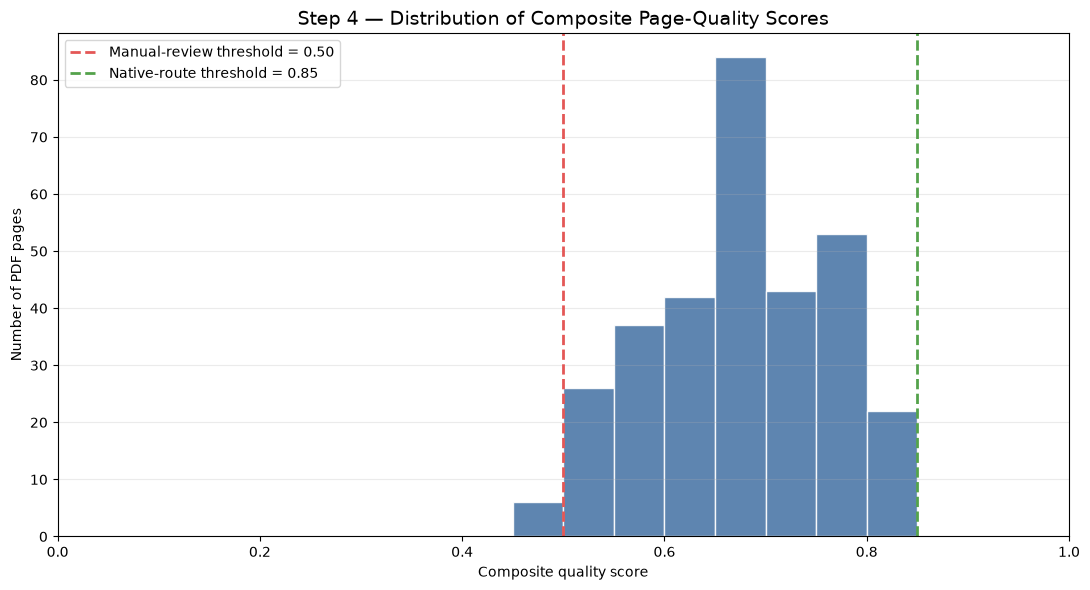

Saved quality-score distribution histogram: outputs/figures/step_04_quality_score_distribution.png


In [63]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    page_quality_df["composite_quality_score"],
    bins=np.linspace(0, 1, 21),
    color="#4C78A8",
    edgecolor="white",
    alpha=0.9,
)

ax.axvline(
    low_threshold,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Manual-review threshold = {low_threshold:.2f}",
)

ax.axvline(
    high_threshold,
    color="#54A24B",
    linestyle="--",
    linewidth=2,
    label=f"Native-route threshold = {high_threshold:.2f}",
)

ax.set_title("Step 4 — Distribution of Composite Page-Quality Scores", fontsize=14)
ax.set_xlabel("Composite quality score")
ax.set_ylabel("Number of PDF pages")
ax.set_xlim(0, 1)
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

quality_histogram_path = FIGURES_DIR / "step_04_quality_score_distribution.png"
fig.savefig(quality_histogram_path, dpi=220, bbox_inches="tight")
plt.show()

print(
    "Saved quality-score distribution histogram: "
    f"{quality_histogram_path.relative_to(STAGE_A_ROOT)}"
)

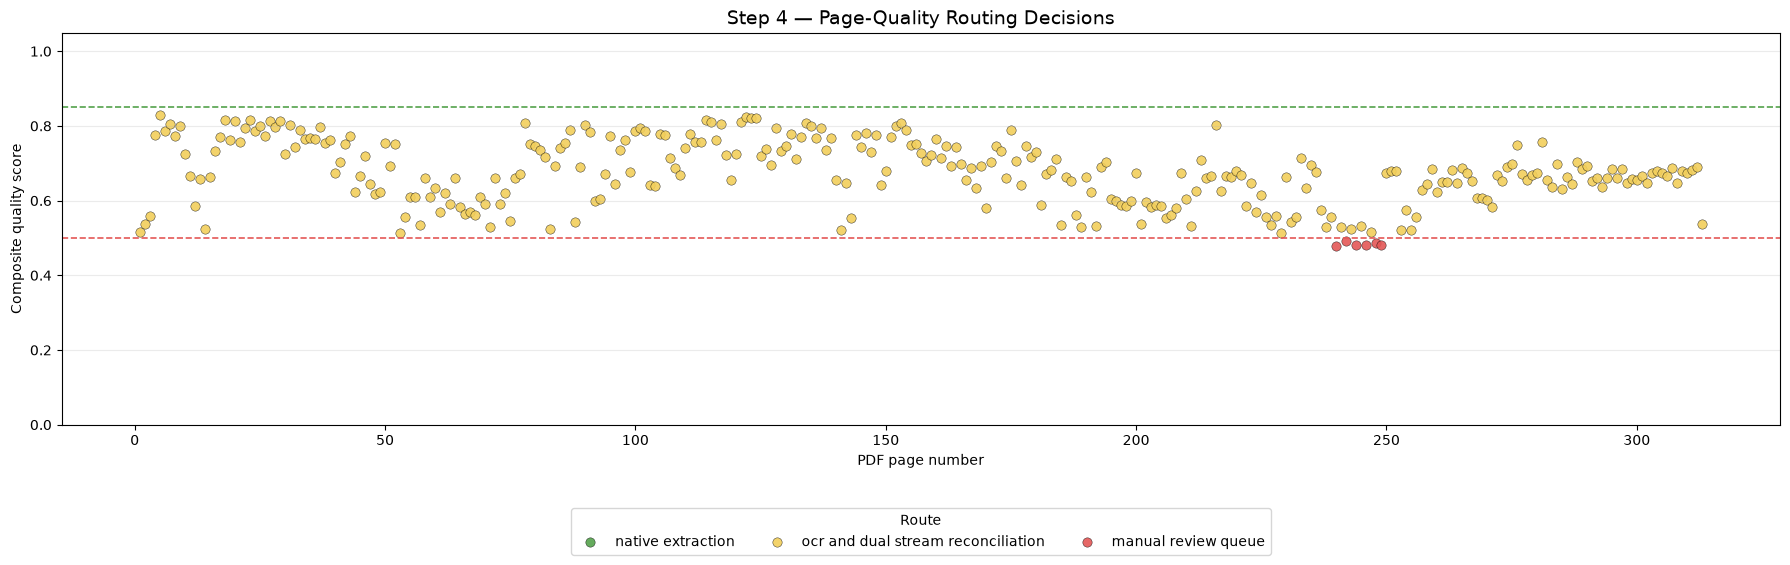

Saved page-routing chart: outputs/figures/step_04_page_quality_routing.png


In [64]:
route_colors = {
    routing_labels["native"]: "#54A24B",
    routing_labels["ocr_reconcile"]: "#F2CF5B",
    routing_labels["manual_review"]: "#E45756",
}

fig, ax = plt.subplots(figsize=(18, 6))

for route_name, route_color in route_colors.items():
    route_subset = page_quality_df.loc[
        page_quality_df["route"] == route_name
    ]

    ax.scatter(
        route_subset["page_number"],
        route_subset["composite_quality_score"],
        s=45,
        color=route_color,
        label=route_name.replace("_", " "),
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3,
    )

ax.axhline(
    low_threshold,
    color="#E45756",
    linestyle="--",
    linewidth=1.2,
)

ax.axhline(
    high_threshold,
    color="#54A24B",
    linestyle="--",
    linewidth=1.2,
)

ax.set_title("Step 4 — Page-Quality Routing Decisions", fontsize=14)
ax.set_xlabel("PDF page number")
ax.set_ylabel("Composite quality score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend(
    title="Route",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
)

plt.tight_layout()

routing_chart_path = FIGURES_DIR / "step_04_page_quality_routing.png"
fig.savefig(routing_chart_path, dpi=220, bbox_inches="tight")
plt.show()

print(
    "Saved page-routing chart: "
    f"{routing_chart_path.relative_to(STAGE_A_ROOT)}"
)

In [65]:
route_summary_df = (
    page_quality_df.groupby("route", as_index=False)
    .agg(
        page_count=("page_number", "size"),
        mean_composite_score=("composite_quality_score", "mean"),
        min_composite_score=("composite_quality_score", "min"),
        max_composite_score=("composite_quality_score", "max"),
    )
    .sort_values("route")
)

route_summary_df["share_of_document_pages"] = (
    route_summary_df["page_count"] / PDF_PAGE_COUNT
)

route_summary_df.style.format(
    {
        "mean_composite_score": "{:.3f}",
        "min_composite_score": "{:.3f}",
        "max_composite_score": "{:.3f}",
        "share_of_document_pages": "{:.1%}",
    }
)

,route,page_count,mean_composite_score,min_composite_score,max_composite_score,share_of_document_pages
0,manual_review_queue,6,0.484,0.480,0.493,1.9%
1,ocr_and_dual_stream_reconciliation,307,0.678,0.513,0.830,98.1%


In [66]:
LOWEST_QUALITY_PAGE_COUNT = min(15, PDF_PAGE_COUNT)

lowest_quality_pages_df = (
    page_quality_df.sort_values(
        ["composite_quality_score", "page_number"],
        ascending=[True, True],
    )
    .head(LOWEST_QUALITY_PAGE_COUNT)
    [
        [
            "page_number",
            "native_word_count",
            "native_text_character_count",
            "text_coverage_score",
            "character_quality_score",
            "reading_order_score",
            "table_like_page",
            "table_integrity_score",
            "composite_quality_score",
            "route",
            "diagnostic_reasons",
            "native_text_preview",
        ]
    ]
    .copy()
)

lowest_quality_pages_df.style.format(
    {
        "text_coverage_score": "{:.3f}",
        "character_quality_score": "{:.3f}",
        "reading_order_score": "{:.3f}",
        "table_integrity_score": "{:.3f}",
        "composite_quality_score": "{:.3f}",
    }
)

,page_number,native_word_count,native_text_character_count,text_coverage_score,character_quality_score,reading_order_score,table_like_page,table_integrity_score,composite_quality_score,route,diagnostic_reasons,native_text_preview
239,240,64,395,0.108,0.967,1.000,True,0.000,0.480,manual_review_queue,low_text_coverage=0.11 | table_alignment_risk=0.00 | low_composite_score_requires_manual_review,"DIAGRAM 1 GRADE PLANE CROSS SECTION VIEW Building Height 6’-0” Finished Grade Varies, see 6’-0” section 6-134(d) Grade Plane Walls Finished Grade Varies, see section 6-134(d) Existing Grade Fill PLAN VIEW OF LIMITS OF AREA FOR CALCULATING GRADE PLANE Property Line 6’-0” Less Than 6’-0” Building 6’-0” Six (6’) feet from building wall or property line, whichever is less. 6’-0” Diagrams – Page 1"
248,249,42,238,0.090,1.000,1.000,True,0.000,0.481,manual_review_queue,low_text_coverage=0.09 | table_alignment_risk=0.00 | low_composite_score_requires_manual_review,DIAGRAM 9 ILLUSTRATION OF YARDS FOR IRREGULAR SHAPED LOT Rear Lot Line Rear Yard Principal Building Side Side Yard Yard Side Side Lot Lot Line Line Front Yard Front Lot Line Street Required (minimum) Yard See Sec. 6-205 Diagrams – Page 10
245,246,41,244,0.090,1.000,1.000,True,0.000,0.481,manual_review_queue,low_text_coverage=0.09 | table_alignment_risk=0.00 | low_composite_score_requires_manual_review,DIAGRAM 7 ILLUSTRATION DISTINGUISHING YARDS FROM REQUIRED YARDS Rear Lot Line Rear Yard Side Yard Side Side Yard Side Principal Building Lot Lot Line Line Front Yard Street Front Lot Line Required (minimum) Yard See Sec. 6-205 Diagrams – Page 7
243,244,55,329,0.105,0.988,0.994,True,0.000,0.482,manual_review_queue,low_text_coverage=0.10 | table_alignment_risk=0.00 | low_composite_score_requires_manual_review,DIAGRAM 5 BASEMENT AREA COUNTED AS A STORY ABOVE GRADE UNDER THE FOLLOWING CONDITIONS Attic 1st Floor Above Finished surface of floor More than 5’-0” above Grade Plane Basement Grade Plane Attic 1st Floor Above Finished surface of floor Finished More than 12’-0” above Basement Grade Finished Grade at any point Diagrams – Page 5
247,248,52,312,0.102,1.000,1.000,True,0.000,0.486,manual_review_queue,low_text_coverage=0.10 | table_alignment_risk=0.00 | low_composite_score_requires_manual_review,DIAGRAM 8 ILLUSTRATION OF LOT FRONTAGE MEASUREMENT Rear Lot Line Rear Yard Side Yard Side Side Lot Lot Side Yard Line Line Principal Building Minimum Frontage Front must extend 200% of Yard minimum front yard depth Street Minimum Frontage Required by Zone Required (minimum) Yard See Sec. 6-205 Diagrams – Page 9
241,242,105,631,0.136,0.981,1.000,True,0.000,0.493,manual_review_queue,low_text_coverage=0.14 | table_alignment_risk=0.00 | low_composite_score_requires_manual_review,"DIAGRAM 3 BASEMENT AREAS INCLUDED AND EXCLUDED FROM GROSS FLOOR AREA (GFA) None of basement or crawl space Attic area included in GFA 1st Floor Above Finished surface of floor 5’-0” Less than 3’-0” above BasementGrade More than 4’-0” belowPlane Crawl Space Attic 50% of basement area* included in GFA 1st Floor Above Finished surface of floor More than 3’-0” Less than 5’-0” BasementGrade *Excluding crawl spaces and Plane basement areas for parking, laundry equipment and mechanical equipment. Attic"
52,53,49,296,0.098,1.000,1.000,True,0.141,0.513,ocr_and_dual_stream_reconciliation,low_text_coverage=0.10 | table_alignment_risk=0.14 | intermediate_composite_score_requires_ocr_comparison,"§6-34 LAND USE §6-34 (4) No building permit or certificate of occupancy shall be issued by the Building Official, nor shall the Town accept any street, should the Conservation Plan, Subdivision Plan or Site Plan be changed in any way without the approval of the Commission. (2/18/82, 4/24/13) 3-8"
228,229,93,568,0.124,1.000,1.000,True,0.101,0.514,ocr_and_dual_stream_reconciliation,low_text_coverage=0.12 | table_alignment_risk=0.10 | intermediate_composite_score_requires_ocr_comparison,"§6-202 GREENWICH MUNICIPAL CODE §6-202 DIVISION 20. PENALTIES. Se

### Manual inspection of the highest-risk pages

The pages below are rendered for direct inspection.

Review these pages for the specific diagnostic reason recorded in the quality table:

- sparse or missing native text
- unreadable or corrupted characters
- multi-column or irregular reading order
- dense dimensional schedules or tabular layouts
- scanned pages
- maps, graphics, or signatures
- repeated headers/footers dominating page text
- any mismatch between the visible source and the extracted native-text preview

The route is a recommendation. If a page contains legally important content, manually inspect it even if it routes to native extraction.

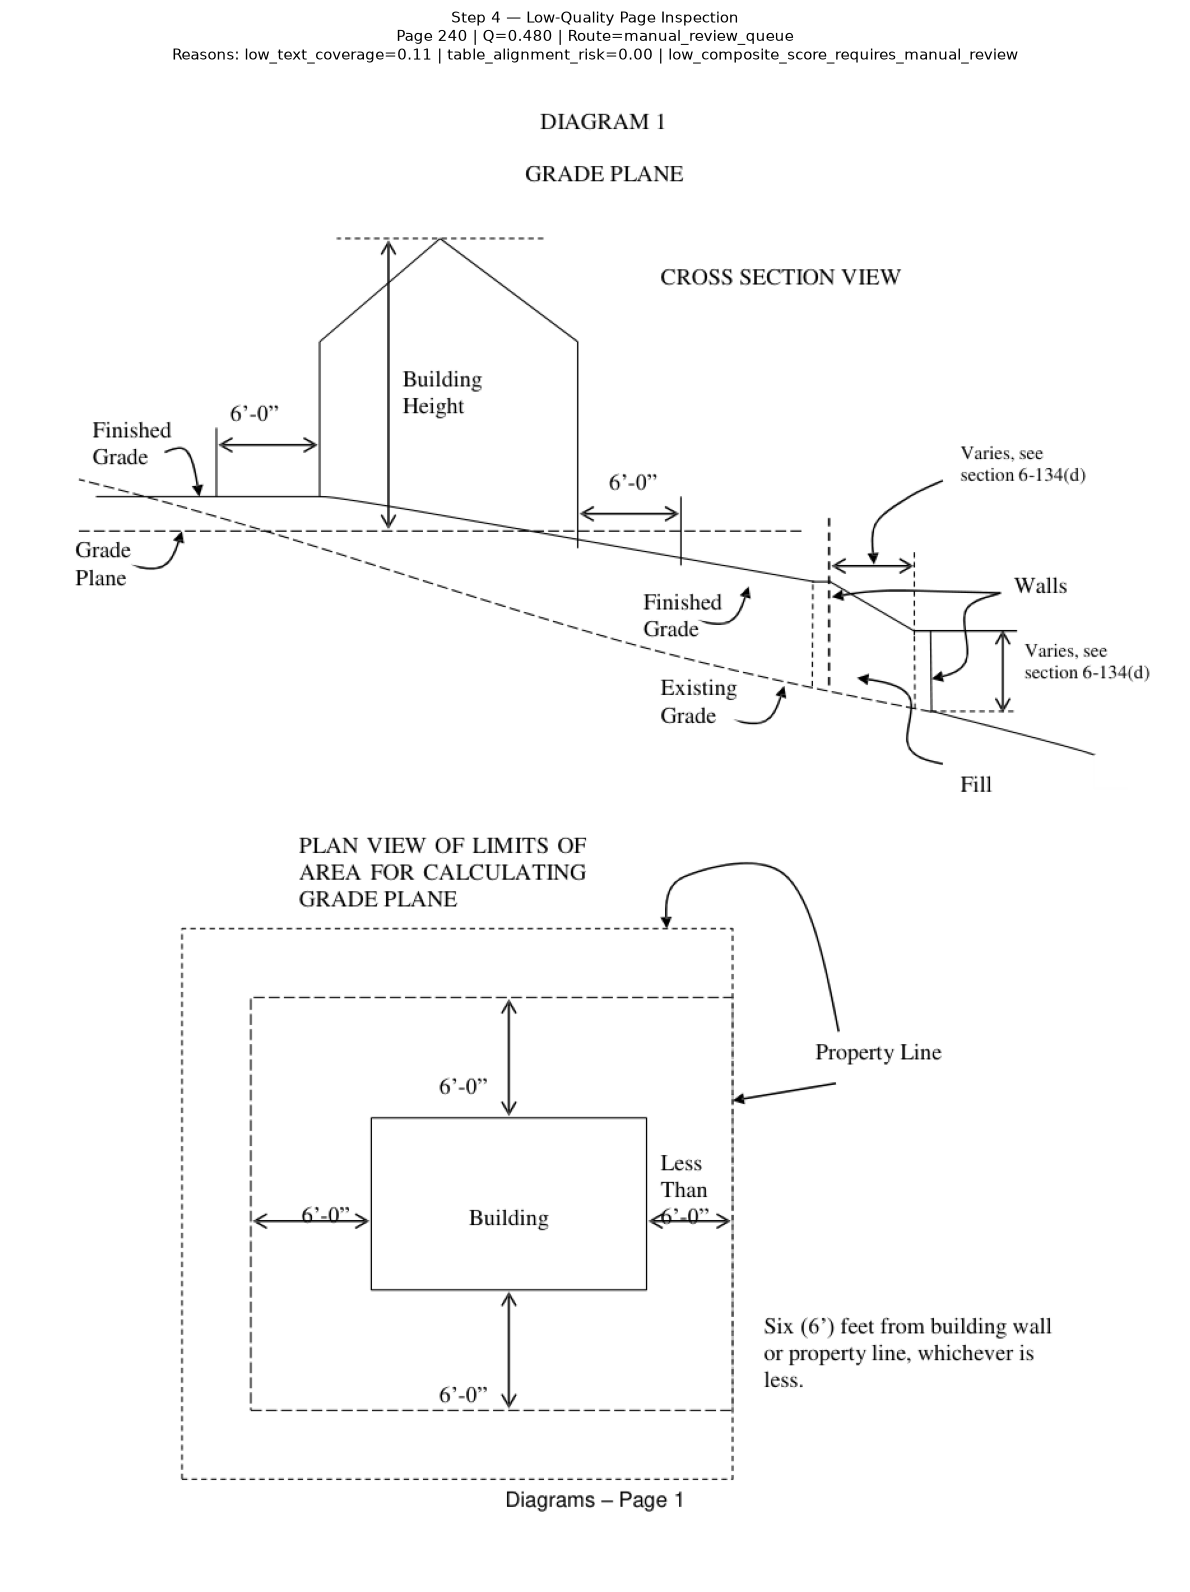

Saved risk-page preview: outputs/figures/step_04_risk_page_preview_240.png


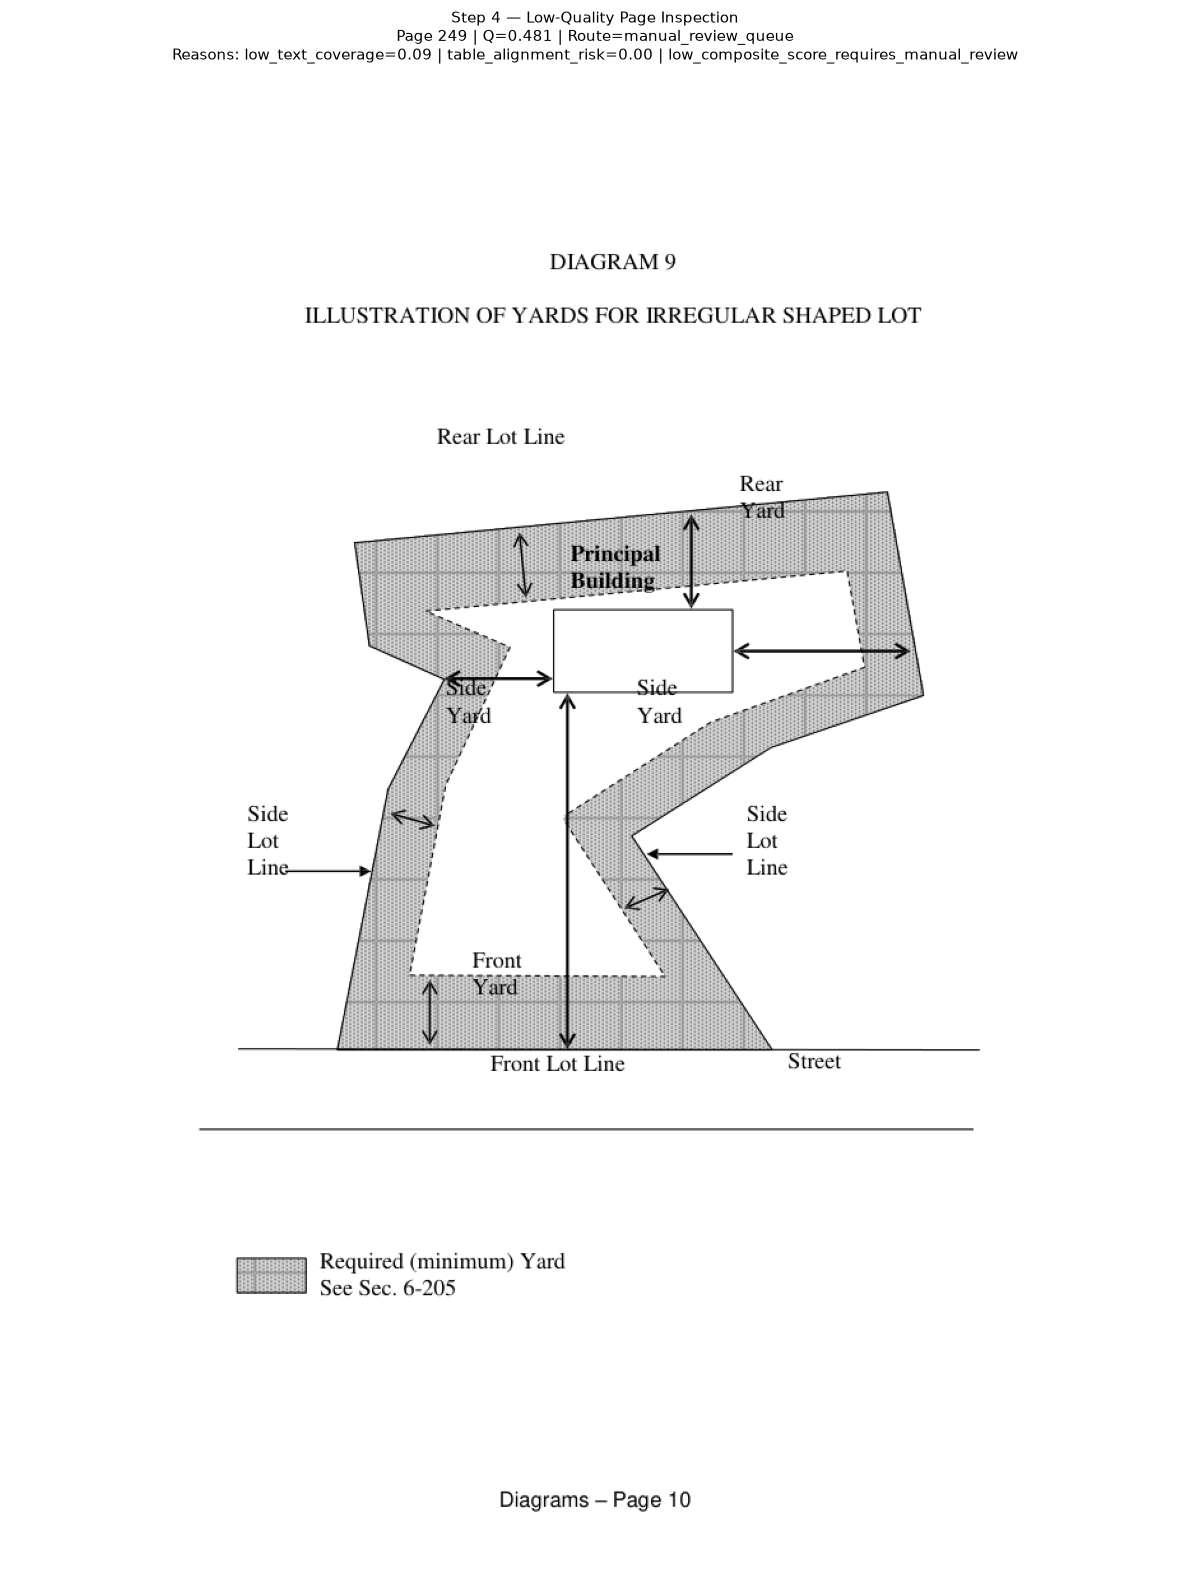

Saved risk-page preview: outputs/figures/step_04_risk_page_preview_249.png


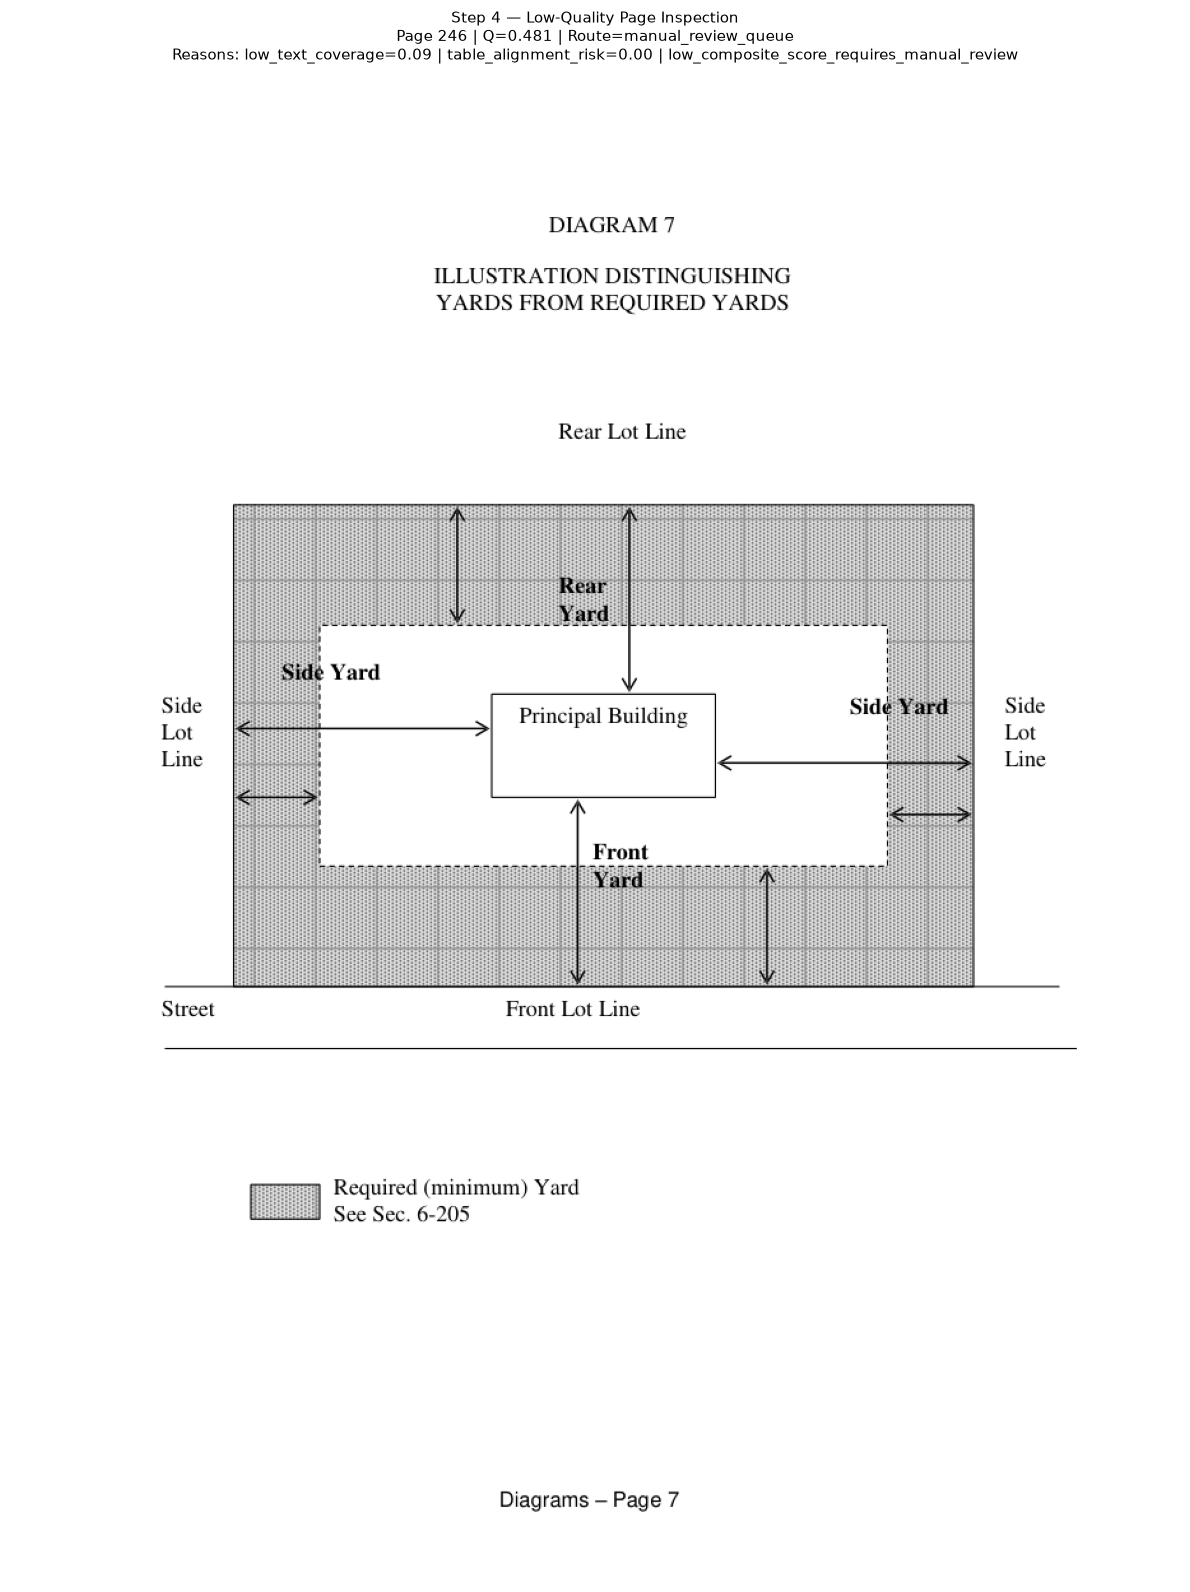

Saved risk-page preview: outputs/figures/step_04_risk_page_preview_246.png


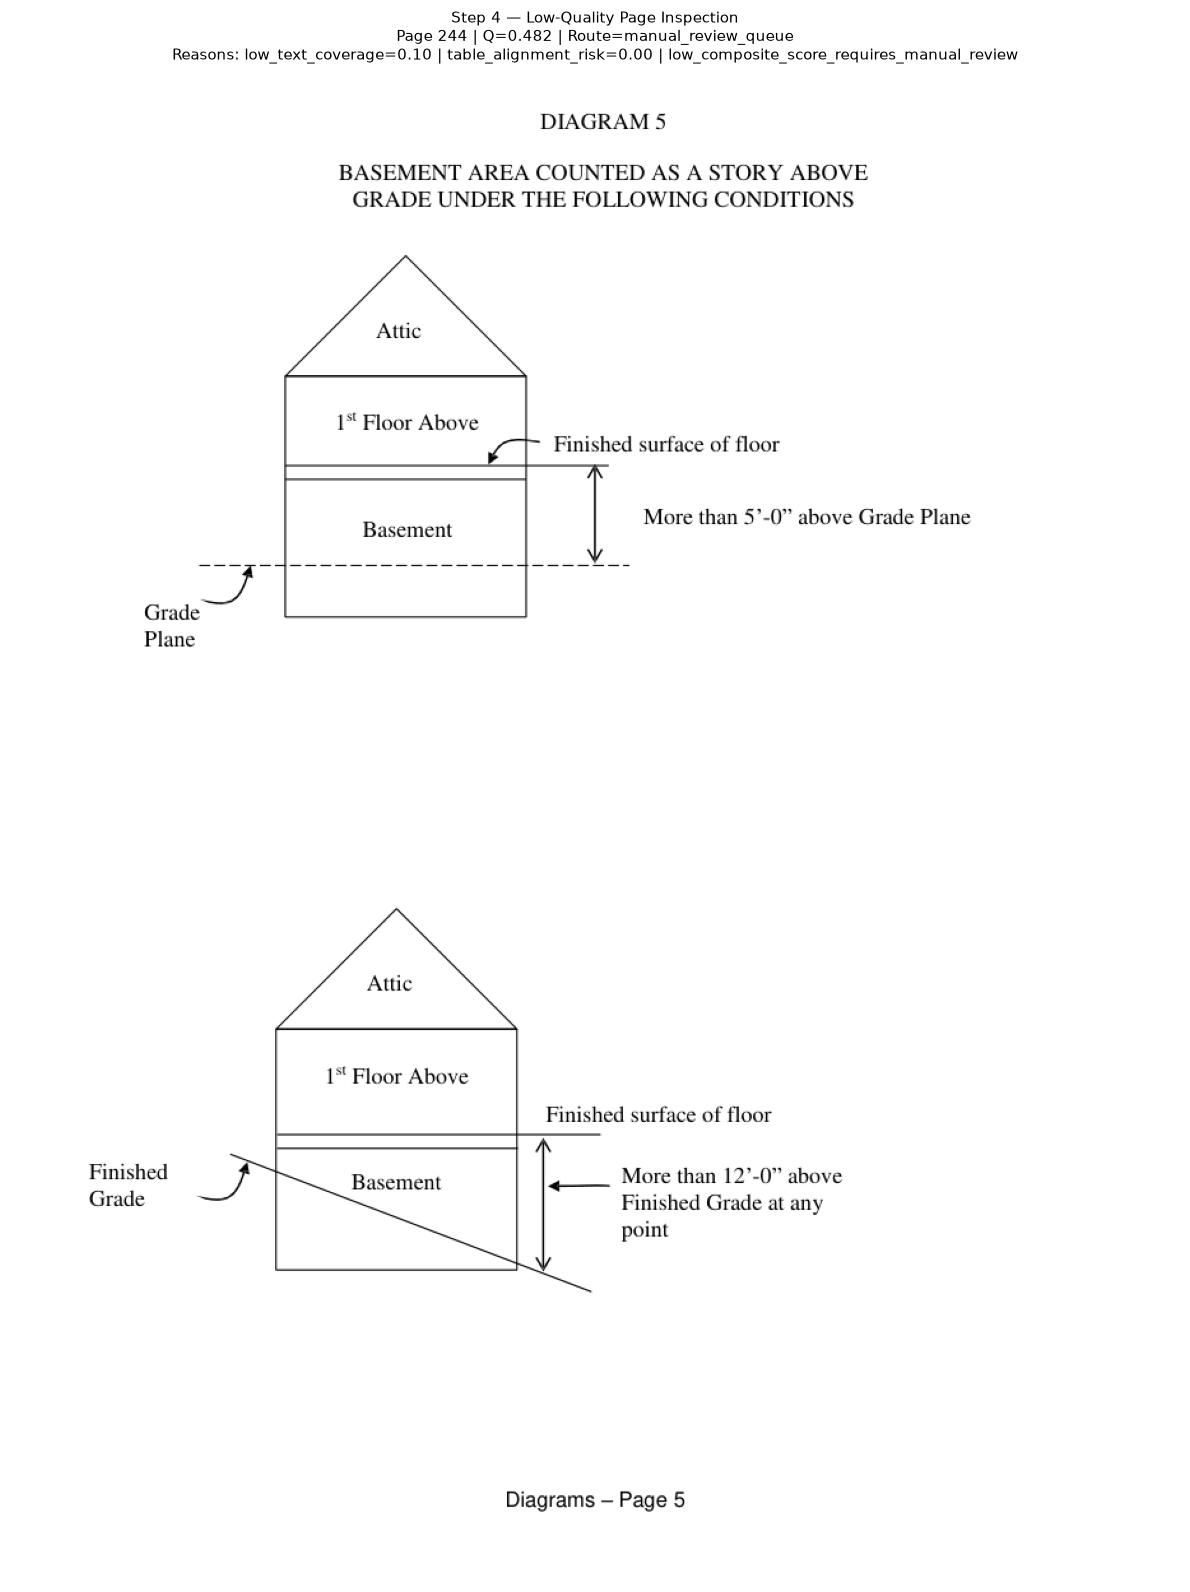

Saved risk-page preview: outputs/figures/step_04_risk_page_preview_244.png


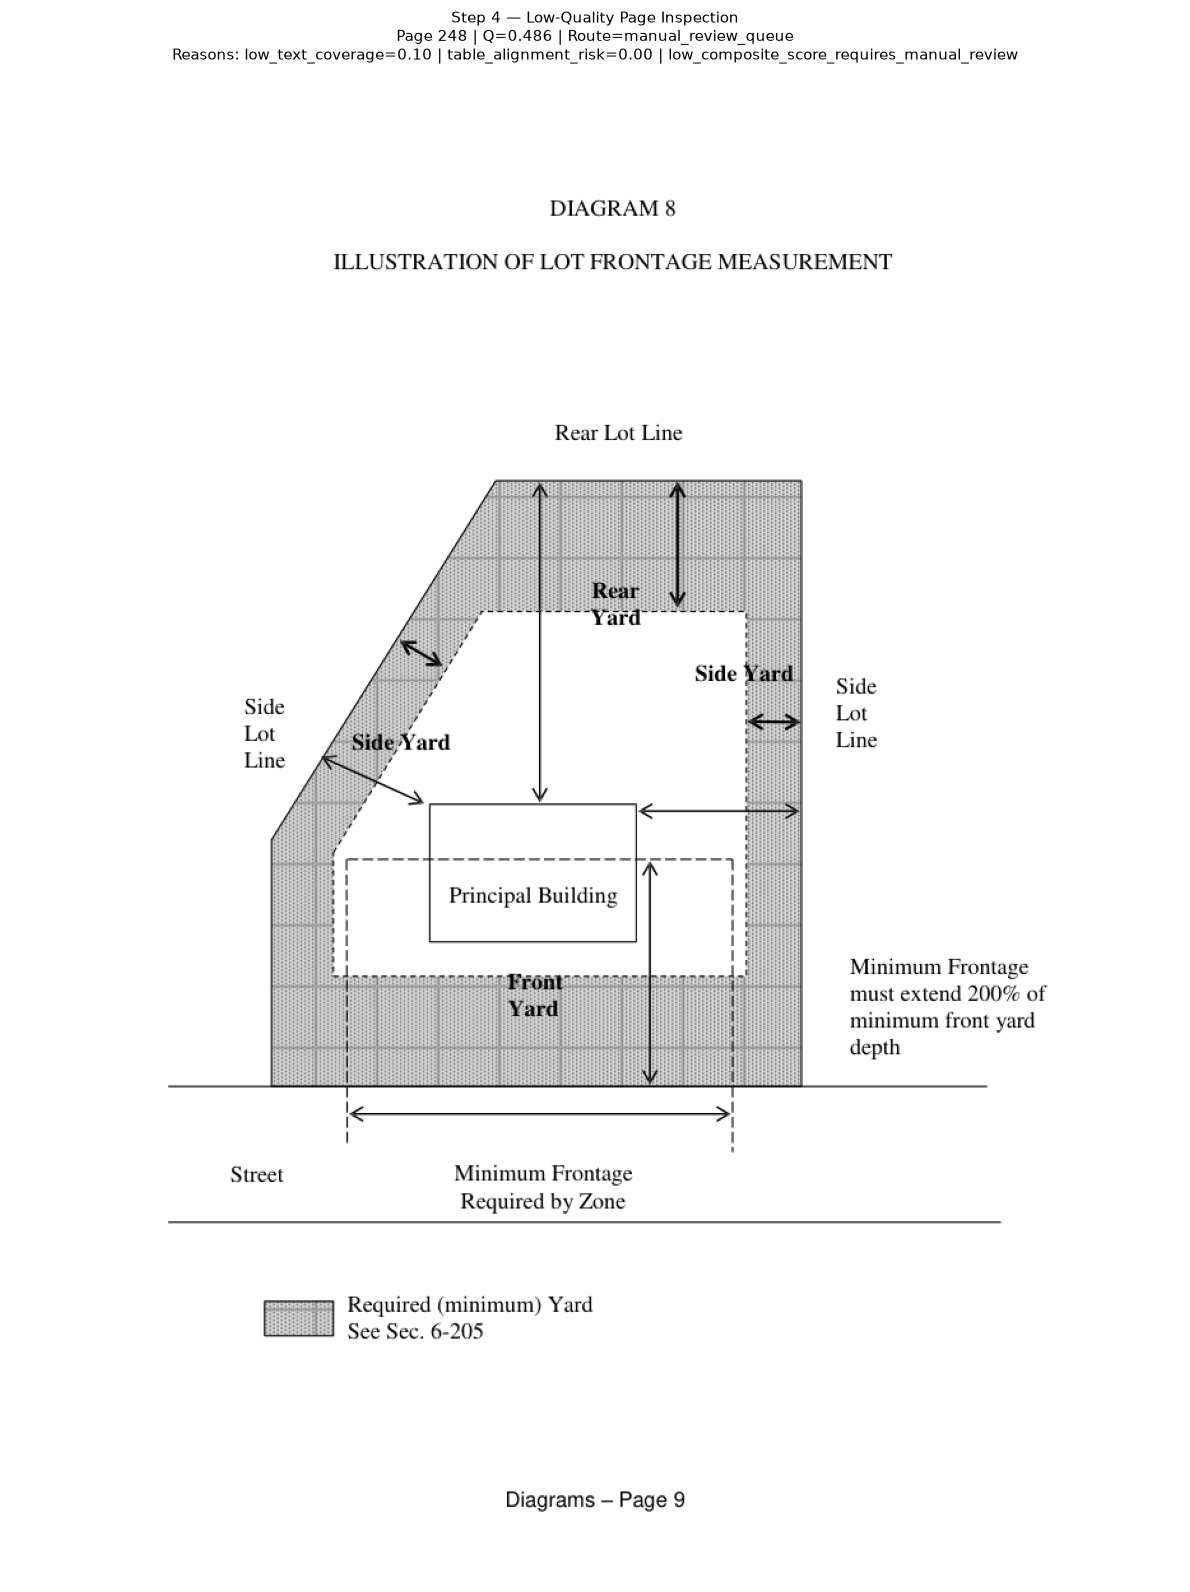

Saved risk-page preview: outputs/figures/step_04_risk_page_preview_248.png


In [67]:
RISK_PAGE_PREVIEW_COUNT = min(5, PDF_PAGE_COUNT)

risk_page_numbers = lowest_quality_pages_df[
    "page_number"
].head(RISK_PAGE_PREVIEW_COUNT).tolist()

risk_page_preview_paths = []

for page_number in risk_page_numbers:
    page_row = page_quality_df.loc[
        page_quality_df["page_number"] == page_number
    ].iloc[0]

    risk_page_image = render_pdf_page(
        PDF_PATH,
        page_number=int(page_number),
        zoom=1.5,
    )

    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(risk_page_image)
    ax.set_title(
        "\n".join(
            [
                "Step 4 — Low-Quality Page Inspection",
                (
                    f"Page {int(page_number)} | "
                    f"Q={page_row['composite_quality_score']:.3f} | "
                    f"Route={page_row['route']}"
                ),
                f"Reasons: {page_row['diagnostic_reasons']}",
            ]
        ),
        fontsize=11,
    )
    ax.axis("off")
    plt.tight_layout()

    risk_page_preview_path = (
        FIGURES_DIR / f"step_04_risk_page_preview_{int(page_number):03d}.png"
    )

    fig.savefig(risk_page_preview_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    risk_page_preview_paths.append(risk_page_preview_path)

    print(
        "Saved risk-page preview: "
        f"{risk_page_preview_path.relative_to(STAGE_A_ROOT)}"
    )

In [68]:
page_quality_output_path = (
    TABLES_DIR / PAGE_QUALITY_SCORING_CONFIG["output_filename"]
)

route_summary_output_path = TABLES_DIR / "step_04_route_summary.csv"

lowest_quality_output_path = TABLES_DIR / "step_04_lowest_quality_pages.csv"

page_quality_df.to_csv(page_quality_output_path, index=False)

route_summary_df.to_csv(route_summary_output_path, index=False)

lowest_quality_pages_df.to_csv(lowest_quality_output_path, index=False)

step_4_log = {
    "document_id": DOCUMENT_ID,
    "page_quality_scoring_config": PAGE_QUALITY_SCORING_CONFIG,
    "quality_score_summary": {
        "minimum": float(page_quality_df["composite_quality_score"].min()),
        "median": float(page_quality_df["composite_quality_score"].median()),
        "mean": float(page_quality_df["composite_quality_score"].mean()),
        "maximum": float(page_quality_df["composite_quality_score"].max()),
    },
    "route_counts": {
        route_name: int(
            (page_quality_df["route"] == route_name).sum()
        )
        for route_name in route_colors
    },
    "quality_histogram_path": str(
        quality_histogram_path.relative_to(STAGE_A_ROOT)
    ),
    "routing_chart_path": str(
        routing_chart_path.relative_to(STAGE_A_ROOT)
    ),
    "risk_page_preview_paths": [
        str(path.relative_to(STAGE_A_ROOT))
        for path in risk_page_preview_paths
    ],
}

step_4_log_path = LOGS_DIR / "step_04_page_quality_routing_log.json"

with step_4_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(step_4_log, file_handle, indent=2, ensure_ascii=False, default=list)

print(
    f"Saved quality-score table: "
    f"{page_quality_output_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved routing summary: "
    f"{route_summary_output_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved lowest-quality page list: "
    f"{lowest_quality_output_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved page-quality routing log: "
    f"{step_4_log_path.relative_to(STAGE_A_ROOT)}"
)

Saved quality-score table: outputs/tables/step_04_page_quality_scores.csv
Saved routing summary: outputs/tables/step_04_route_summary.csv
Saved lowest-quality page list: outputs/tables/step_04_lowest_quality_pages.csv
Saved page-quality routing log: outputs/logs/step_04_page_quality_routing_log.json


## Step 5 — Targeted OCR and dual-stream reconciliation

### Objective

Apply OCR only to pages routed in Step 4 to either:

- `ocr_and_dual_stream_reconciliation`; or
- `manual_review_queue`.

For every OCR-processed page, this step:

1. renders the original PDF page at high resolution
2. preprocesses the image
3. extracts OCR words, bounding boxes, and confidence values
4. reconstructs OCR text in OCR reading order
5. compares native and OCR page text
6. creates a reconciled text representation
7. logs changed, uncertain, and unresolved cases

### Routing policy

- Pages routed to `native_extraction` are not OCR-processed in this step.
- Pages routed to `ocr_and_dual_stream_reconciliation` receive OCR and automated comparison.
- Pages routed to `manual_review_queue` receive OCR as a diagnostic aid, but their reconciled result is not automatically accepted as authoritative.

### Source-preservation rule

The original raw PDF remains unchanged. Rendered images, preprocessed images, OCR token tables, reconciled text, and review logs are derived artifacts stored outside `data/raw/`

### Reconciliation policy for this first prototype

For each OCR-processed page, compare the normalized native text and normalized OCR text using normalized Levenshtein similarity.

$$\text{similarity}(p) = 1 - \frac{\text{LevenshteinDistance}(T_{p,\text{native}}, T_{p,\text{OCR}})}{\max(|T_{p,\text{native}}|, |T_{p,\text{OCR}}|)}$$

The prototype reconciliation policy is:

| Condition | Reconciled page text | Review status |
|---|---|---|
| Native text is nearly empty and OCR has usable confidence | OCR text | OCR accepted provisionally |
| Native/OCR similarity is high | Native text | Native retained; OCR confirms it |
| Similarity is intermediate and OCR confidence is strong | Native text retained with OCR comparison evidence | Reconciliation review required |
| Similarity is low or OCR confidence is weak | Native text retained without automatic replacement | Manual review required |
| Page was already routed to manual review | No automatic authoritative replacement | Manual review required |

This policy is deliberately conservative. It avoids silently mixing language from two legal-text streams into a fabricated hybrid sentence. A later version can reconcile at line, span, or token level after manual validation

In [42]:
import shutil
from difflib import SequenceMatcher

import cv2
import pytesseract
from pytesseract import Output

In [43]:
OCR_CONFIG = {
    "enabled": True,
    "language": "eng",
    "render_zoom": 2.5,
    "tesseract_page_segmentation_mode": 6,
    "tesseract_ocr_engine_mode": 3,
    "minimum_word_confidence": 30.0,
    "minimum_mean_page_confidence": 55.0,
    "minimum_ocr_word_count": 10,
    "native_text_nearly_empty_characters": 50,
    "high_similarity_threshold": 0.92,
    "intermediate_similarity_threshold": 0.65,
    "adaptive_threshold_block_size": 31,
    "adaptive_threshold_constant": 11,
    "gaussian_blur_kernel_size": 3,
    "deskew_enabled": True,
    "save_rendered_page_images": True,
    "save_preprocessed_page_images": True,
    "save_ocr_word_boxes": True,
    "tesseract_cmd": None,
    "output_ocr_tokens_filename": "step_05_ocr_word_tokens.parquet",
    "output_reconciliation_filename": "step_05_reconciliation_results.csv",
}

assert OCR_CONFIG["adaptive_threshold_block_size"] % 2 == 1, (
    "OpenCV adaptive-threshold block size must be odd."
)

if OCR_CONFIG["tesseract_cmd"] is not None:
    pytesseract.pytesseract.tesseract_cmd = OCR_CONFIG["tesseract_cmd"]

tesseract_path = shutil.which("tesseract")

if tesseract_path is None and OCR_CONFIG["tesseract_cmd"] is None:
    raise EnvironmentError(
        "Tesseract was not found on PATH. Install the system-level Tesseract "
        "executable, restart the terminal/VS Code, and rerun this cell. "
        "On Windows, alternatively set OCR_CONFIG['tesseract_cmd'] to the "
        "full path of tesseract.exe."
    )

print(
    "Tesseract command: "
    f"{OCR_CONFIG['tesseract_cmd'] or tesseract_path}"
)
print(
    "Tesseract version:\n"
    f"{pytesseract.get_tesseract_version()}"
)

Tesseract command: /opt/homebrew/bin/tesseract
Tesseract version:
5.5.3


In [44]:
routing_labels = PAGE_QUALITY_SCORING_CONFIG["routing_labels"]

ocr_reconciliation_pages_df = page_quality_df.loc[
    page_quality_df["route"] == routing_labels["ocr_reconcile"]
].copy()

manual_review_pages_df = page_quality_df.loc[
    page_quality_df["route"] == routing_labels["manual_review"]
].copy()

ocr_target_pages_df = (
    pd.concat(
        [
            ocr_reconciliation_pages_df,
            manual_review_pages_df,
        ],
        ignore_index=True,
    )
    .sort_values("page_number")
    .reset_index(drop=True)
)

ocr_target_pages_df[
    [
        "page_number",
        "composite_quality_score",
        "route",
        "diagnostic_reasons",
    ]
]

,page_number,composite_quality_score,route,diagnostic_reasons
0,1,0.515232,ocr_and_dual_stream_reconciliation,low_native_word_count=17 | low_text_coverage=0...
1,2,0.537231,ocr_and_dual_stream_reconciliation,low_text_coverage=0.15 | table_alignment_risk=...
2,3,0.557800,ocr_and_dual_stream_reconciliation,low_native_word_count=3 | low_native_character...
3,4,0.774757,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.54 | intermediate_compo...
4,5,0.830049,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.71 | intermediate_compo...
...,...,...,...,...
308,309,0.679755,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.16 | intermediate_compo...
309,310,0.675095,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.17 | intermediate_compo...
310,311,0.682968,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.16 | intermediate_compo...
311,312,0.689916,ocr_and_dual_stream_reconciliation,table_alignment_risk=0.15 | intermediate_compo...


In [45]:
print(
    f"Pages routed to OCR and reconciliation: "
    f"{len(ocr_reconciliation_pages_df):,}"
)
print(
    f"Pages routed to manual review with diagnostic OCR: "
    f"{len(manual_review_pages_df):,}"
)
print(f"Total pages selected for OCR: {len(ocr_target_pages_df):,}")

if ocr_target_pages_df.empty:
    print(
        "No pages were routed to OCR in Step 4. This is valid if all pages "
        "passed the native-extraction threshold, but inspect Step 4 manually "
        "before deciding that OCR is unnecessary."
    )

Pages routed to OCR and reconciliation: 307
Pages routed to manual review with diagnostic OCR: 6
Total pages selected for OCR: 313


### Image preprocessing

Each selected page is rendered directly from the source PDF at elevated resolution, then processed as follows:

$$\mathcal{P} = g_{\text{noise reduction}} \circ g_{\text{deskew}} \circ g_{\text{binarize}}$$

The implementation uses:

1. grayscale conversion;
2. light Gaussian blur for noise reduction;
3. adaptive Gaussian thresholding;
4. optional deskew based on the estimated orientation of foreground pixels.

Both the original rendered image and the preprocessed image are saved for inspection. OCR does not modify the source PDF.

In [46]:
def render_pdf_page_bgr(
    pdf_path: Path,
    page_number: int,
    zoom: float,
) -> np.ndarray:
    """
    Render a 1-indexed PDF page as a BGR image for OpenCV processing.
    """
    with fitz.open(pdf_path) as document:
        page = document.load_page(page_number - 1)
        pixmap = page.get_pixmap(
            matrix=fitz.Matrix(zoom, zoom),
            alpha=False,
        )

    rgb_image = np.frombuffer(
        pixmap.samples,
        dtype=np.uint8,
    ).reshape(pixmap.height, pixmap.width, 3)

    return cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)


def estimate_skew_angle(binary_image: np.ndarray) -> float:
    """
    Estimate page skew using the minimum-area rectangle around foreground pixels.

    A near-empty or degenerate page returns zero degrees.
    """
    foreground_coordinates = np.column_stack(
        np.where(binary_image < 255)
    )

    if len(foreground_coordinates) < 100:
        return 0.0

    angle = cv2.minAreaRect(foreground_coordinates)[-1]

    if angle < -45:
        angle = 90 + angle

    return float(angle)


def deskew_binary_image(binary_image: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Rotate a binary image to reduce estimated skew while preserving dimensions.
    """
    angle = estimate_skew_angle(binary_image)

    if abs(angle) < 0.10:
        return binary_image, 0.0

    height, width = binary_image.shape[:2]
    center = (width // 2, height // 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        binary_image,
        rotation_matrix,
        (width, height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )

    return rotated, angle


def preprocess_for_ocr(
    bgr_image: np.ndarray,
    config: dict,
) -> tuple[np.ndarray, dict]:
    """
    Create a binarized, optionally deskewed image for Tesseract OCR.
    """
    grayscale = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)

    blur_kernel = config["gaussian_blur_kernel_size"]

    if blur_kernel % 2 == 0:
        blur_kernel += 1

    blurred = cv2.GaussianBlur(
        grayscale,
        (blur_kernel, blur_kernel),
        0,
    )

    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        config["adaptive_threshold_block_size"],
        config["adaptive_threshold_constant"],
    )

    if config["deskew_enabled"]:
        processed_image, deskew_angle = deskew_binary_image(binary)
    else:
        processed_image = binary
        deskew_angle = 0.0

    preprocessing_metadata = {
        "render_zoom": config["render_zoom"],
        "adaptive_threshold_block_size": config["adaptive_threshold_block_size"],
        "adaptive_threshold_constant": config["adaptive_threshold_constant"],
        "gaussian_blur_kernel_size": blur_kernel,
        "deskew_enabled": config["deskew_enabled"],
        "estimated_deskew_angle_degrees": deskew_angle,
    }

    return processed_image, preprocessing_metadata

In [47]:
def normalize_for_comparison(text: str | None) -> str:
    """
    Normalize text for OCR/native comparison without changing source evidence.

    This normalized representation is used only for similarity calculation.
    Original native and OCR text are retained separately.
    """
    if not text:
        return ""

    normalized = text.lower()
    normalized = normalized.replace("–", "-").replace("—", "-")
    normalized = re.sub(r"\s+", " ", normalized)
    normalized = re.sub(r"[^\w\s§\-.(),/&]", "", normalized)

    return normalized.strip()


def normalized_levenshtein_similarity(
    text_a: str | None,
    text_b: str | None,
) -> float:
    """
    Return a normalized edit-distance similarity in [0, 1].

    A value of 1.0 means identical normalized strings.
    """
    normalized_a = normalize_for_comparison(text_a)
    normalized_b = normalize_for_comparison(text_b)

    if not normalized_a and not normalized_b:
        return 1.0

    if not normalized_a or not normalized_b:
        return 0.0

    matcher = SequenceMatcher(
        None,
        normalized_a,
        normalized_b,
        autojunk=False,
    )

    return matcher.ratio()


def build_page_native_text(
    tokens_df: pd.DataFrame,
    page_number: int,
) -> str:
    """
    Reconstruct native page text from Step 3 word tokens in native sequence.
    """
    page_tokens = tokens_df.loc[
        tokens_df["page_number"] == page_number
    ].sort_values("native_word_sequence_on_page")

    return " ".join(page_tokens["text"].astype(str).tolist())


def summarize_text_difference(
    native_text: str,
    ocr_text: str,
    max_length: int = 500,
) -> str:
    """
    Create a compact, human-readable reconciliation note.

    It does not replace the full source strings stored in the output table.
    """
    native_normalized = normalize_for_comparison(native_text)
    ocr_normalized = normalize_for_comparison(ocr_text)

    if native_normalized == ocr_normalized:
        return "normalized_native_and_ocr_text_match"

    matcher = SequenceMatcher(
        None,
        native_normalized,
        ocr_normalized,
        autojunk=False,
    )

    difference_fragments = []

    for operation, a0, a1, b0, b1 in matcher.get_opcodes():
        if operation == "equal":
            continue

        native_fragment = native_normalized[a0:a1]
        ocr_fragment = ocr_normalized[b0:b1]

        difference_fragments.append(
            f"{operation}: native='{native_fragment[:100]}' "
            f"ocr='{ocr_fragment[:100]}'"
        )

        if len(difference_fragments) >= 5:
            break

    summary = " | ".join(difference_fragments)

    return summary[:max_length] if summary else "difference_detected"

### OCR extraction schema

For each OCR word, retain:

- recognized text
- OCR confidence
- pixel-space bounding box
- OCR block, paragraph, line, and word identifiers
- rendered-image dimensions
- preprocessing parameters
- source PDF page number
- page-level route and review status

OCR bounding boxes are stored in rendered-image pixel coordinates. They are not assumed to be identical to native PDF point coordinates. The extraction engine and coordinate system are therefore preserved explicitly

In [48]:
def extract_ocr_words(
    processed_image: np.ndarray,
    document_id: str,
    page_number: int,
    page_route: str,
    config: dict,
) -> tuple[pd.DataFrame, dict]:
    """
    Run Tesseract OCR and return word-level results plus page-level metrics.
    """
    tesseract_config = (
        f"--oem {config['tesseract_ocr_engine_mode']} "
        f"--psm {config['tesseract_page_segmentation_mode']}"
    )

    ocr_data = pytesseract.image_to_data(
        processed_image,
        lang=config["language"],
        config=tesseract_config,
        output_type=Output.DATAFRAME,
    )

    ocr_data = ocr_data.dropna(subset=["text"]).copy()
    ocr_data["text"] = ocr_data["text"].astype(str).str.strip()

    ocr_data["conf"] = pd.to_numeric(
        ocr_data["conf"],
        errors="coerce",
    )

    ocr_words = ocr_data.loc[
        (ocr_data["text"] != "")
        & (ocr_data["conf"] >= 0)
    ].copy()

    image_height, image_width = processed_image.shape[:2]

    if ocr_words.empty:
        empty_columns = [
            "document_id",
            "ocr_token_id",
            "text",
            "page_number",
            "page_route",
            "bbox_left_px",
            "bbox_top_px",
            "bbox_width_px",
            "bbox_height_px",
            "bbox_right_px",
            "bbox_bottom_px",
            "ocr_confidence",
            "ocr_level",
            "ocr_block_number",
            "ocr_paragraph_number",
            "ocr_line_number",
            "ocr_word_number",
            "rendered_image_width_px",
            "rendered_image_height_px",
            "coordinate_system",
            "extraction_engine",
            "extraction_method",
            "review_status",
        ]

        return pd.DataFrame(columns=empty_columns), {
            "ocr_word_count": 0,
            "ocr_mean_word_confidence": np.nan,
            "ocr_median_word_confidence": np.nan,
            "ocr_text": "",
            "ocr_text_character_count": 0,
        }

    ocr_words = ocr_words.reset_index(drop=True)

    ocr_words["ocr_token_id"] = [
        f"{document_id}-p{page_number:04d}-ocrw{index + 1:06d}"
        for index in range(len(ocr_words))
    ]

    ocr_words["document_id"] = document_id
    ocr_words["page_number"] = page_number
    ocr_words["page_route"] = page_route

    ocr_words["bbox_right_px"] = (
        ocr_words["left"] + ocr_words["width"]
    )
    ocr_words["bbox_bottom_px"] = (
        ocr_words["top"] + ocr_words["height"]
    )

    ocr_words["rendered_image_width_px"] = image_width
    ocr_words["rendered_image_height_px"] = image_height
    ocr_words["coordinate_system"] = "rendered_page_pixels_origin_top_left"
    ocr_words["extraction_engine"] = "tesseract"
    ocr_words["extraction_method"] = "targeted_ocr"
    ocr_words["review_status"] = "ocr_extracted_not_yet_reconciled"

    ocr_words = ocr_words.rename(
        columns={
            "conf": "ocr_confidence",
            "level": "ocr_level",
            "block_num": "ocr_block_number",
            "par_num": "ocr_paragraph_number",
            "line_num": "ocr_line_number",
            "word_num": "ocr_word_number",
            "left": "bbox_left_px",
            "top": "bbox_top_px",
            "width": "bbox_width_px",
            "height": "bbox_height_px",
        }
    )

    ocr_words = ocr_words.sort_values(
        [
            "ocr_block_number",
            "ocr_paragraph_number",
            "ocr_line_number",
            "ocr_word_number",
        ]
    ).reset_index(drop=True)

    ocr_text = " ".join(ocr_words["text"].tolist())

    output_columns = [
        "document_id",
        "ocr_token_id",
        "text",
        "page_number",
        "page_route",
        "bbox_left_px",
        "bbox_top_px",
        "bbox_width_px",
        "bbox_height_px",
        "bbox_right_px",
        "bbox_bottom_px",
        "ocr_confidence",
        "ocr_level",
        "ocr_block_number",
        "ocr_paragraph_number",
        "ocr_line_number",
        "ocr_word_number",
        "rendered_image_width_px",
        "rendered_image_height_px",
        "coordinate_system",
        "extraction_engine",
        "extraction_method",
        "review_status",
    ]

    ocr_words = ocr_words[output_columns]

    page_metrics = {
        "ocr_word_count": len(ocr_words),
        "ocr_mean_word_confidence": float(
            ocr_words["ocr_confidence"].mean()
        ),
        "ocr_median_word_confidence": float(
            ocr_words["ocr_confidence"].median()
        ),
        "ocr_text": ocr_text,
        "ocr_text_character_count": len(ocr_text),
    }

    return ocr_words, page_metrics

In [49]:
def reconcile_page_streams(
    native_text: str,
    ocr_text: str,
    mean_ocr_confidence: float | None,
    ocr_word_count: int,
    page_route: str,
    config: dict,
) -> dict:
    """
    Create a conservative page-level reconciliation decision.

    The returned reconciled text is always traceable to one full source stream.
    The prototype does not splice words from native and OCR text together.
    """
    native_text = native_text or ""
    ocr_text = ocr_text or ""

    similarity = normalized_levenshtein_similarity(native_text, ocr_text)

    native_is_nearly_empty = (
        len(normalize_for_comparison(native_text))
        < config["native_text_nearly_empty_characters"]
    )

    ocr_is_usable = (
        ocr_word_count >= config["minimum_ocr_word_count"]
        and mean_ocr_confidence is not None
        and not np.isnan(mean_ocr_confidence)
        and mean_ocr_confidence >= config["minimum_mean_page_confidence"]
    )

    is_manual_review_route = (
        page_route
        == PAGE_QUALITY_SCORING_CONFIG["routing_labels"]["manual_review"]
    )

    if is_manual_review_route:
        reconciled_text = native_text if native_text else ocr_text
        reconciled_source = (
            "native_provisional_manual_review"
            if native_text
            else "ocr_provisional_manual_review"
        )
        decision = "manual_review_required"
        review_status = "manual_review_required"

    elif native_is_nearly_empty and ocr_is_usable:
        reconciled_text = ocr_text
        reconciled_source = "ocr_selected_native_nearly_empty"
        decision = "ocr_accepted_provisionally"
        review_status = "ocr_selected_requires_spot_check"

    elif similarity >= config["high_similarity_threshold"]:
        reconciled_text = native_text
        reconciled_source = "native_confirmed_by_ocr"
        decision = "native_retained_high_agreement"
        review_status = "reconciled_high_agreement"

    elif (
        similarity >= config["intermediate_similarity_threshold"]
        and ocr_is_usable
    ):
        reconciled_text = native_text
        reconciled_source = "native_retained_intermediate_agreement"
        decision = "native_retained_ocr_comparison_required"
        review_status = "reconciliation_review_required"

    else:
        reconciled_text = native_text if native_text else ocr_text
        reconciled_source = (
            "native_provisional_low_agreement"
            if native_text
            else "ocr_provisional_low_agreement"
        )
        decision = "low_agreement_or_low_ocr_confidence"
        review_status = "manual_review_required"

    uncertainty_reasons = []

    if native_is_nearly_empty:
        uncertainty_reasons.append("native_text_nearly_empty")

    if ocr_word_count < config["minimum_ocr_word_count"]:
        uncertainty_reasons.append("low_ocr_word_count")

    if (
        mean_ocr_confidence is None
        or np.isnan(mean_ocr_confidence)
        or mean_ocr_confidence < config["minimum_mean_page_confidence"]
    ):
        uncertainty_reasons.append("low_mean_ocr_confidence")

    if similarity < config["intermediate_similarity_threshold"]:
        uncertainty_reasons.append("low_native_ocr_similarity")
    elif similarity < config["high_similarity_threshold"]:
        uncertainty_reasons.append("intermediate_native_ocr_similarity")

    if is_manual_review_route:
        uncertainty_reasons.append("step_4_manual_review_route")

    return {
        "native_ocr_similarity": similarity,
        "native_text_nearly_empty": native_is_nearly_empty,
        "ocr_is_usable": ocr_is_usable,
        "reconciled_text": reconciled_text,
        "reconciled_source": reconciled_source,
        "reconciliation_decision": decision,
        "reconciliation_review_status": review_status,
        "uncertainty_reasons": (
            " | ".join(uncertainty_reasons)
            if uncertainty_reasons
            else "no_major_reconciliation_uncertainty_detected"
        ),
        "difference_summary": summarize_text_difference(
            native_text=native_text,
            ocr_text=ocr_text,
        ),
    }

### Run targeted OCR

This cell processes only the pages selected by the Step 4 routing policy.

For each target page, it saves:

- a high-resolution rendered page image
- a preprocessed OCR image
- word-level OCR output with confidence and bounding boxes
- a page-level reconciliation record

Processing can take time, especially for high-resolution pages. The notebook prints progress so that processing remains observable.

In [50]:
all_ocr_word_frames = []
reconciliation_records = []
ocr_page_artifacts = []

for page_position, (_, target_page_row) in enumerate(
    ocr_target_pages_df.iterrows(),
    start=1,
):
    page_number = int(target_page_row["page_number"])
    page_route = target_page_row["route"]

    print(
        f"[{page_position}/{len(ocr_target_pages_df)}] "
        f"Processing page {page_number} ({page_route})"
    )

    rendered_bgr_image = render_pdf_page_bgr(
        pdf_path=PDF_PATH,
        page_number=page_number,
        zoom=OCR_CONFIG["render_zoom"],
    )

    processed_image, preprocessing_metadata = preprocess_for_ocr(
        bgr_image=rendered_bgr_image,
        config=OCR_CONFIG,
    )

    rendered_page_path = (
        INTERIM_DIR / f"step_05_rendered_page_{page_number:03d}.png"
    )
    processed_page_path = (
        INTERIM_DIR / f"step_05_preprocessed_page_{page_number:03d}.png"
    )

    if OCR_CONFIG["save_rendered_page_images"]:
        cv2.imwrite(str(rendered_page_path), rendered_bgr_image)

    if OCR_CONFIG["save_preprocessed_page_images"]:
        cv2.imwrite(str(processed_page_path), processed_image)

    page_ocr_words_df, ocr_page_metrics = extract_ocr_words(
        processed_image=processed_image,
        document_id=DOCUMENT_ID,
        page_number=page_number,
        page_route=page_route,
        config=OCR_CONFIG,
    )

    if not page_ocr_words_df.empty:
        all_ocr_word_frames.append(page_ocr_words_df)

    native_text = build_page_native_text(
        tokens_df=word_tokens_df,
        page_number=page_number,
    )

    reconciliation_result = reconcile_page_streams(
        native_text=native_text,
        ocr_text=ocr_page_metrics["ocr_text"],
        mean_ocr_confidence=ocr_page_metrics["ocr_mean_word_confidence"],
        ocr_word_count=ocr_page_metrics["ocr_word_count"],
        page_route=page_route,
        config=OCR_CONFIG,
    )

    reconciliation_records.append(
        {
            "document_id": DOCUMENT_ID,
            "page_number": page_number,
            "step_4_route": page_route,
            "step_4_composite_quality_score": target_page_row[
                "composite_quality_score"
            ],
            "step_4_diagnostic_reasons": target_page_row[
                "diagnostic_reasons"
            ],
            "native_text": native_text,
            "native_text_character_count": len(native_text),
            "ocr_text": ocr_page_metrics["ocr_text"],
            "ocr_text_character_count": ocr_page_metrics[
                "ocr_text_character_count"
            ],
            "ocr_word_count": ocr_page_metrics["ocr_word_count"],
            "ocr_mean_word_confidence": ocr_page_metrics[
                "ocr_mean_word_confidence"
            ],
            "ocr_median_word_confidence": ocr_page_metrics[
                "ocr_median_word_confidence"
            ],
            **reconciliation_result,
            **preprocessing_metadata,
            "rendered_page_image_path": (
                str(rendered_page_path.relative_to(STAGE_A_ROOT))
                if OCR_CONFIG["save_rendered_page_images"]
                else ""
            ),
            "preprocessed_page_image_path": (
                str(processed_page_path.relative_to(STAGE_A_ROOT))
                if OCR_CONFIG["save_preprocessed_page_images"]
                else ""
            ),
        }
    )

    ocr_page_artifacts.append(
        {
            "page_number": page_number,
            "rendered_page_path": rendered_page_path,
            "processed_page_path": processed_page_path,
        }
    )

if all_ocr_word_frames:
    ocr_word_tokens_df = pd.concat(
        all_ocr_word_frames,
        ignore_index=True,
    )
else:
    ocr_word_tokens_df = pd.DataFrame(
        columns=[
            "document_id",
            "ocr_token_id",
            "text",
            "page_number",
            "page_route",
            "bbox_left_px",
            "bbox_top_px",
            "bbox_width_px",
            "bbox_height_px",
            "bbox_right_px",
            "bbox_bottom_px",
            "ocr_confidence",
            "ocr_level",
            "ocr_block_number",
            "ocr_paragraph_number",
            "ocr_line_number",
            "ocr_word_number",
            "rendered_image_width_px",
            "rendered_image_height_px",
            "coordinate_system",
            "extraction_engine",
            "extraction_method",
            "review_status",
        ]
    )

reconciliation_df = pd.DataFrame(reconciliation_records)

print(f"OCR word tokens extracted: {len(ocr_word_tokens_df):,}")
print(f"Pages reconciled: {len(reconciliation_df):,}")

[1/313] Processing page 1 (ocr_and_dual_stream_reconciliation)
[2/313] Processing page 2 (ocr_and_dual_stream_reconciliation)
[3/313] Processing page 3 (ocr_and_dual_stream_reconciliation)
[4/313] Processing page 4 (ocr_and_dual_stream_reconciliation)
[5/313] Processing page 5 (ocr_and_dual_stream_reconciliation)
[6/313] Processing page 6 (ocr_and_dual_stream_reconciliation)
[7/313] Processing page 7 (ocr_and_dual_stream_reconciliation)
[8/313] Processing page 8 (ocr_and_dual_stream_reconciliation)
[9/313] Processing page 9 (ocr_and_dual_stream_reconciliation)
[10/313] Processing page 10 (ocr_and_dual_stream_reconciliation)
[11/313] Processing page 11 (ocr_and_dual_stream_reconciliation)
[12/313] Processing page 12 (ocr_and_dual_stream_reconciliation)
[13/313] Processing page 13 (ocr_and_dual_stream_reconciliation)
[14/313] Processing page 14 (ocr_and_dual_stream_reconciliation)
[15/313] Processing page 15 (ocr_and_dual_stream_reconciliation)
[16/313] Processing page 16 (ocr_and_dual_s

7 mins for 313 pages

In [51]:
assert len(reconciliation_df) == len(ocr_target_pages_df), (
    "Every OCR-target page should have one reconciliation record."
)

if not ocr_word_tokens_df.empty:
    assert ocr_word_tokens_df["page_number"].isin(
        ocr_target_pages_df["page_number"]
    ).all(), "OCR output contains a page not selected for OCR."

ocr_reconciliation_overview_columns = [
    "page_number",
    "step_4_route",
    "step_4_composite_quality_score",
    "native_text_character_count",
    "ocr_text_character_count",
    "ocr_word_count",
    "ocr_mean_word_confidence",
    "native_ocr_similarity",
    "reconciled_source",
    "reconciliation_decision",
    "reconciliation_review_status",
    "uncertainty_reasons",
]

if reconciliation_df.empty:
    print("No pages required OCR under the current Step 4 routing policy.")
else:
    reconciliation_df[
        ocr_reconciliation_overview_columns
    ].sort_values("page_number").style.format(
        {
            "step_4_composite_quality_score": "{:.3f}",
            "ocr_mean_word_confidence": "{:.1f}",
            "native_ocr_similarity": "{:.3f}",
        }
    )

### Native, OCR, and reconciled text comparison

The examples below show all three page-level text streams side by side:

- **Native text:** the original PDF text-layer extraction
- **OCR text:** text recovered from the rendered and preprocessed page image
- **Reconciled text:** the conservatively selected stream used by later collection steps, with its decision and review status recorded

The reconciled text is not a synthetic rewrite. It is always one whole source stream selected under a documented policy

In [52]:
if reconciliation_df.empty:
    print("No OCR/reconciliation text samples are available.")
else:
    sample_reconciliation_pages_df = (
        reconciliation_df.sort_values(
            [
                "reconciliation_review_status",
                "native_ocr_similarity",
                "page_number",
            ],
            ascending=[True, True, True],
        )
        .head(min(5, len(reconciliation_df)))
        .copy()
    )

    for _, row in sample_reconciliation_pages_df.iterrows():
        print("=" * 120)
        print(
            f"PAGE {int(row['page_number'])} | "
            f"Step 4 route: {row['step_4_route']} | "
            f"Similarity: {row['native_ocr_similarity']:.3f} | "
            f"OCR mean confidence: {row['ocr_mean_word_confidence']:.1f}"
        )
        print(
            f"Decision: {row['reconciliation_decision']} | "
            f"Reconciled source: {row['reconciled_source']}"
        )
        print(f"Uncertainty: {row['uncertainty_reasons']}")
        print("-" * 120)

        print("NATIVE TEXT SAMPLE:")
        print(row["native_text"][:1_000] or "[No native text extracted]")
        print()

        print("OCR TEXT SAMPLE:")
        print(row["ocr_text"][:1_000] or "[No OCR text extracted]")
        print()

        print("RECONCILED TEXT SAMPLE:")
        print(row["reconciled_text"][:1_000] or "[No reconciled text available]")
        print()

        print("DIFFERENCE SUMMARY:")
        print(row["difference_summary"])
        print()

PAGE 246 | Step 4 route: manual_review_queue | Similarity: 0.144 | OCR mean confidence: 29.7
Decision: manual_review_required | Reconciled source: native_provisional_manual_review
Uncertainty: low_mean_ocr_confidence | low_native_ocr_similarity | step_4_manual_review_route
------------------------------------------------------------------------------------------------------------------------
NATIVE TEXT SAMPLE:
DIAGRAM 7 ILLUSTRATION DISTINGUISHING YARDS FROM REQUIRED YARDS Rear Lot Line Rear Yard Side Yard Side Side Yard Side Principal Building Lot Lot Line Line Front Yard Street Front Lot Line Required (minimum) Yard See Sec. 6-205 Diagrams – Page 7

OCR TEXT SAMPLE:
Ka kakeeg. ra) Lo» fa), Ag 4 > *ebon Sy fo Ce % Co Sey Di ee Aen 4 4 Yy LENSE SEE p GEESE, ee 44° Ce > “i ° Cys SLs Noe, LS %, KO DP» Se ee Gas %, “EO Se Vey, NN fw SY % 0% “S; SS SS RN a ee 8 ey SON Ne” sg. ain 0 FS UO Sey ee ee od: %, op ‘S, <2. Se >

RECONCILED TEXT SAMPLE:
DIAGRAM 7 ILLUSTRATION DISTINGUISHING YARDS 

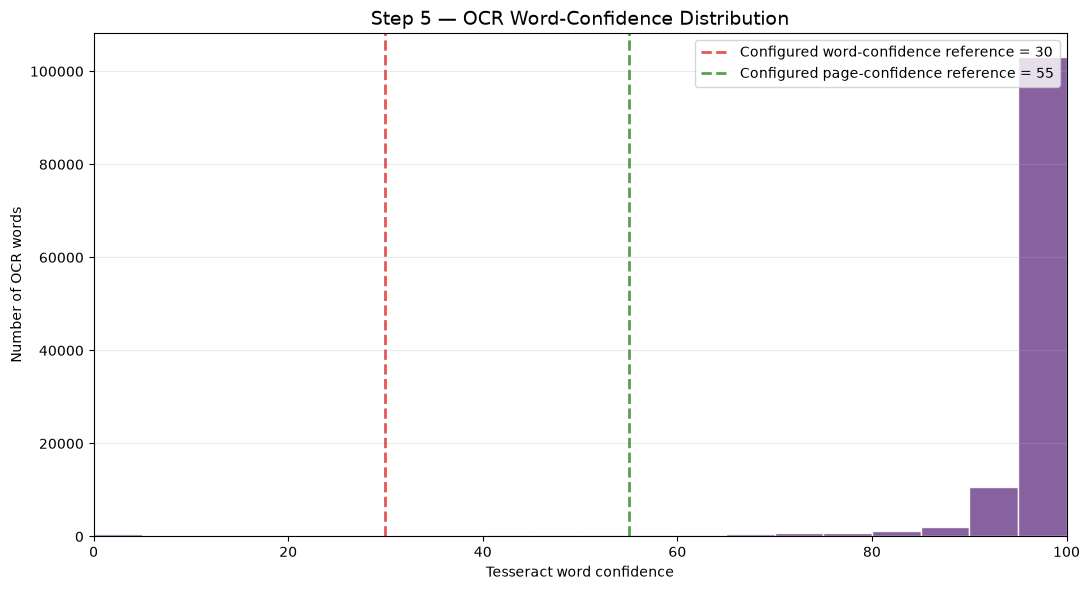

Saved OCR confidence histogram: outputs/figures/step_05_ocr_confidence_distribution.png


In [53]:
if ocr_word_tokens_df.empty:
    print("No OCR words were extracted, so no confidence distribution is available.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.hist(
        ocr_word_tokens_df["ocr_confidence"],
        bins=np.arange(0, 105, 5),
        color="#7A5195",
        edgecolor="white",
        alpha=0.9,
    )

    ax.axvline(
        OCR_CONFIG["minimum_word_confidence"],
        color="#E45756",
        linestyle="--",
        linewidth=2,
        label=(
            "Configured word-confidence reference = "
            f"{OCR_CONFIG['minimum_word_confidence']:.0f}"
        ),
    )

    ax.axvline(
        OCR_CONFIG["minimum_mean_page_confidence"],
        color="#54A24B",
        linestyle="--",
        linewidth=2,
        label=(
            "Configured page-confidence reference = "
            f"{OCR_CONFIG['minimum_mean_page_confidence']:.0f}"
        ),
    )

    ax.set_title("Step 5 — OCR Word-Confidence Distribution", fontsize=14)
    ax.set_xlabel("Tesseract word confidence")
    ax.set_ylabel("Number of OCR words")
    ax.set_xlim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    plt.tight_layout()

    ocr_confidence_histogram_path = (
        FIGURES_DIR / "step_05_ocr_confidence_distribution.png"
    )

    fig.savefig(
        ocr_confidence_histogram_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved OCR confidence histogram: "
        f"{ocr_confidence_histogram_path.relative_to(STAGE_A_ROOT)}"
    )

### OCR word-box inspection

The following overlays show OCR word boxes directly on the rendered page image.

Box color represents OCR word confidence:

- green: high confidence
- yellow: intermediate confidence
- red: low confidence

This visualization helps distinguish:

- true OCR weakness
- correctly recognized text with low reported confidence
- page regions where preprocessing damaged text
- tables or dense schedules that require specialized structural parsing
- coordinate/scale errors in the OCR extraction pipeline

In [54]:
from matplotlib.patches import Rectangle


def ocr_confidence_color(confidence: float) -> str:
    """Map OCR confidence to a diagnostic display color."""
    if confidence >= 80:
        return "#2CA25F"

    if confidence >= 55:
        return "#FEC44F"

    return "#DE2D26"


def plot_ocr_word_boxes(
    rendered_bgr_image: np.ndarray,
    page_ocr_words_df: pd.DataFrame,
    page_number: int,
    max_boxes: int = 160,
    seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Draw sampled OCR word boxes on a rendered page image.
    """
    if page_ocr_words_df.empty:
        raise ValueError(f"No OCR words are available for page {page_number}.")

    display_words = page_ocr_words_df.copy()

    if len(display_words) > max_boxes:
        low_confidence_words = display_words.nsmallest(
            min(40, len(display_words)),
            "ocr_confidence",
        )

        remaining_words = display_words.drop(
            low_confidence_words.index
        )

        random_count = min(
            max_boxes - len(low_confidence_words),
            len(remaining_words),
        )

        sampled_words = remaining_words.sample(
            n=random_count,
            random_state=seed,
        )

        display_words = pd.concat(
            [low_confidence_words, sampled_words],
            ignore_index=True,
        ).drop_duplicates(subset="ocr_token_id")

    rendered_rgb_image = cv2.cvtColor(
        rendered_bgr_image,
        cv2.COLOR_BGR2RGB,
    )

    fig, ax = plt.subplots(figsize=(13, 17))
    ax.imshow(rendered_rgb_image)

    for _, word in display_words.iterrows():
        color = ocr_confidence_color(word["ocr_confidence"])

        rectangle = Rectangle(
            (
                word["bbox_left_px"],
                word["bbox_top_px"],
            ),
            word["bbox_width_px"],
            word["bbox_height_px"],
            linewidth=0.8,
            edgecolor=color,
            facecolor="none",
            alpha=0.85,
        )

        ax.add_patch(rectangle)

    ax.set_title(
        "\n".join(
            [
                "Step 5 — OCR Word Bounding-Box Overlay",
                f"Page {page_number} | "
                f"{len(page_ocr_words_df):,} OCR words | "
                f"{len(display_words):,} displayed boxes",
                "Green: ≥80 confidence | Yellow: 55–79 | Red: <55",
            ]
        ),
        fontsize=12,
    )

    ax.axis("off")

    return fig, ax

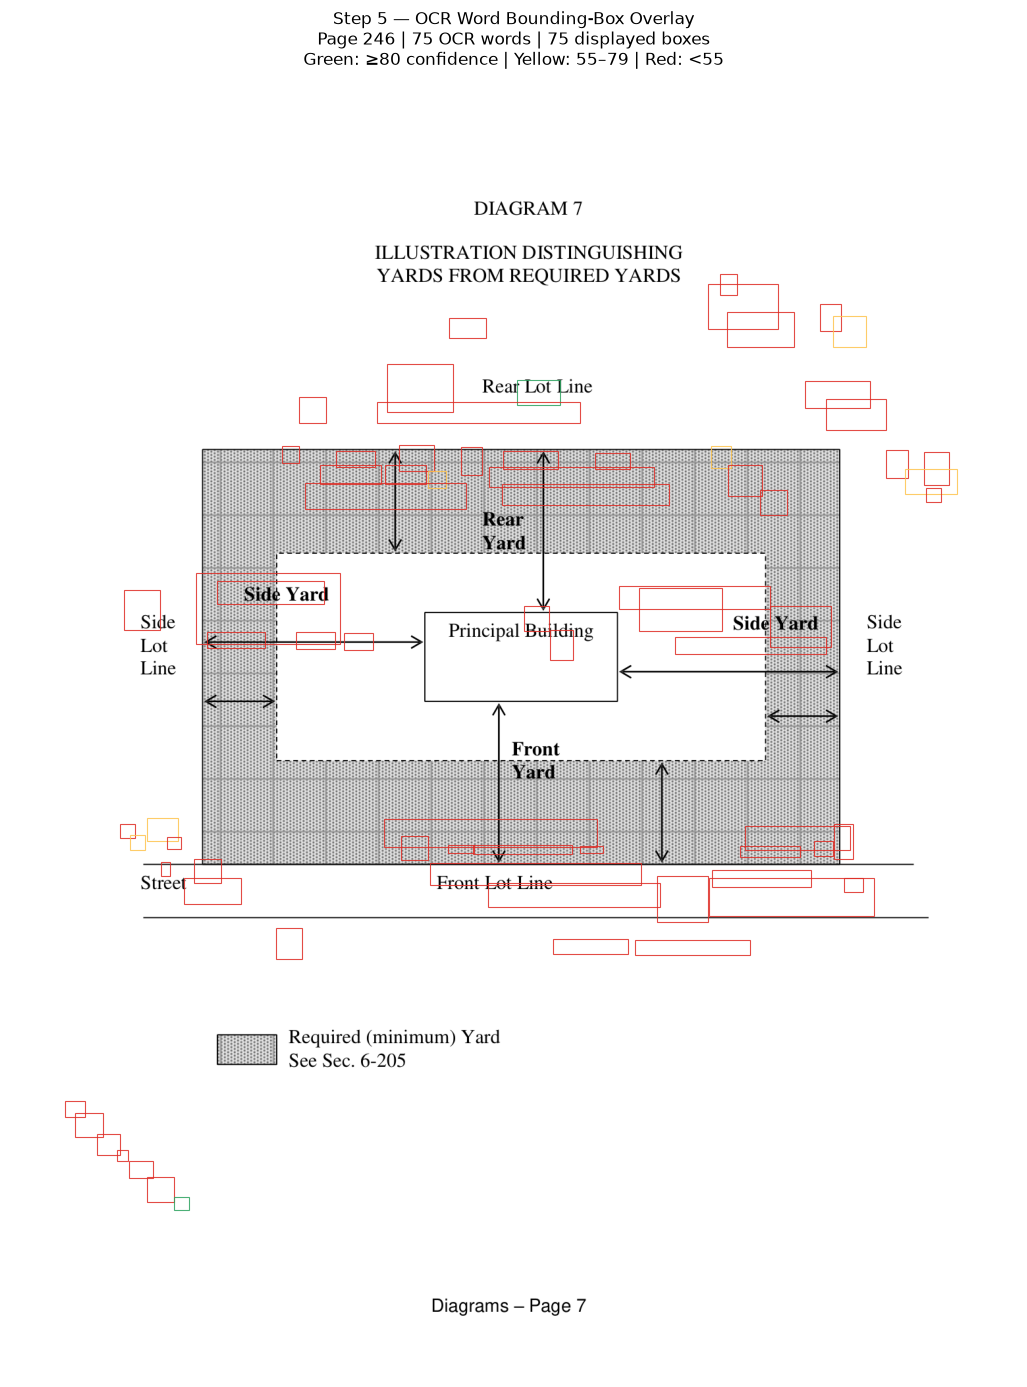

Saved OCR bounding-box overlay: outputs/figures/step_05_ocr_word_bbox_overlay_page_246.png


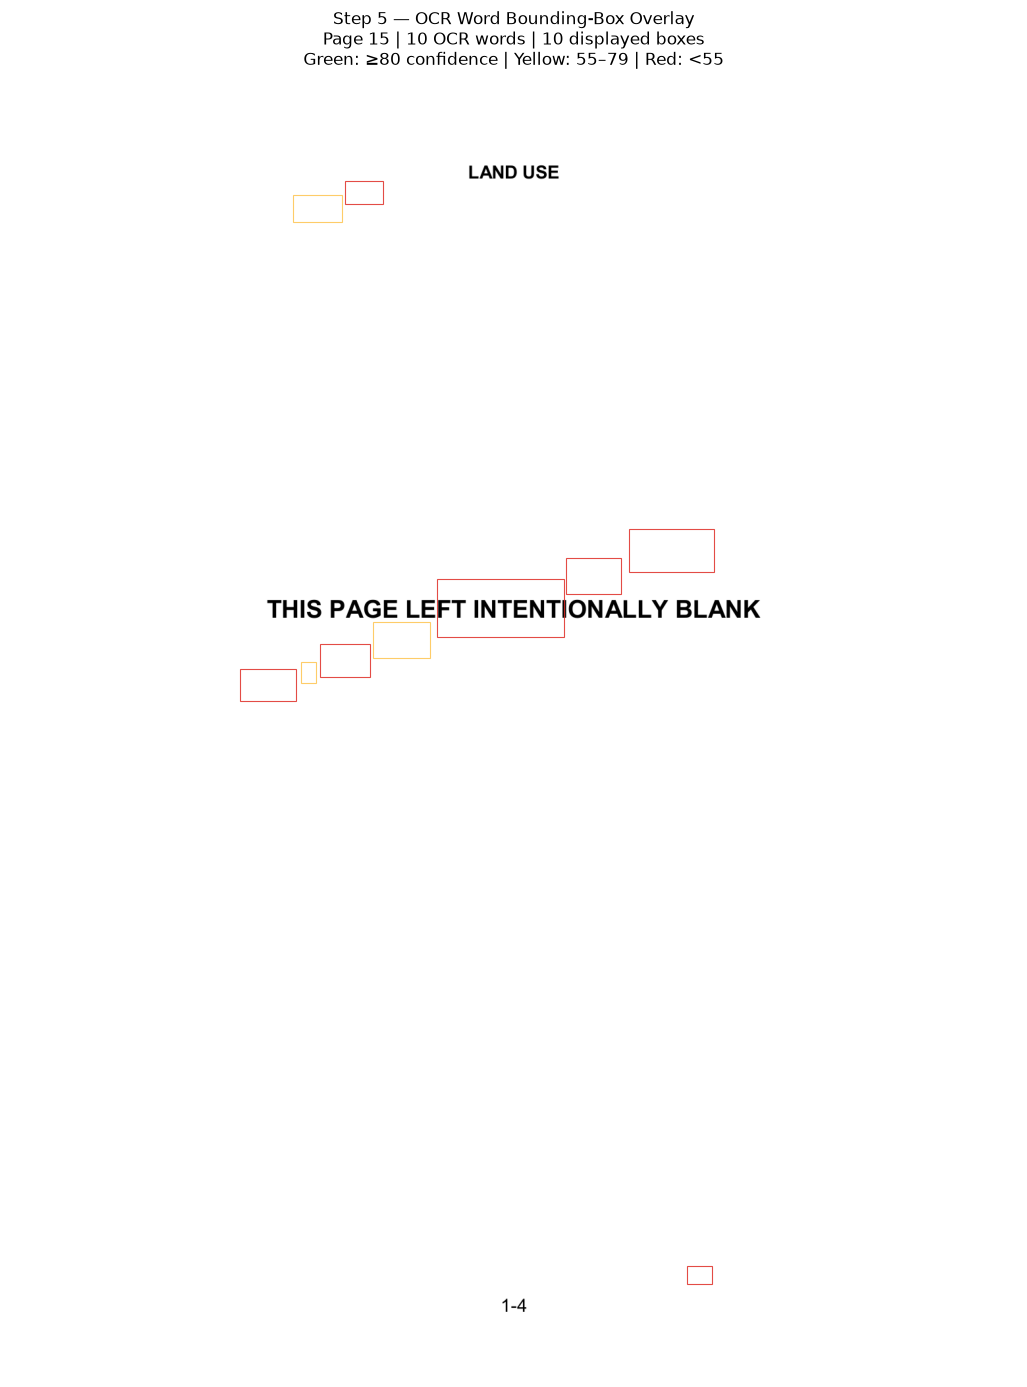

Saved OCR bounding-box overlay: outputs/figures/step_05_ocr_word_bbox_overlay_page_015.png


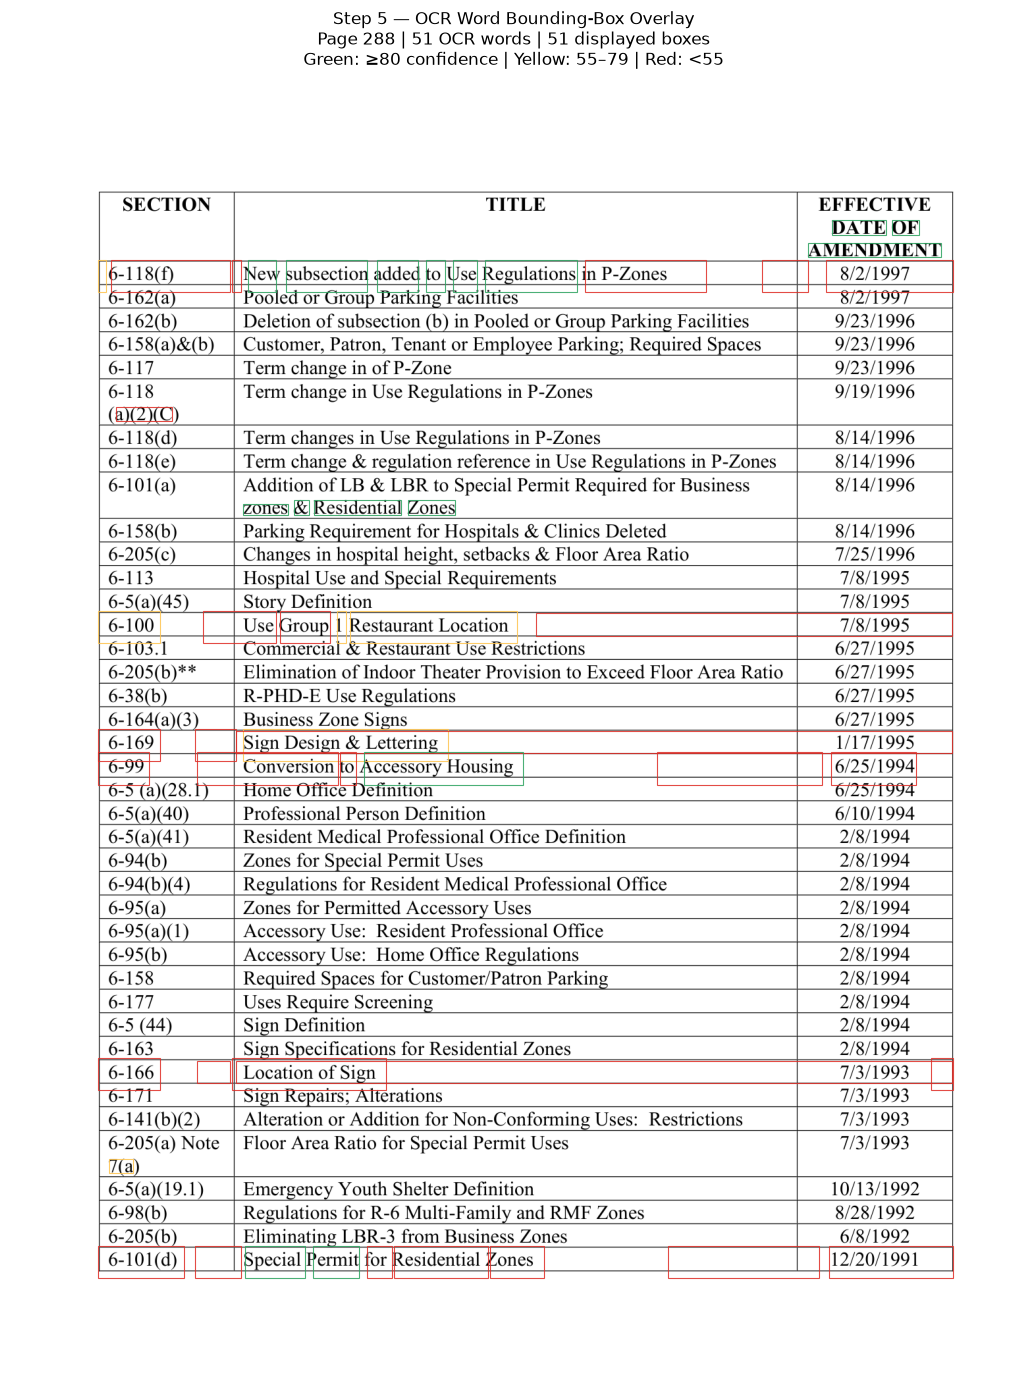

Saved OCR bounding-box overlay: outputs/figures/step_05_ocr_word_bbox_overlay_page_288.png


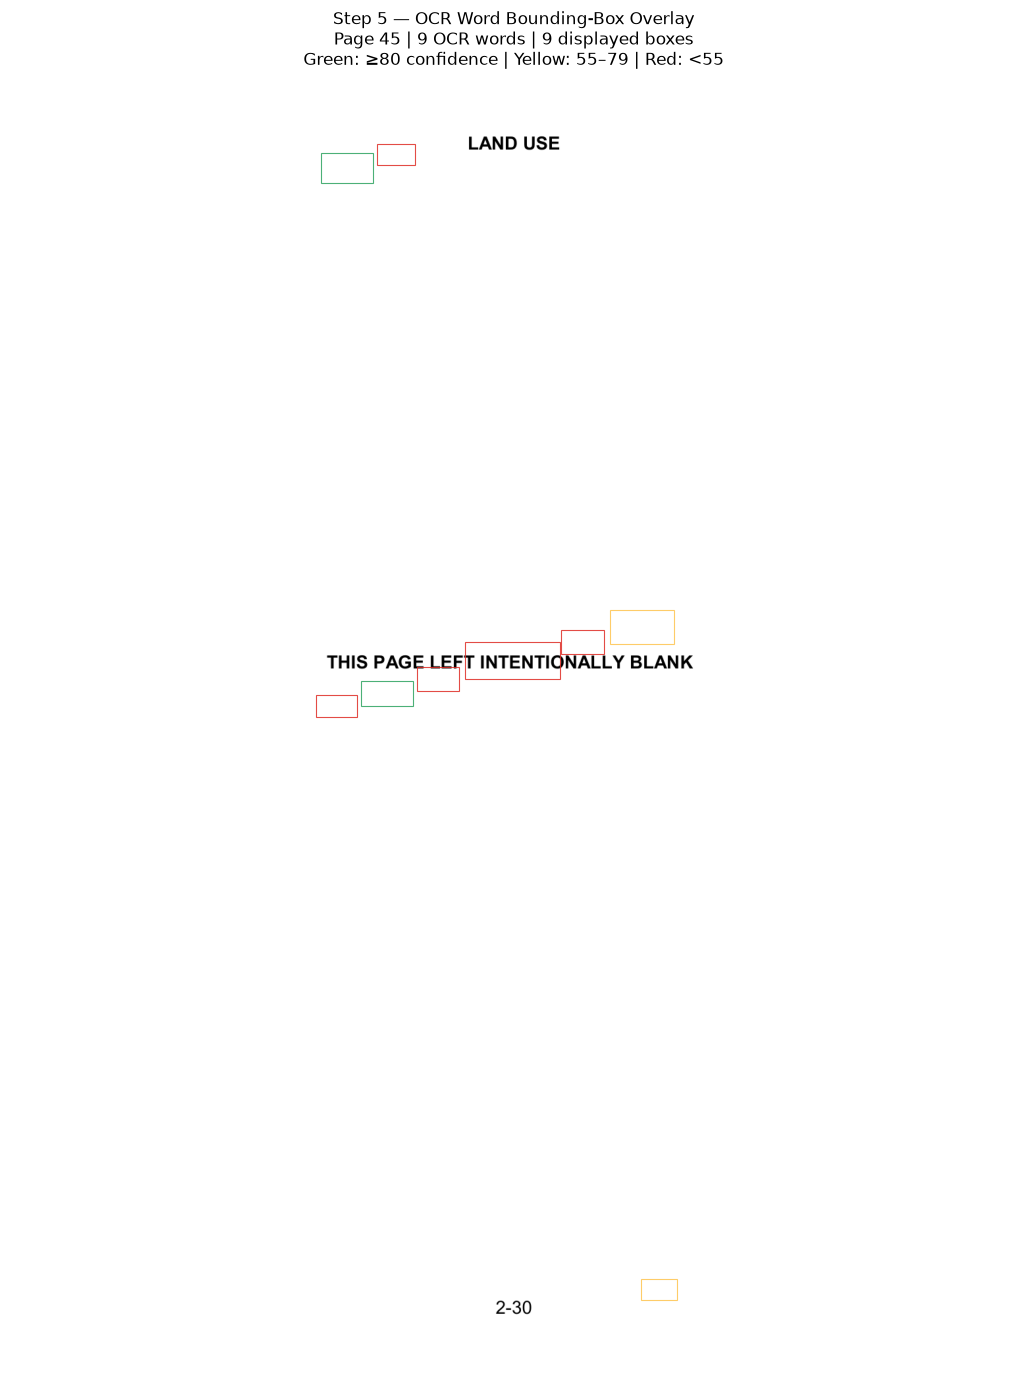

Saved OCR bounding-box overlay: outputs/figures/step_05_ocr_word_bbox_overlay_page_045.png


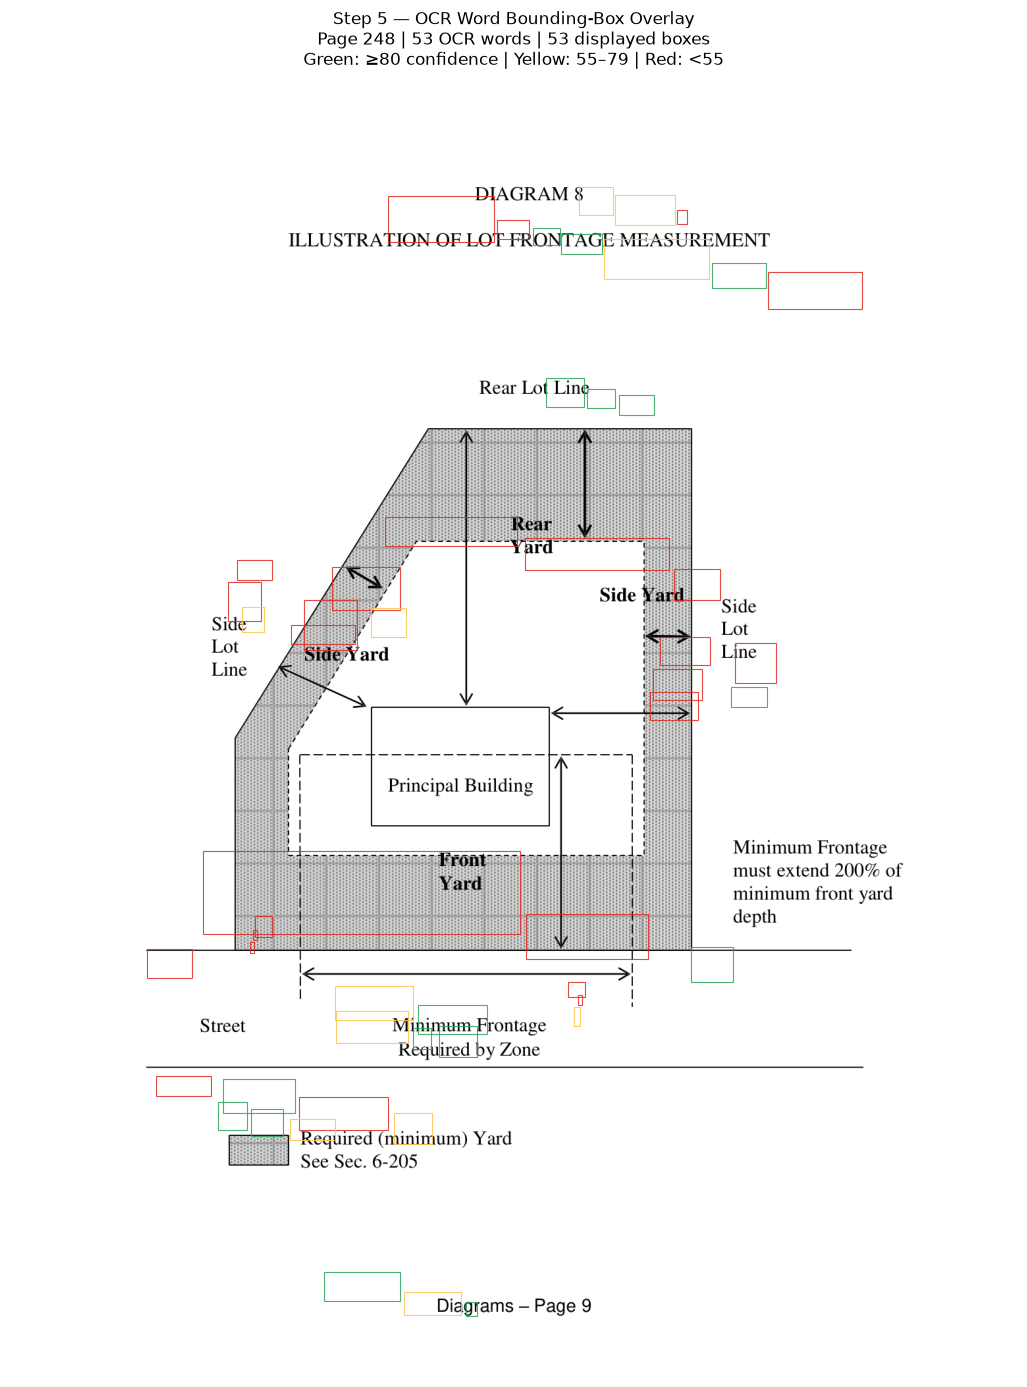

Saved OCR bounding-box overlay: outputs/figures/step_05_ocr_word_bbox_overlay_page_248.png


In [55]:
ocr_overlay_paths = []

if ocr_word_tokens_df.empty:
    print("No OCR word boxes are available for visualization.")
else:
    overlay_candidates_df = (
        reconciliation_df.sort_values(
            [
                "reconciliation_review_status",
                "ocr_mean_word_confidence",
                "native_ocr_similarity",
            ],
            ascending=[True, True, True],
        )
        .head(min(5, len(reconciliation_df)))
    )

    for _, page_row in overlay_candidates_df.iterrows():
        page_number = int(page_row["page_number"])

        page_ocr_words_df = ocr_word_tokens_df.loc[
            ocr_word_tokens_df["page_number"] == page_number
        ].copy()

        if page_ocr_words_df.empty:
            continue

        rendered_bgr_image = render_pdf_page_bgr(
            pdf_path=PDF_PATH,
            page_number=page_number,
            zoom=OCR_CONFIG["render_zoom"],
        )

        fig, ax = plot_ocr_word_boxes(
            rendered_bgr_image=rendered_bgr_image,
            page_ocr_words_df=page_ocr_words_df,
            page_number=page_number,
            max_boxes=180,
            seed=42,
        )

        overlay_path = (
            FIGURES_DIR
            / f"step_05_ocr_word_bbox_overlay_page_{page_number:03d}.png"
        )

        fig.savefig(overlay_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        ocr_overlay_paths.append(overlay_path)

        print(
            "Saved OCR bounding-box overlay: "
            f"{overlay_path.relative_to(STAGE_A_ROOT)}"
        )

### Reconciliation log and uncertainty queue

The reconciliation log preserves:

- native and OCR page text
- OCR confidence and word count
- normalized text similarity
- the selected reconciled stream
- differences between streams;
- preprocessing metadata
- a review status

Pages with low agreement, weak OCR confidence, sparse native text, or an existing manual-review route are written to the review queue. They are not silently accepted into downstream legal extraction.

In [67]:
if reconciliation_df.empty:
    changed_or_uncertain_pages_df = reconciliation_df.copy()
    print("No reconciliation records were created.")
else:
    changed_or_uncertain_pages_df = reconciliation_df.loc[
        (
            reconciliation_df["reconciliation_review_status"]
            != "reconciled_high_agreement"
        )
        | (
            reconciliation_df["native_ocr_similarity"]
            < OCR_CONFIG["high_similarity_threshold"]
        )
    ].copy()

    changed_or_uncertain_pages_df = changed_or_uncertain_pages_df.sort_values(
        [
            "reconciliation_review_status",
            "native_ocr_similarity",
            "page_number",
        ],
        ascending=[True, True, True],
    )

    changed_or_uncertain_pages_df[
        [
            "page_number",
            "step_4_route",
            "step_4_composite_quality_score",
            "ocr_word_count",
            "ocr_mean_word_confidence",
            "native_ocr_similarity",
            "reconciled_source",
            "reconciliation_decision",
            "reconciliation_review_status",
            "uncertainty_reasons",
            "difference_summary",
        ]
    ].style.format(
        {
            "step_4_composite_quality_score": "{:.3f}",
            "ocr_mean_word_confidence": "{:.1f}",
            "native_ocr_similarity": "{:.3f}",
        }
    )

In [68]:
ocr_word_tokens_path = (
    INTERIM_DIR / OCR_CONFIG["output_ocr_tokens_filename"]
)

reconciliation_output_path = (
    TABLES_DIR / OCR_CONFIG["output_reconciliation_filename"]
)

uncertainty_queue_path = (
    REVIEW_DIR / "step_05_changed_or_uncertain_reconciliation_pages.csv"
)

ocr_target_pages_path = TABLES_DIR / "step_05_ocr_target_pages.csv"

ocr_target_pages_df.to_csv(ocr_target_pages_path, index=False)
reconciliation_df.to_csv(reconciliation_output_path, index=False)
changed_or_uncertain_pages_df.to_csv(
    uncertainty_queue_path,
    index=False,
)

if not ocr_word_tokens_df.empty:
    ocr_word_tokens_df.to_parquet(ocr_word_tokens_path, index=False)
else:
    ocr_word_tokens_df.to_csv(
        ocr_word_tokens_path.with_suffix(".csv"),
        index=False,
    )

step_5_log = {
    "document_id": DOCUMENT_ID,
    "ocr_config": OCR_CONFIG,
    "ocr_target_page_count": int(len(ocr_target_pages_df)),
    "ocr_reconciliation_page_count": int(
        len(ocr_reconciliation_pages_df)
    ),
    "manual_review_diagnostic_ocr_page_count": int(
        len(manual_review_pages_df)
    ),
    "ocr_word_token_count": int(len(ocr_word_tokens_df)),
    "reconciliation_record_count": int(len(reconciliation_df)),
    "reconciliation_decision_counts": (
        reconciliation_df["reconciliation_decision"]
        .value_counts(dropna=False)
        .to_dict()
        if not reconciliation_df.empty
        else {}
    ),
    "review_status_counts": (
        reconciliation_df["reconciliation_review_status"]
        .value_counts(dropna=False)
        .to_dict()
        if not reconciliation_df.empty
        else {}
    ),
    "ocr_confidence_summary": (
        {
            "mean": float(
                ocr_word_tokens_df["ocr_confidence"].mean()
            ),
            "median": float(
                ocr_word_tokens_df["ocr_confidence"].median()
            ),
            "minimum": float(
                ocr_word_tokens_df["ocr_confidence"].min()
            ),
            "maximum": float(
                ocr_word_tokens_df["ocr_confidence"].max()
            ),
        }
        if not ocr_word_tokens_df.empty
        else {}
    ),
    "ocr_overlay_paths": [
        str(path.relative_to(STAGE_A_ROOT))
        for path in ocr_overlay_paths
    ],
}

step_5_log_path = LOGS_DIR / "step_05_ocr_reconciliation_log.json"

with step_5_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(step_5_log, file_handle, indent=2, ensure_ascii=False)

print(
    f"Saved OCR target-page table: "
    f"{ocr_target_pages_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved reconciliation table: "
    f"{reconciliation_output_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved uncertainty queue: "
    f"{uncertainty_queue_path.relative_to(STAGE_A_ROOT)}"
)

if not ocr_word_tokens_df.empty:
    print(
        f"Saved OCR word tokens: "
        f"{ocr_word_tokens_path.relative_to(STAGE_A_ROOT)}"
    )
else:
    print(
        "No OCR word tokens were produced; saved an empty CSV fallback if needed."
    )

print(
    f"Saved OCR/reconciliation log: "
    f"{step_5_log_path.relative_to(STAGE_A_ROOT)}"
)

Saved OCR target-page table: outputs/tables/step_05_ocr_target_pages.csv
Saved reconciliation table: outputs/tables/step_05_reconciliation_results.csv
Saved uncertainty queue: outputs/review/step_05_changed_or_uncertain_reconciliation_pages.csv
Saved OCR word tokens: data/interim/step_05_ocr_word_tokens.parquet
Saved OCR/reconciliation log: outputs/logs/step_05_ocr_reconciliation_log.json


## Step 6 — Unified normalized token representation

### Objective

Create one canonical, layout-aware token table for the Greenwich zoning code.

Each token follows the Phase 1 representation:

$$u_i = \langle T_i, P_i, B_i, S_i, H_i, \Gamma_i, \Delta_i \rangle$$

where:

- $T_i$: token text;
- $P_i$: 1-based PDF page number;
- $B_i$: token bounding box;
- $S_i$: section number;
- $H_i$: hierarchy depth;
- $\Gamma_i$: table ID;
- $\Delta_i$: normalized-text character span.

At this point, section number, hierarchy depth, and table ID are intentionally unassigned because hierarchy construction and table parsing occur later.

The normalized-text character spans are created here from the selected page-level text stream, enabling later tokens, hierarchy nodes, references, and evidence excerpts to point into one reproducible document text layer.

### Stream-selection policy

The unified table uses the Step 4 route and Step 5 reconciliation decision.

- Pages routed to `native_extraction` use native PDF tokens
- OCR-target pages use OCR tokens only when Step 5 selected an OCR stream
- Pages where native text was retained use native tokens, while OCR remains available as a separate audit artifact
- Manual-review pages remain explicitly flagged even if provisional token text is included

Bounding-box coordinate systems are preserved:

- Native tokens use PDF-page points.
- OCR tokens use rendered-page pixels.

The pipeline does not silently convert one coordinate system into the other.

In [69]:
required_variables = [
    "DOCUMENT_ID",
    "PDF_PAGE_COUNT",
    "word_tokens_df",
    "page_quality_df",
    "reconciliation_df",
    "ocr_word_tokens_df",
    "INTERIM_DIR",
    "TABLES_DIR",
    "LOGS_DIR",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run Steps 1–5 before Step 6. Missing variables: "
        f"{missing_variables}"
    )

print("All Step 6 input variables are available.")

All Step 6 input variables are available.


In [70]:
native_route = PAGE_QUALITY_SCORING_CONFIG["routing_labels"]["native"]
manual_review_route = PAGE_QUALITY_SCORING_CONFIG["routing_labels"]["manual_review"]

page_stream_selection_df = page_quality_df[
    [
        "page_number",
        "route",
        "quality_review_status",
        "composite_quality_score",
    ]
].copy()

if not reconciliation_df.empty:
    reconciliation_selection_df = reconciliation_df[
        [
            "page_number",
            "reconciled_source",
            "reconciliation_decision",
            "reconciliation_review_status",
        ]
    ].copy()

    page_stream_selection_df = page_stream_selection_df.merge(
        reconciliation_selection_df,
        on="page_number",
        how="left",
    )
else:
    page_stream_selection_df["reconciled_source"] = pd.NA
    page_stream_selection_df["reconciliation_decision"] = pd.NA
    page_stream_selection_df["reconciliation_review_status"] = pd.NA


def select_page_stream(row: pd.Series) -> str:
    if row["route"] == native_route:
        return "native"

    if pd.isna(row["reconciled_source"]):
        return "native"

    if str(row["reconciled_source"]).startswith("ocr_"):
        return "ocr"

    return "native"


page_stream_selection_df["selected_stream"] = page_stream_selection_df.apply(
    select_page_stream,
    axis=1,
)

page_stream_selection_df[
    [
        "page_number",
        "route",
        "selected_stream",
        "reconciled_source",
        "reconciliation_review_status",
    ]
].head(20)

,page_number,route,selected_stream,reconciled_source,reconciliation_review_status
0,1,ocr_and_dual_stream_reconciliation,native,native_retained_intermediate_agreement,reconciliation_review_required
1,2,ocr_and_dual_stream_reconciliation,native,native_confirmed_by_ocr,reconciled_high_agreement
2,3,ocr_and_dual_stream_reconciliation,native,native_confirmed_by_ocr,reconciled_high_agreement
3,4,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required
4,5,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required
5,6,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required
6,7,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required
7,8,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required
8,9,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required
9,10,ocr_and_dual_stream_reconciliation,native,native_provisional_low_agreement,manual_review_required


In [71]:
native_unified_df = word_tokens_df.copy()

native_unified_df = native_unified_df.rename(
    columns={
        "token_id": "source_token_id",
        "bbox_x0": "bbox_left",
        "bbox_y0": "bbox_top",
        "bbox_x1": "bbox_right",
        "bbox_y1": "bbox_bottom",
        "bbox_width": "bbox_width",
        "bbox_height": "bbox_height",
        "token_confidence": "extraction_confidence",
    }
)

native_unified_df["coordinate_system"] = "pdf_points_origin_top_left"
native_unified_df["selected_stream"] = "native"
native_unified_df["extraction_engine"] = "pymupdf_native"
native_unified_df["extraction_method"] = "native_text_stream"

native_unified_df = native_unified_df.merge(
    page_stream_selection_df[
        [
            "page_number",
            "route",
            "quality_review_status",
            "selected_stream",
            "composite_quality_score",
            "reconciliation_decision",
            "reconciliation_review_status",
        ]
    ],
    on=["page_number", "selected_stream"],
    how="inner",
)

native_unified_df["review_status"] = np.where(
    native_unified_df["route"] == manual_review_route,
    "manual_review_required",
    np.where(
        native_unified_df["reconciliation_review_status"].notna(),
        native_unified_df["reconciliation_review_status"],
        native_unified_df["quality_review_status"],
    ),
)

native_unified_df["section_number"] = pd.NA
native_unified_df["heading_depth"] = pd.NA
native_unified_df["table_id"] = pd.NA


if ocr_word_tokens_df.empty:
    ocr_unified_df = pd.DataFrame()
else:
    ocr_unified_df = ocr_word_tokens_df.copy()

    ocr_unified_df = ocr_unified_df.rename(
        columns={
            "ocr_token_id": "source_token_id",
            "bbox_left_px": "bbox_left",
            "bbox_top_px": "bbox_top",
            "bbox_right_px": "bbox_right",
            "bbox_bottom_px": "bbox_bottom",
            "bbox_width_px": "bbox_width",
            "bbox_height_px": "bbox_height",
            "ocr_confidence": "extraction_confidence",
        }
    )

    ocr_unified_df["selected_stream"] = "ocr"

    ocr_unified_df = ocr_unified_df.merge(
        page_stream_selection_df[
            [
                "page_number",
                "route",
                "selected_stream",
                "composite_quality_score",
                "reconciliation_decision",
                "reconciliation_review_status",
            ]
        ],
        on=["page_number", "selected_stream"],
        how="inner",
    )

    ocr_unified_df["section_number"] = pd.NA
    ocr_unified_df["heading_depth"] = pd.NA
    ocr_unified_df["table_id"] = pd.NA

    ocr_unified_df["review_status"] = np.where(
        ocr_unified_df["route"] == manual_review_route,
        "manual_review_required",
        ocr_unified_df["reconciliation_review_status"],
    )

In [72]:
unified_columns = [
    "document_id",
    "source_token_id",
    "text",
    "page_number",
    "bbox_left",
    "bbox_top",
    "bbox_right",
    "bbox_bottom",
    "bbox_width",
    "bbox_height",
    "coordinate_system",
    "section_number",
    "heading_depth",
    "table_id",
    "extraction_engine",
    "extraction_method",
    "extraction_confidence",
    "route",
    "selected_stream",
    "composite_quality_score",
    "reconciliation_decision",
    "reconciliation_review_status",
    "review_status",
]

token_frames = [native_unified_df[unified_columns]]

if not ocr_unified_df.empty:
    token_frames.append(ocr_unified_df[unified_columns])

unified_tokens_df = pd.concat(
    token_frames,
    ignore_index=True,
)

unified_tokens_df = unified_tokens_df.sort_values(
    [
        "page_number",
        "bbox_top",
        "bbox_left",
    ]
).reset_index(drop=True)

unified_tokens_df["unified_token_id"] = [
    f"{DOCUMENT_ID}-u{index + 1:08d}"
    for index in range(len(unified_tokens_df))
]

normalized_text_parts = []
normalized_text_start_positions = []
normalized_text_end_positions = []

current_position = 0

for token_text in unified_tokens_df["text"].fillna("").astype(str):
    clean_text = re.sub(r"\s+", " ", token_text).strip()

    normalized_text_start_positions.append(current_position)
    normalized_text_parts.append(clean_text)

    current_position += len(clean_text)

    normalized_text_end_positions.append(current_position)

    current_position += 1

unified_tokens_df["normalized_text_start"] = normalized_text_start_positions
unified_tokens_df["normalized_text_end"] = normalized_text_end_positions

NORMALIZED_DOCUMENT_TEXT = " ".join(normalized_text_parts).strip()

assert unified_tokens_df["page_number"].between(
    1,
    PDF_PAGE_COUNT,
).all(), "Every unified token must have a valid page number."

assert unified_tokens_df["unified_token_id"].is_unique, (
    "Unified token IDs must be unique."
)

assert len(NORMALIZED_DOCUMENT_TEXT) > 0, (
    "Normalized document text must not be empty."
)

print(f"Unified tokens created: {len(unified_tokens_df):,}")
print(f"Normalized document characters: {len(NORMALIZED_DOCUMENT_TEXT):,}")

Unified tokens created: 125,290
Normalized document characters: 810,972


### Unified-token schema validation

The table below verifies the canonical token schema before later structural parsing.

Expected nulls at this stage:

- `section_number`
- `heading_depth`
- `table_id`
- native-token `extraction_confidence`

These fields are not errors yet. They become populated in later collection stages.

Unexpected nulls include:

- token text
- page number
- source token ID
- coordinate-system label
- extraction engine
- route
- review status

In [73]:
schema_check_df = pd.DataFrame(
    {
        "field": unified_tokens_df.columns,
        "data_type": [
            str(unified_tokens_df[column].dtype)
            for column in unified_tokens_df.columns
        ],
        "null_count": [
            int(unified_tokens_df[column].isna().sum())
            for column in unified_tokens_df.columns
        ],
        "null_rate": [
            unified_tokens_df[column].isna().mean()
            for column in unified_tokens_df.columns
        ],
        "unique_values": [
            int(unified_tokens_df[column].nunique(dropna=True))
            for column in unified_tokens_df.columns
        ],
    }
)

schema_check_df.style.format({"null_rate": "{:.2%}"})

,field,data_type,null_count,null_rate,unique_values
0,document_id,str,0,0.00%,1
1,source_token_id,str,0,0.00%,125290
2,text,str,0,0.00%,14084
3,page_number,int64,0,0.00%,313
4,bbox_left,float64,0,0.00%,102217
5,bbox_top,float64,0,0.00%,5537
6,bbox_right,float64,0,0.00%,113173
7,bbox_bottom,float64,0,0.00%,5477
8,bbox_width,float64,0,0.00%,35240
9,bbox_height,float64,0,0.00%,776


In [74]:
required_non_null_fields = [
    "document_id",
    "source_token_id",
    "unified_token_id",
    "text",
    "page_number",
    "coordinate_system",
    "extraction_engine",
    "extraction_method",
    "route",
    "selected_stream",
    "review_status",
]

required_field_validation_df = pd.DataFrame(
    {
        "field": required_non_null_fields,
        "null_count": [
            int(unified_tokens_df[field].isna().sum())
            for field in required_non_null_fields
        ],
    }
)

required_field_validation_df["passed"] = (
    required_field_validation_df["null_count"] == 0
)

if not required_field_validation_df["passed"].all():
    failing_fields = required_field_validation_df.loc[
        ~required_field_validation_df["passed"],
        "field",
    ].tolist()

    raise ValueError(
        "Required unified-token fields contain null values: "
        f"{failing_fields}"
    )

required_field_validation_df

,field,null_count,passed
0,document_id,0,True
1,source_token_id,0,True
2,unified_token_id,0,True
3,text,0,True
4,page_number,0,True
5,coordinate_system,0,True
6,extraction_engine,0,True
7,extraction_method,0,True
8,route,0,True
9,selected_stream,0,True


In [75]:
sample_token_columns = [
    "unified_token_id",
    "text",
    "page_number",
    "bbox_left",
    "bbox_top",
    "bbox_right",
    "bbox_bottom",
    "coordinate_system",
    "section_number",
    "heading_depth",
    "table_id",
    "extraction_engine",
    "extraction_confidence",
    "route",
    "selected_stream",
    "review_status",
    "normalized_text_start",
    "normalized_text_end",
]

unified_tokens_df[sample_token_columns].head(40)

,unified_token_id,text,page_number,bbox_left,bbox_top,bbox_right,bbox_bottom,coordinate_system,section_number,heading_depth,table_id,extraction_engine,extraction_confidence,route,selected_stream,review_status,normalized_text_start,normalized_text_end
0,greenwich-connecticut-18417c5e9074d765-u00000001,TOWN,1,85.800003,224.599442,207.829834,276.267731,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,0,4
1,greenwich-connecticut-18417c5e9074d765-u00000002,OF,1,217.819824,224.599442,271.514069,276.267731,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,5,7
2,greenwich-connecticut-18417c5e9074d765-u00000003,GREENWICH,1,281.528076,224.599442,526.227173,276.267731,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,8,17
3,greenwich-connecticut-18417c5e9074d765-u00000004,BUILDING,1,137.759995,291.427429,245.891022,319.821716,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,18,26
4,greenwich-connecticut-18417c5e9074d765-u00000005,ZONE,1,251.391998,291.427429,314.274445,319.821716,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,27,31
5,greenwich-connecticut-18417c5e9074d765-u00000006,REGULATIONS,1,319.915985,291.427429,473.949982,319.821716,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,32,43
6,greenwich-connecticut-18417c5e9074d765-u00000007,August,1,247.320007,647.496033,313.608032,678.528015,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,44,50
7,greenwich-connecticut-18417c5e9074d765-u00000008,2023,1,319.559998,647.496033,364.656006,678.528015,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,51,55
8,greenwich-connecticut-18417c5e9074d765-u00000009,Adopted,1,438.119141,707.534668,472.019012,720.412964,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,56,63
9,greenwich-connecticut-18417c5e9074d765-u00000010,February,1,474.598663,707.534668,509.351074,720.412964,pdf_points_origin_top_left,<NA>,<NA>,<NA>,pymupdf_native,None,ocr_and_dual_stream_reconciliation,native,reconciliation_review_required,64,72


### Token-distribution checks

The summaries below confirm that:

- tokens exist across the document’s pages
- routing decisions are reflected in the selected extraction engine
- OCR tokens appear only on pages where OCR was selected
- table membership remains unassigned until structural table parsing

In [76]:
token_counts_by_page_df = (
    unified_tokens_df.groupby(
        ["page_number", "extraction_engine"],
        as_index=False,
    )
    .agg(
        token_count=("unified_token_id", "size"),
        mean_confidence=("extraction_confidence", "mean"),
    )
    .sort_values(["page_number", "extraction_engine"])
)

token_counts_by_page_df.head(30)

,page_number,extraction_engine,token_count,mean_confidence
0,1,pymupdf_native,17,NaN
1,2,pymupdf_native,117,NaN
2,3,pymupdf_native,3,NaN
3,4,pymupdf_native,279,NaN
4,5,pymupdf_native,320,NaN
5,6,pymupdf_native,320,NaN
6,7,pymupdf_native,322,NaN
7,8,pymupdf_native,265,NaN
8,9,pymupdf_native,276,NaN
9,10,pymupdf_native,300,NaN


In [77]:
token_counts_by_engine_df = (
    unified_tokens_df.groupby(
        "extraction_engine",
        as_index=False,
    )
    .agg(
        token_count=("unified_token_id", "size"),
        mean_confidence=("extraction_confidence", "mean"),
        page_count=("page_number", "nunique"),
    )
    .sort_values("extraction_engine")
)

token_counts_by_engine_df

,extraction_engine,token_count,mean_confidence,page_count
0,pymupdf_native,125228,NaN,307
1,tesseract,62,70.143203,6


In [78]:
unified_tokens_df["table_membership_status"] = np.where(
    unified_tokens_df["table_id"].isna(),
    "non_table_or_not_yet_classified",
    "table_member",
)

token_counts_by_table_status_df = (
    unified_tokens_df.groupby(
        "table_membership_status",
        as_index=False,
    )
    .agg(
        token_count=("unified_token_id", "size"),
        page_count=("page_number", "nunique"),
    )
)

token_counts_by_table_status_df

,table_membership_status,token_count,page_count
0,non_table_or_not_yet_classified,125290,313


In [79]:
unified_tokens_path = (
    INTERIM_DIR / "step_06_unified_normalized_tokens.parquet"
)

normalized_text_path = (
    INTERIM_DIR / "step_06_normalized_document_text.txt"
)

schema_check_path = (
    TABLES_DIR / "step_06_unified_token_schema_check.csv"
)

page_token_counts_path = (
    TABLES_DIR / "step_06_token_counts_by_page.csv"
)

engine_token_counts_path = (
    TABLES_DIR / "step_06_token_counts_by_engine.csv"
)

table_status_counts_path = (
    TABLES_DIR / "step_06_token_counts_by_table_status.csv"
)

unified_tokens_df.to_parquet(unified_tokens_path, index=False)

with normalized_text_path.open("w", encoding="utf-8") as file_handle:
    file_handle.write(NORMALIZED_DOCUMENT_TEXT)

schema_check_df.to_csv(schema_check_path, index=False)
token_counts_by_page_df.to_csv(page_token_counts_path, index=False)
token_counts_by_engine_df.to_csv(engine_token_counts_path, index=False)
token_counts_by_table_status_df.to_csv(
    table_status_counts_path,
    index=False,
)

step_6_log = {
    "document_id": DOCUMENT_ID,
    "unified_token_count": int(len(unified_tokens_df)),
    "normalized_document_character_count": int(
        len(NORMALIZED_DOCUMENT_TEXT)
    ),
    "selected_stream_counts": (
        unified_tokens_df["selected_stream"]
        .value_counts()
        .to_dict()
    ),
    "extraction_engine_counts": (
        unified_tokens_df["extraction_engine"]
        .value_counts()
        .to_dict()
    ),
    "review_status_counts": (
        unified_tokens_df["review_status"]
        .value_counts()
        .to_dict()
    ),
    "unified_tokens_path": str(
        unified_tokens_path.relative_to(STAGE_A_ROOT)
    ),
    "normalized_text_path": str(
        normalized_text_path.relative_to(STAGE_A_ROOT)
    ),
}

step_6_log_path = LOGS_DIR / "step_06_unified_token_log.json"

with step_6_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(step_6_log, file_handle, indent=2, ensure_ascii=False)

print(
    f"Saved unified token table: "
    f"{unified_tokens_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved normalized document text: "
    f"{normalized_text_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved schema check: "
    f"{schema_check_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved Step 6 log: "
    f"{step_6_log_path.relative_to(STAGE_A_ROOT)}"
)

Saved unified token table: data/interim/step_06_unified_normalized_tokens.parquet
Saved normalized document text: data/interim/step_06_normalized_document_text.txt
Saved schema check: outputs/tables/step_06_unified_token_schema_check.csv
Saved Step 6 log: outputs/logs/step_06_unified_token_log.json
